<img src = "https://drive.google.com/uc?export=view&id=1rSrsZ04aJ_D3BC67Cy2dBUZ6tmguydNf" alt = "Encabezado MLDS" width = "100%">  </img>

1. ---**Alejandra Jaramillo Mejia**---
2. ---**Brayan Sebastian Yepes Garcia**---
3. ---**Santiago Chaparro Suzunaga**---

# ICARE

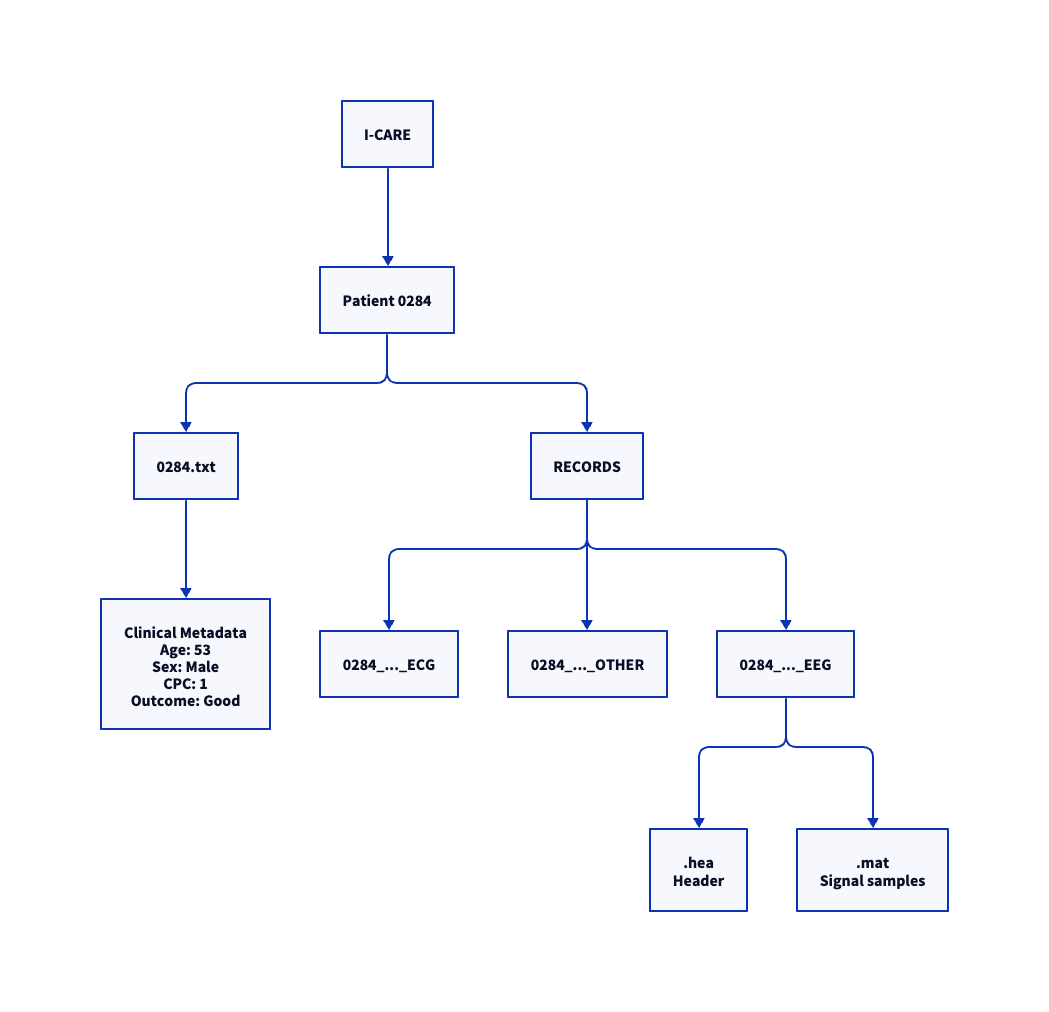

# Records

In [1]:
# Para verificar si estoy usando el venv que cree

import sys
print(sys.executable)

/Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/.venv/bin/python


# Preparación de los datos fisiológicos — Records

En esta sección se desarrolla la preparación de los registros fisiológicos del conjunto de 
datos I-CARE. El análisis se concentra exclusivamente en la estructura `Records`, utilizada 
para identificar y organizar los archivos de señales fisiológicas disponibles para cada 
paciente.

El proceso de preparación se organiza en tres etapas principales:

1. **Exploración y evaluación de calidad de los registros:** construcción del inventario global 
   de registros fisiológicos y evaluación de valores faltantes, duplicados, inconsistencias, 
   valores atípicos y accesibilidad de los archivos.

2. **Selección de los registros EEG:** identificación de la modalidad EEG, aplicación de 
   criterios temporales, inspección de los metadatos contenidos en los archivos `.hea` y 
   selección de registros elegibles de acuerdo con su duración y disponibilidad de canales.

3. **Preprocesamiento y transformación:** definición de ventanas de 90 segundos, selección y 
   reorganización de 19 canales EEG comunes, conversión de valores digitales a unidades 
   físicas, estandarización de la frecuencia de muestreo a 200 Hz y aplicación de filtros 
   para acondicionar las señales.

El procedimiento se realiza de forma progresiva para reducir el número de archivos que deben 
ser inspeccionados o descargados. Finalmente, el pipeline de transformación se valida sobre 
un registro EEG individual antes de considerar su aplicación al conjunto completo de señales.


### 1. Configuración y adquisición de los datos
En esta fase se realiza la preparación de los datos del proyecto I-CARE siguiendo la metodología CRISP-DM. El proceso comprende la limpieza de los datos, la selección de los registros y características relevantes, y las transformaciones necesarias para obtener un conjunto de datos adecuado para las etapas posteriores del proyecto.

En primer lugar, se consulta el archivo `RECORDS` del conjunto de datos para identificar los pacientes disponibles y posteriormente obtener su información clínica.

## Roadmap de la preparación de Records

Esta sección continúa el trabajo realizado durante la **Entrega 02 — Entendimiento de los datos** 
y desarrolla la **Entrega 03 — Preparación de los datos**.

El flujo seguido en el notebook parte de la construcción del inventario de registros 
fisiológicos y avanza progresivamente hacia la selección y definición del preprocesamiento de 
las señales EEG.

```mermaid
flowchart TD

    A["I-CARE Dataset"] --> B["Archivos RECORDS por paciente"]

    B --> C["Construcción del inventario fisiológico"]
    C --> D["records_df"]

    D --> E["Exploración inicial<br/>dimensiones, tipos, faltantes,<br/>duplicados y valores únicos"]

    E --> F["Fin Entrega 02<br/>Entendimiento de los datos"]

    F --> G["Inicio Entrega 03<br/>Preparación de los datos"]

    G --> H["Etapa 1<br/>Exploración y calidad"]
    H --> I["Valores faltantes"]
    I --> J["Duplicados"]
    J --> K["Inconsistencias"]
    K --> L["Valores atípicos"]

    L --> M["Etapa 2<br/>Selección de registros EEG"]
    M --> N["36,123 registros EEG"]
    N --> O["Selección temporal<br/>24, 26, 28, 30 y 32 h"]
    O --> P["2,611 registros candidatos"]

    P --> Q["Inspección de archivos .hea"]
    Q --> R["Duración + frecuencia de muestreo<br/>+ canales + accesibilidad"]
    R --> S["2,590 registros elegibles"]

    S --> T["Selección por paciente-hora"]
    T --> U["2,421 registros seleccionados"]

    U --> V["Etapa 3<br/>Preprocesamiento"]
    V --> W["Ventana central de 90 s"]
    W --> X["19 canales EEG comunes"]
    X --> Y["Calibración digital → física"]
    Y --> Z["Remuestreo a 200 Hz"]
    Z --> AA["Band-pass 0.5–70 Hz"]
    AA --> AB["Notch 50 Hz"]

    AB --> AC["Representación final<br/>19 × 18,000"]
    AC --> AD["Validación sobre<br/>un registro EEG"]

    AD --> AE["Pipeline definido y validado<br/>sin procesamiento masivo"]
```

> **Alcance de la Entrega 03.** La preparación masiva de los 2,421 archivos `.mat` no se 
> ejecuta en esta entrega. El objetivo es establecer los criterios de selección y definir y 
> validar el pipeline de preprocesamiento sobre un registro EEG real.

## **Adquisición e Integración de los Datos, exploración y calidad: Records**
---



In [2]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd()

# If the notebook is running inside notebooks/<folder>,
# move up until reaching the project root.
while not (PROJECT_ROOT / "README.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Data directories
RAW_DATA = PROJECT_ROOT / "data" / "raw"
EEG_DATA = RAW_DATA / "eeg"
CLINICAL_DATA = RAW_DATA / "clinical"
INTERIM_DATA = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

# Results
RESULTS = PROJECT_ROOT / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"

# Create directories if needed
folders = [
    RAW_DATA,
    EEG_DATA,
    CLINICAL_DATA,
    INTERIM_DATA,
    PROCESSED_DATA,
    FIGURES,
    TABLES,
]

for folder in folders:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA)
print("EEG data:", EEG_DATA)
print("Clinical data:", CLINICAL_DATA)
print("Processed data:", PROCESSED_DATA)

Project root: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_
Raw data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw
EEG data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg
Clinical data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/clinical
Processed data: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/processed


In [3]:
import sys
import os
from pathlib import Path

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
!pip install -q wfdb
import wfdb

### Configuración del entorno de trabajo

Se define la estructura de directorios utilizada durante el análisis para
mantener separados los datos originales, datos intermedios, datos procesados
y resultados generados.

Los datos fisiológicos originales se almacenan en `data/raw`, mientras que
los productos derivados del análisis se organizan en `data/interim`,
`data/processed` y `results`.

In [5]:
from pathlib import Path
import requests
BASE_URL = "https://physionet.org/files/i-care/2.1"
RECORDS_URL = f"{BASE_URL}/RECORDS"


METADATA_DIR = RAW_DATA / "clinical"
METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Metadata directory:", METADATA_DIR)


Metadata directory: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/clinical


In [6]:
#response = requests.get(RECORDS_URL, verify=False, timeout=30)
response = requests.get(RECORDS_URL, timeout=30)
response.raise_for_status()

records = response.text.splitlines() # split the text into a list of records

print(records)

NUMBER_OF_RECORDS = len(records)
print(f"Number of records: {NUMBER_OF_RECORDS}")

patient_ids = [
    record.strip("/").split("/")[-1]
    for record in records
]
print(patient_ids[:10])

#patient_data

['training/0284/', 'training/0286/', 'training/0296/', 'training/0299/', 'training/0303/', 'training/0306/', 'training/0311/', 'training/0312/', 'training/0313/', 'training/0316/', 'training/0319/', 'training/0320/', 'training/0326/', 'training/0328/', 'training/0332/', 'training/0334/', 'training/0335/', 'training/0337/', 'training/0340/', 'training/0341/', 'training/0342/', 'training/0344/', 'training/0346/', 'training/0347/', 'training/0348/', 'training/0349/', 'training/0350/', 'training/0351/', 'training/0352/', 'training/0353/', 'training/0354/', 'training/0355/', 'training/0356/', 'training/0357/', 'training/0358/', 'training/0359/', 'training/0360/', 'training/0361/', 'training/0362/', 'training/0363/', 'training/0364/', 'training/0365/', 'training/0366/', 'training/0367/', 'training/0368/', 'training/0369/', 'training/0370/', 'training/0371/', 'training/0372/', 'training/0373/', 'training/0375/', 'training/0376/', 'training/0377/', 'training/0378/', 'training/0379/', 'training


### Prueba de unicidad


In [7]:

#patient_ids[0]
print("Number of patients:", len(patient_ids))
#This explores the number of unique patients in the dataset
print('Unique patients:', len(set(patient_ids)))
assert len(patient_ids) == len(set(patient_ids))
print('First patient ID:', patient_ids[0])
print('Last patient ID:', patient_ids[-1])

Number of patients: 607
Unique patients: 607
First patient ID: 0284
Last patient ID: 1020


In [8]:
sites = [
    {
        "site_id": 1,
        "hospital": "Rijnstate Hospital",
        "city": "Arnhem",
        "region": None,
        "country": "Netherlands",
        "investigators": ["Jeannette Hofmeijer"],
    },
    {
        "site_id": 2,
        "hospital": "Medisch Spectrum Twente",
        "city": "Enschede",
        "region": None,
        "country": "Netherlands",
        "investigators": [
            "Barry J. Ruijter",
            "Marleen C. Tjepkema-Cloostermans",
            "Michel J. A. M. van Putten",
        ],
    },
    {
        "site_id": 3,
        "hospital": "Erasme Hospital",
        "city": "Brussels",
        "region": None,
        "country": "Belgium",
        "investigators": ["Nicolas Gaspard"],
    },
    {
        "site_id": 4,
        "hospital": "Massachusetts General Hospital",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": [
            "Edilberto Amorim",
            "Wei-Long Zheng",
            "Mohammad Ghassemi",
            "M. Brandon Westover",
        ],
    },
    {
        "site_id": 5,
        "hospital": "Brigham and Women's Hospital",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": ["Jong Woo Lee"],
    },
    {
        "site_id": 6,
        "hospital": "Beth Israel Deaconess Medical Center",
        "city": "Boston",
        "region": "Massachusetts",
        "country": "USA",
        "investigators": ["Susan T. Herman"],
    },
    {
        "site_id": 7,
        "hospital": "Yale New Haven Hospital",
        "city": "New Haven",
        "region": "Connecticut",
        "country": "USA",
        "investigators": ["Adithya Sivaraju"],
    },
]

sites_df = pd.DataFrame(sites)

sites_df


,site_id,hospital,city,region,country,investigators
0,1,Rijnstate Hospital,Arnhem,NaN,Netherlands,[Jeannette Hofmeijer]
1,2,Medisch Spectrum Twente,Enschede,NaN,Netherlands,"[Barry J. Ruijter, Marleen C. Tjepkema-Clooste..."
2,3,Erasme Hospital,Brussels,NaN,Belgium,[Nicolas Gaspard]
3,4,Massachusetts General Hospital,Boston,Massachusetts,USA,"[Edilberto Amorim, Wei-Long Zheng, Mohammad Gh..."
4,5,Brigham and Women's Hospital,Boston,Massachusetts,USA,[Jong Woo Lee]
5,6,Beth Israel Deaconess Medical Center,Boston,Massachusetts,USA,[Susan T. Herman]
6,7,Yale New Haven Hospital,New Haven,Connecticut,USA,[Adithya Sivaraju]


In [9]:
patient_id = patient_ids[0]
print(patient_id)
url = f"{BASE_URL}/training/{patient_id}/{patient_id}.txt"
#request.get() is a method provided by the requests library in Python that allows you to send an HTTP GET request to a specified URL. It retrieves data from the server and returns a response object containing the server's response, including the requested data, status code, headers, and other information.
response = requests.get(url,verify=False,timeout=30) # send a GET request to the specified URL and store the response in the variable 'response'
response.raise_for_status() # check if the request was successful
print(response.text) # print the content of the response
lines = response.text.strip().splitlines() # strip means to remove any leading or trailing whitespace characters from the string, and splitlines() splits the string into a list of lines based on the newline character.
print('lines'+str(lines))

patient_data = {}

for line in lines:
    key, value = line.split(":", 1)
    patient_data[key.strip()] = value.strip()


patient_data

print(patient_data["ROSC"])
print(type(patient_data["ROSC"]))

print(patient_data["ROSC"] == "nan")



0284
Patient: 0284
Hospital: A
Age: 53
Sex: Male
ROSC: nan
OHCA: True
Shockable Rhythm: True
TTM: 33
Outcome: Good
CPC: 1

lines['Patient: 0284', 'Hospital: A', 'Age: 53', 'Sex: Male', 'ROSC: nan', 'OHCA: True', 'Shockable Rhythm: True', 'TTM: 33', 'Outcome: Good', 'CPC: 1']
nan
<class 'str'>
True


/Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'physionet.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Estructura de los datos fisiológicos de I-CARE

Antes de descargar y procesar las señales fisiológicas, es necesario comprender
cómo están organizados los archivos del dataset.

La estructura general observada para cada paciente es:

```text
I-CARE
│
└── training/
    │
    ├── 0284/
    │   ├── 0284.txt
    │   ├── RECORDS
    │   │
    │   ├── 0284_001_004_EEG.hea
    │   ├── 0284_001_004_EEG.mat
    │   ├── 0284_001_004_ECG.hea
    │   ├── 0284_001_004_ECG.mat
    │   ├── 0284_001_004_OTHER.hea
    │   ├── 0284_001_004_OTHER.mat
    │   │
    │   ├── 0284_002_005_EEG.hea
    │   ├── 0284_002_005_EEG.mat
    │   └── ...
    │
    ├── 0285/
    └── ...
```

### Paciente

Cada paciente posee un directorio identificado mediante un `patient_id`. Por
ejemplo, el directorio `0284/` contiene los archivos asociados con el paciente
0284.

El archivo `0284.txt` contiene los metadatos clínicos asociados al paciente.

### Archivo `RECORDS`

Dentro del directorio de cada paciente existe un archivo denominado `RECORDS`.
Este archivo no contiene directamente las señales fisiológicas, sino que actúa
como un índice de los registros disponibles para el paciente.

Un paciente puede presentar múltiples registros fisiológicos:

```text
0284_001_004_ECG
0284_001_004_EEG
0284_001_004_OTHER
0284_002_005_ECG
0284_002_005_EEG
0284_002_005_OTHER
```

### Modalidades fisiológicas

Un mismo bloque de registro puede contener diferentes modalidades:

```text
0284_001_004
      │
      ├── ECG
      ├── EEG
      └── OTHER
```

Estas modalidades corresponden a diferentes señales fisiológicas asociadas
al mismo bloque de registro y no a pacientes diferentes.

En este análisis se dará especial atención a los registros EEG.

### Archivos `.hea` y `.mat`

Cada registro fisiológico está asociado con archivos que describen su
estructura y contienen las muestras de la señal:

```text
0284_001_004_EEG
        │
        ├── 0284_001_004_EEG.hea
        └── 0284_001_004_EEG.mat
```

El archivo `.hea` contiene información estructural de la señal, como el número
de canales, frecuencia de muestreo, número de muestras y nombres de los canales.

El archivo `.mat` contiene los valores numéricos correspondientes a las señales
fisiológicas.

Por tanto, conceptualmente:

$$
\text{Registro fisiológico}
=
\text{metadata (.hea)}
+
\text{signal data (.mat)}
$$

### Exploración inicial de los registros de un paciente

Como primera aproximación, se inspeccionan los registros fisiológicos
disponibles para el primer paciente identificado en el conjunto de datos.

El objetivo es verificar el contenido del archivo `RECORDS`, cuantificar
los registros disponibles para el paciente y preparar un directorio local
donde se almacenarán posteriormente los archivos EEG seleccionados.

In [10]:
patient_id = patient_ids[0]

PATIENT_URL = f"{BASE_URL}/training/{patient_id}"
records_url = f"{PATIENT_URL}/RECORDS"

response = requests.get(records_url,verify=False,timeout=30)
response.raise_for_status()

patient_records = response.text.strip().splitlines()

print("Patient:", patient_id)
print("Number of records:", len(patient_records))
print(patient_records[:10])

patient_eeg_dir = EEG_DATA / patient_id
patient_eeg_dir.mkdir(parents=True, exist_ok=True)

print("EEG directory:", patient_eeg_dir)

Patient: 0284
Number of records: 255
['0284_001_004_ECG', '0284_001_004_EEG', '0284_001_004_OTHER', '0284_002_005_ECG', '0284_002_005_EEG', '0284_002_005_OTHER', '0284_003_006_ECG', '0284_003_006_EEG', '0284_003_006_OTHER', '0284_004_007_ECG']
EEG directory: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0284


/Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/.venv/lib/python3.12/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'physionet.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


### Adquisición de metadatos clínicos

Para cada paciente identificado previamente, se consulta su archivo de
metadatos clínicos (`<patient_id>.txt`) disponible en el directorio
correspondiente del conjunto de datos.

Cada archivo contiene información organizada mediante pares `clave: valor`.
Estos pares se extraen y almacenan inicialmente como un diccionario por
paciente. Posteriormente, los diccionarios se integran en un único
`DataFrame`, donde cada fila representa un paciente y las columnas
corresponden a las variables clínicas disponibles.

Finalmente, esta versión inicial de los metadatos se almacena localmente
como `clinical_metadata_raw.csv` dentro de `data/raw/clinical`, conservando
los datos obtenidos antes de etapas posteriores de exploración,
transformación o validación.

In [11]:
from tqdm import tqdm
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# Sesión con reintentos automáticos
session = requests.Session()

retries = Retry(
    total=5,
    backoff_factor=1.5,
    status_forcelist=[502, 503, 504],
    allowed_methods=["GET"],
)

session.mount("https://", HTTPAdapter(max_retries=retries))

clinical_records = []
failed_patients = []

for patient_id in tqdm(
    patient_ids,
    desc="Descargando registros clínicos",
    unit="paciente"
):

    url = f"{BASE_URL}/training/{patient_id}/{patient_id}.txt"

    try:
        response = session.get(url, timeout=30)
        response.raise_for_status()

    except requests.exceptions.RequestException as e:
        print(f"\nFallo definitivo en paciente {patient_id}: {e}")
        failed_patients.append(patient_id)
        continue

    lines = response.text.strip().splitlines()

    patient_data = {}

    for line in lines:
        key, value = line.split(":", 1)
        patient_data[key.strip()] = value.strip()

    clinical_records.append(patient_data)

print(type(clinical_records))
print("Patients parsed:", len(clinical_records))
print("Failed patients:", failed_patients)

clinical_df = pd.DataFrame(clinical_records)

print(clinical_df.shape)
display(clinical_df.head())

CLINICAL_DATA = RAW_DATA / "clinical"
CLINICAL_DATA.mkdir(parents=True, exist_ok=True)

clinical_df.to_csv(
    CLINICAL_DATA / "clinical_metadata_raw.csv",
    index=False
)

Descargando registros clínicos: 100%|██████████| 607/607 [01:14<00:00,  8.12paciente/s]

<class 'list'>
Patients parsed: 607
Failed patients: []
(607, 10)


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


In [12]:
clinical_df = pd.DataFrame(clinical_records)
clinical_df.head()


,Patient,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0284,A,53,Male,nan,True,True,33,Good,1
1,0286,F,85,Female,7,False,False,nan,Good,1
2,0296,A,48,Male,nan,True,True,36,Good,1
3,0299,A,45,Male,nan,True,True,33,Good,1
4,0303,D,51,Male,24,True,True,33,Good,1


---

### Inspección del archivo `RECORDS`

Para comprender la organización de los registros fisiológicos, se inspecciona
el archivo `RECORDS` correspondiente a un paciente de ejemplo.

Se construye la URL del archivo a partir del identificador del paciente y se
realiza una solicitud al repositorio. Después de verificar que la consulta fue
exitosa, el contenido se separa en registros individuales.

Finalmente, se reporta el número total de registros disponibles para el
paciente y se muestran los primeros registros con el propósito de observar
su estructura y las modalidades fisiológicas presentes.

In [13]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# ============================================================
# Sesión HTTP con reintentos automáticos
# ============================================================

session = requests.Session()

retries = Retry(
    total=5,
    backoff_factor=1.5,
    status_forcelist=[502, 503, 504],
    allowed_methods=["GET"],
    raise_on_status=False
)

adapter = HTTPAdapter(max_retries=retries)
session.mount("https://", adapter)


# ============================================================
# Inspección del archivo RECORDS de un paciente
# ============================================================

patient_id = patient_ids[0]

records_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/RECORDS"
)

print("Patient:", patient_id)
print("URL:", records_url)
print("Solicitando RECORDS...")

response = session.get(
    records_url,
    #verify=False,
    #timeout=30
)

print("Status:", response.status_code)

response.raise_for_status()

patient_records = response.text.strip().splitlines()

print("Number of records:", len(patient_records))

for record in patient_records[:30]:
    print(record)

Patient: 0284
URL: https://physionet.org/files/i-care/2.1/training/0284/RECORDS
Solicitando RECORDS...
Status: 200
Number of records: 255
0284_001_004_ECG
0284_001_004_EEG
0284_001_004_OTHER
0284_002_005_ECG
0284_002_005_EEG
0284_002_005_OTHER
0284_003_006_ECG
0284_003_006_EEG
0284_003_006_OTHER
0284_004_007_ECG
0284_004_007_EEG
0284_004_007_OTHER
0284_005_008_ECG
0284_005_008_EEG
0284_005_008_OTHER
0284_006_008_ECG
0284_006_008_EEG
0284_006_008_OTHER
0284_007_009_ECG
0284_007_009_EEG
0284_007_009_OTHER
0284_008_010_ECG
0284_008_010_EEG
0284_008_010_OTHER
0284_009_011_ECG
0284_009_011_EEG
0284_009_011_OTHER
0284_010_012_ECG
0284_010_012_EEG
0284_010_012_OTHER


In [14]:
# Esto solo para saber si hubo algo raro en la descarga
retry_history = response.raw.retries.history

print("Retries:", len(retry_history))

for attempt in retry_history:
    print(
        "Status:",
        attempt.status,
        "| Error:",
        attempt.error
    )

Retries: 0


In [15]:
ecg_records = [
    record
    for record in patient_records
    if record.endswith("_ECG")
]

eeg_records = [
    record
    for record in patient_records
    if record.endswith("_EEG")
]

other_records = [
    record
    for record in patient_records
    if record.endswith("_OTHER")
]

print("ECG:", len(ecg_records))
print("EEG:", len(eeg_records))
print("OTHER:", len(other_records))
print("TOTAL:", len(patient_records))

ECG: 85
EEG: 85
OTHER: 85
TOTAL: 255


In [16]:
record_name = eeg_records[0]

print(record_name)

0284_001_004_EEG


In [17]:
header_url = (
    f"{BASE_URL}/training/{patient_id}/"
    f"{record_name}.hea"
)

signal_url = (
    f"{BASE_URL}/training/{patient_id}/"
    f"{record_name}.mat"
)

print(header_url)
print(signal_url)

https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.hea
https://physionet.org/files/i-care/2.1/training/0284/0284_001_004_EEG.mat


In [18]:
header_response = requests.get(header_url, 
                               #verify=False, 
                               #timeout=30)
)

print("Status:", header_response.status_code)

header_response.raise_for_status()

print(header_response.text)

Status: 200
0284_001_004_EEG 19 500 1578500
0284_001_004_EEG.mat 16+24 17.980017665549088(23877)/nu 16 0 24177 -9802 0 Fp1
0284_001_004_EEG.mat 16+24 17.747962055418498(23144)/nu 16 0 25579 -1248 0 Fp2
0284_001_004_EEG.mat 16+24 15.71809151860282(16747)/nu 16 0 17350 -9939 0 F3
0284_001_004_EEG.mat 16+24 269.9389283253154(24279)/nu 16 0 -2188 19141 0 F4
0284_001_004_EEG.mat 16+24 698.3019922526984(-3375)/nu 16 0 -16809 2874 0 C3
0284_001_004_EEG.mat 16+24 697.5761065469161(2589)/nu 16 0 15532 32655 0 C4
0284_001_004_EEG.mat 16+24 701.9541996236107(-891)/nu 16 0 -7609 -6860 0 P3
0284_001_004_EEG.mat 16+24 49.64623711994421(30600)/nu 16 0 28835 -18301 0 P4
0284_001_004_EEG.mat 16+24 276.2734382807173(16282)/nu 16 0 12613 19441 0 O1
0284_001_004_EEG.mat 16+24 224.5126053998151(13034)/nu 16 0 8320 -5442 0 O2
0284_001_004_EEG.mat 16+24 11.380209409349538(3088)/nu 16 0 2956 -10295 0 F7
0284_001_004_EEG.mat 16+24 265.2443402064087(15309)/nu 16 0 7901 8940 0 F8
0284_001_004_EEG.mat 16+24 324.8

In [19]:
channels = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T3", "T4",
    "T5", "T6",
    "Fz", "Cz", "Pz"
]

len(channels)

19

---


In [20]:
from pathlib import Path
from tqdm import tqdm


def download_file(url, destination, chunk_size=1024 * 1024):

    destination = Path(destination)

    # Create the parent directory if it does not exist
    destination.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    # Avoid downloading again if the file already exists
    if destination.exists():
        print(f"Ya existe: {destination}")
        return destination

    print(f"Descargando: {url}")

    # Use session to keep automatic retries
    response = session.get(
        url,
        stream=True,
        timeout=30
    )

    response.raise_for_status()

    # Total file size reported by the server
    total_size = int(
        response.headers.get("content-length", 0)
    )

    with open(destination, "wb") as file:

        with tqdm(
            total=total_size,
            unit="B",
            unit_scale=True,
            unit_divisor=1024,
            desc=destination.name
        ) as progress:

            for chunk in response.iter_content(
                chunk_size=chunk_size
            ):

                if chunk:
                    file.write(chunk)
                    progress.update(len(chunk))

    print(f"Guardado en: {destination}")

    return destination

In [21]:
header_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/{record_name}.hea"
)

signal_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/{record_name}.mat"
)

In [22]:
patient_eeg_dir = EEG_DATA / patient_id

header_path = (
    patient_eeg_dir /
    f"{record_name}.hea"
)

signal_path = (
    patient_eeg_dir /
    f"{record_name}.mat"
)

## Exploración y calidad de los datos: Records

### Inventario global de registros fisiológicos

Después de validar el acceso a los archivos fisiológicos de un paciente,
el análisis se extiende a la cohorte completa de I-CARE.

En esta etapa únicamente se consultan los archivos `RECORDS`. Los archivos
que contienen las señales fisiológicas completas no se descargan.

El objetivo es construir un inventario global de los registros disponibles
y clasificarlos de acuerdo con su modalidad.

In [23]:
from tqdm import tqdm

physiological_records = []

for patient_id in tqdm(
    patient_ids,
    desc="Procesando archivos RECORDS",
    unit="paciente"
):

    records_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/RECORDS"
    )

    response = session.get(
        records_url,
        #verify=False,
        #timeout=30
    )
    response.raise_for_status()

    patient_records = response.text.strip().splitlines()

    for record in patient_records:

        if record.endswith("_EEG"):
            modality = "EEG"

        elif record.endswith("_ECG"):
            modality = "ECG"

        elif record.endswith("_OTHER"):
            modality = "OTHER"

        elif record.endswith("_REF"):
            modality = "REF"

        else:
            modality = "UNKNOWN"

        physiological_records.append({
            "Patient": patient_id,
            "Record": record,
            "Modality": modality
        })

Procesando archivos RECORDS: 100%|██████████| 607/607 [01:19<00:00,  7.63paciente/s]


### Construcción del DataFrame de registros fisiológicos

El inventario global se convierte en un `DataFrame` de pandas, donde cada
fila representa un registro fisiológico asociado con un paciente y una
modalidad.

Las variables almacenadas son:

- `Patient`: identificador del paciente.
- `Record`: identificador único del registro fisiológico.
- `Modality`: modalidad asociada al registro (`EEG`, `ECG`, `OTHER` o `REF`).

In [24]:
records_df = pd.DataFrame(physiological_records)

print("Dimensiones:", records_df.shape)

records_df.head(10)

Dimensiones: (80809, 3)


,Patient,Record,Modality
0,0284,0284_001_004_ECG,ECG
1,0284,0284_001_004_EEG,EEG
2,0284,0284_001_004_OTHER,OTHER
3,0284,0284_002_005_ECG,ECG
4,0284,0284_002_005_EEG,EEG
5,0284,0284_002_005_OTHER,OTHER
6,0284,0284_003_006_ECG,ECG
7,0284,0284_003_006_EEG,EEG
8,0284,0284_003_006_OTHER,OTHER
9,0284,0284_004_007_ECG,ECG


### Inspección del conjunto de registros fisiológicos

Se evalúan la estructura y las
características básicas de calidad del inventario de registros fisiológicos.

Se inspeccionan los tipos de datos, valores faltantes, registros duplicados,
cardinalidad de las variables y consistencia de la clasificación por modalidad.

In [25]:
records_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80809 entries, 0 to 80808
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Patient   80809 non-null  str  
 1   Record    80809 non-null  str  
 2   Modality  80809 non-null  str  
dtypes: str(3)
memory usage: 1.8 MB


In [26]:
print("Dimensiones:", records_df.shape)

print("\nTipos de datos:")
print(records_df.dtypes)

print("\nValores faltantes:")
print(records_df.isna().sum())

print("\nFilas duplicadas:")
print(records_df.duplicated().sum())

print("\nValores únicos:")
print(records_df.nunique())

Dimensiones: (80809, 3)

Tipos de datos:
Patient     str
Record      str
Modality    str
dtype: object

Valores faltantes:
Patient     0
Record      0
Modality    0
dtype: int64

Filas duplicadas:
0

Valores únicos:
Patient       607
Record      80809
Modality        4
dtype: int64


---

## Transición: Entrega 02 → Entrega 03

Hasta este punto, el trabajo corresponde a la **Entrega 02 — Entendimiento de los datos**.

Durante esa etapa se identificaron los archivos fisiológicos disponibles para cada paciente, 
se construyó el inventario `records_df` y se realizó una caracterización inicial de su 
estructura mediante sus dimensiones, tipos de datos, valores faltantes, duplicados y número 
de valores únicos.

A partir de este punto comienza la **Entrega 03 — Preparación de los datos**. El objetivo deja 
de ser únicamente describir los datos disponibles y pasa a evaluar su calidad, aplicar 
criterios de selección y definir las transformaciones necesarias para obtener señales EEG 
homogéneas para las siguientes etapas del proyecto.

```mermaid
flowchart LR

    A["ENTREGA 02<br/>Entendimiento de los datos"] --> B["records_df"]

    B --> C["Dimensiones"]
    B --> D["Tipos de datos"]
    B --> E["Valores faltantes"]
    B --> F["Duplicados"]
    B --> G["Valores únicos"]

    C --> H["Punto de transición"]
    D --> H
    E --> H
    F --> H
    G --> H

    H --> I["ENTREGA 03<br/>Preparación de los datos"]

    I --> J["1. Calidad"]
    J --> K["2. Selección EEG"]
    K --> L["3. Preprocesamiento"]
    L --> M["Validación del pipeline"]
```

### A partir de aquí: Entrega 03

La preparación de los datos se desarrolla de manera progresiva. Primero se evalúa la calidad 
del inventario fisiológico; posteriormente se seleccionan los registros EEG relevantes y, 
finalmente, se define y valida el procedimiento de preprocesamiento de las señales.

### Valores faltantes

Se evalúa la presencia de valores faltantes en el inventario de registros fisiológicos. 
Las variables `Patient`, `Record` y `Modality` son necesarias para identificar cada registro, 
asociarlo con un paciente y determinar su modalidad fisiológica. Por lo tanto, la ausencia de 
información en cualquiera de estas variables podría afectar las etapas posteriores de selección 
y procesamiento de los datos.

En este caso debemos tener en cuenta dos posibilidades, la primera esta relacionada con los NaN y los None, sin embargo, cuando tengo alguna cadena vacia no es posible verlo. Es por ello que se evalúa de forma sobre los Nan y sobre los Empty

In [27]:
#El método .to_frame() en Pandas (Python) se utiliza para convertir un objeto de tipo Series en un objeto de tipo DataFrame.
records_missing = records_df.isna().sum().to_frame(
    name="Cantidad"
)

records_missing["Porcentaje"] = (
    records_missing["Cantidad"]
    / len(records_df)
    * 100
)

display(records_missing)

,Cantidad,Porcentaje
Patient,0,0.0
Record,0,0.0
Modality,0,0.0


In [28]:
empty_values = (
    records_df[["Patient", "Record", "Modality"]]
    .apply(lambda column: column.str.strip().eq("").sum())
    .to_frame(name="Cadenas vacías")
)

display(empty_values)

,Cadenas vacías
Patient,0
Record,0
Modality,0


En este caso podemos concluir que el inventario de registros fisiológicos no presenta valores faltantes y no requiere imputación ni eliminación por este criterio.

### Valores duplicados

Se evalúa la existencia de registros duplicados en el inventario fisiológico. Además de buscar 
filas completamente idénticas, se verifica específicamente la combinación `Patient`–`Record`, 
ya que cada registro fisiológico debe representar una observación única asociada a un paciente.

La presencia de duplicados podría producir una representación artificialmente mayor de ciertos 
pacientes o registros durante las etapas posteriores de selección y análisis.

In [29]:
exact_duplicates = records_df.duplicated().sum()

print("Filas completamente duplicadas:", exact_duplicates)

Filas completamente duplicadas: 0


In [30]:
patient_record_duplicates = records_df.duplicated(
    subset=["Patient", "Record"]
).sum()

print(
    "Combinaciones Patient-Record duplicadas:",
    patient_record_duplicates
)

Combinaciones Patient-Record duplicadas: 0


In [31]:
duplicated_records = records_df[
    records_df.duplicated(
        subset=["Patient", "Record"],
        keep=False
    )
].sort_values(
    by=["Patient", "Record"]
)

display(duplicated_records)

,Patient,Record,Modality


**Decisión de tratamiento.** No se identificaron filas completamente duplicadas ni 
combinaciones duplicadas de `Patient` y `Record`. En consecuencia, no se realizó eliminación 
de observaciones por duplicidad. Esto permite conservar íntegramente el inventario original 
sin introducir modificaciones innecesarias en la representación de los registros fisiológicos.

### Valores inconsistentes

Se evalúa la consistencia interna del inventario de registros fisiológicos. En particular, se 
verifica que cada registro esté asociado correctamente con su paciente y que la modalidad 
asignada sea consistente con el sufijo presente en el identificador del registro.

Estas validaciones permiten detectar posibles errores de identificación o clasificación que 
podrían afectar posteriormente la selección de registros EEG.

In [32]:
patient_record_inconsistencies = records_df[
    ~records_df.apply(
        lambda row: row["Record"].startswith(
            str(row["Patient"])
        ),
        axis=1
    )
]

print(
    "Registros cuyo identificador no coincide con el paciente:",
    len(patient_record_inconsistencies)
)

display(patient_record_inconsistencies)

Registros cuyo identificador no coincide con el paciente: 0


,Patient,Record,Modality


In [33]:
expected_suffix = {
    "EEG": "_EEG",
    "ECG": "_ECG",
    "OTHER": "_OTHER",
    "REF": "_REF"
}

modality_inconsistencies = records_df[
    ~records_df.apply(
        lambda row: (
            row["Modality"] in expected_suffix
            and row["Record"].endswith(
                expected_suffix[row["Modality"]]
            )
        ),
        axis=1
    )
]

print(
    "Registros con modalidad inconsistente:",
    len(modality_inconsistencies)
)

display(modality_inconsistencies)

Registros con modalidad inconsistente: 0


,Patient,Record,Modality


In [34]:
unknown_patients = set(
    records_df["Patient"].unique()
) - set(patient_ids)

print(
    "Pacientes no presentes en el índice original:",
    len(unknown_patients)
)

print(unknown_patients)

Pacientes no presentes en el índice original: 0
set()


**Decisión de tratamiento.** No se identificaron inconsistencias entre los identificadores de 
los pacientes y sus registros, ni entre los sufijos de los registros y las modalidades 
asignadas. Asimismo, todos los pacientes presentes en el inventario pertenecen al índice 
original del conjunto de datos. Por lo tanto, no fue necesario corregir ni eliminar registros 
por inconsistencias estructurales.

### Valores atípicos

Dado que las variables del inventario corresponden principalmente a identificadores y 
categorías, el análisis de valores atípicos se realiza sobre la cantidad de registros 
fisiológicos disponibles por paciente.

Una cantidad inusualmente alta o baja de registros puede reflejar diferencias en la duración 
del monitoreo, disponibilidad de las señales o características del proceso de adquisición. 


In [35]:
records_per_patient = (
    records_df
    .groupby("Patient")
    .size()
    .rename("Number_of_records")
)
print(records_per_patient)

display(records_per_patient.describe())

Patient
0284    255
0286    126
0296     18
0299     90
0303    138
       ... 
1016    112
1017    178
1018    136
1019     21
1020    276
Name: Number_of_records, Length: 607, dtype: int64


count    607.000000
mean     133.128501
std      119.291044
min        1.000000
25%       50.000000
50%       96.000000
75%      182.500000
max      778.000000
Name: Number_of_records, dtype: float64

### Cálculo de límites para valores atípicos (Método IQR)

Para identificar valores atípicos en el número de registros por paciente, se aplica el 
**método del rango intercuartílico (IQR)**, un criterio estadístico robusto y ampliamente 
utilizado para este propósito.

**Cuartiles:**

- `Q1` (primer cuartil): valor por debajo del cual se encuentra el 25 % de los pacientes 
  según su número de registros.
- `Q3` (tercer cuartil): valor por debajo del cual se encuentra el 75 % de los pacientes.

Entre `Q1` y `Q3` se concentra el 50 % central de la distribución, es decir, la parte menos 
extrema de los datos.

**Rango intercuartílico:**

$$
IQR = Q3 - Q1
$$

El `IQR` mide la dispersión del 50 % central de los datos. A diferencia de la desviación 
estándar, no se ve afectado por valores extremos, lo que lo hace más robusto para este tipo 
de análisis.

**Límites de detección (regla de Tukey):**

$$
\text{Límite inferior} = Q1 - 1.5 \times IQR
$$

$$
\text{Límite superior} = Q3 + 1.5 \times IQR
$$

Cualquier paciente cuyo número de registros esté por debajo del límite inferior o por encima 
del límite superior se considera estadísticamente atípico. El factor `1.5` corresponde a una 
convención ampliamente adoptada (la misma utilizada, por ejemplo, en la construcción de 
diagramas de caja o *boxplots*).

**Propósito en este análisis:**

Estos límites no se utilizan para eliminar pacientes automáticamente, sino para **marcarlos 
para inspección posterior**. Un número inusualmente alto de registros puede deberse a una 
monitorización fisiológica más prolongada, y no necesariamente a un error de calidad en los 
datos.

In [36]:
Q1 = records_per_patient.quantile(0.25)
Q3 = records_per_patient.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", lower_bound)
print("Límite superior:", upper_bound)

Q1: 50.0
Q3: 182.5
IQR: 132.5
Límite inferior: -148.75
Límite superior: 381.25


In [37]:
outlier_patients = records_per_patient[
    (records_per_patient < lower_bound) |
    (records_per_patient > upper_bound)
]

print(
    "Pacientes identificados como atípicos:",
    len(outlier_patients)
)

display(
    outlier_patients
    .sort_values(ascending=False)
    .to_frame()
)

Pacientes identificados como atípicos: 26


,Number_of_records
Patient,
0472,778
0973,744
0354,737
0730,712
0430,708
0805,648
0732,632
0784,586
0553,537


**Decisión de tratamiento.** El análisis mediante el criterio del rango intercuartílico (IQR) 
identificó 26 pacientes con más de 381.25 registros fisiológicos, mientras que no se 
identificaron valores atípicos en el extremo inferior. La distribución presenta una marcada 
asimetría hacia la derecha, con una mediana de 96 registros por paciente, una media de 133.13 
y un máximo de 778 registros.

Estos casos no se consideran, por sí mismos, errores de calidad de los datos. Una mayor 
cantidad de registros puede estar asociada con diferencias en la disponibilidad o duración 
del monitoreo fisiológico entre pacientes. Por esta razón, los 26 pacientes identificados 
mediante el criterio estadístico se conservan en el conjunto de datos y no se realiza ninguna 
eliminación en esta etapa.

La validez de los registros será evaluada posteriormente mediante criterios estructurales y 
de disponibilidad de los archivos antes de realizar la selección definitiva de las señales 
EEG.

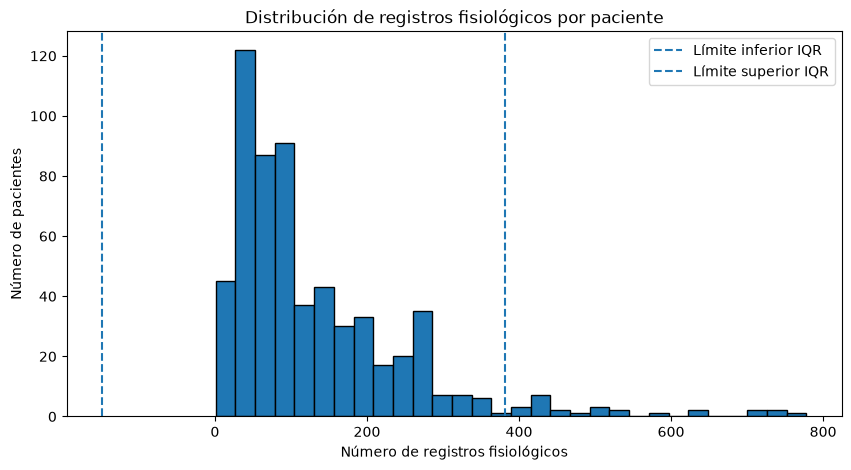

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    records_per_patient,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    lower_bound,
    linestyle="--",
    label="Límite inferior IQR"
)

plt.axvline(
    upper_bound,
    linestyle="--",
    label="Límite superior IQR"
)

plt.xlabel("Número de registros fisiológicos")
plt.ylabel("Número de pacientes")
plt.title("Distribución de registros fisiológicos por paciente")
plt.legend()

plt.show()

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_96299/3402258881.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(records_per_patient, vert=True)


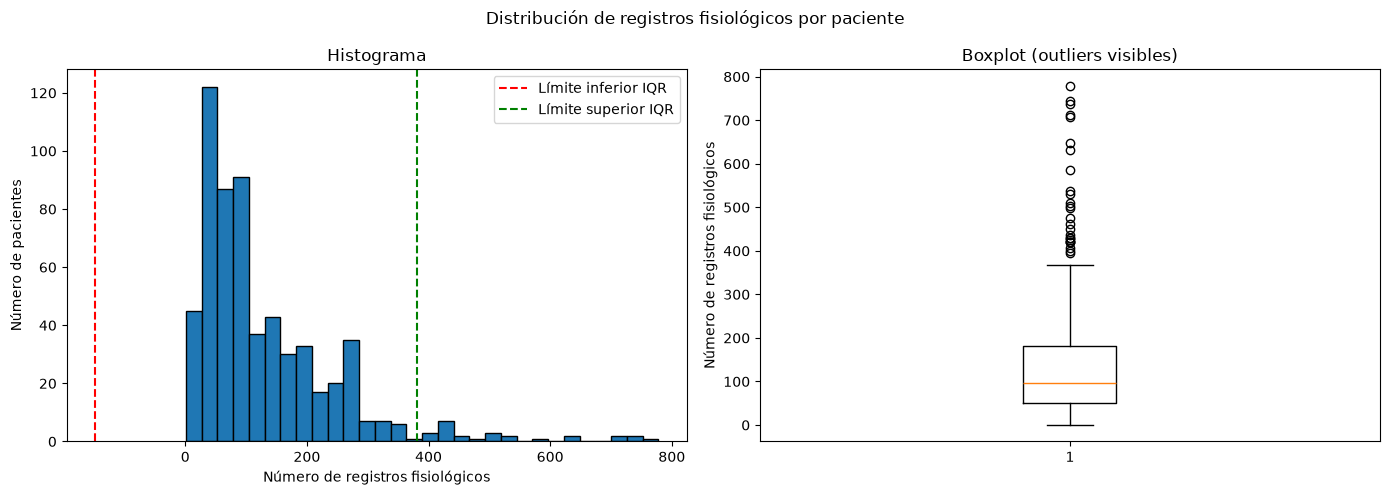

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(records_per_patient, bins=30, edgecolor="black")
axes[0].axvline(lower_bound, linestyle="--", color="red", label="Límite inferior IQR")
axes[0].axvline(upper_bound, linestyle="--", color="green", label="Límite superior IQR")
axes[0].set_xlabel("Número de registros fisiológicos")
axes[0].set_ylabel("Número de pacientes")
axes[0].set_title("Histograma")
axes[0].legend()

axes[1].boxplot(records_per_patient, vert=True)
axes[1].set_ylabel("Número de registros fisiológicos")
axes[1].set_title("Boxplot (outliers visibles)")

fig.suptitle("Distribución de registros fisiológicos por paciente")
plt.tight_layout()
plt.show()

In [40]:
outlier_patients = records_per_patient[
    (records_per_patient < lower_bound) |
    (records_per_patient > upper_bound)
]


In [41]:
outlier_patient_ids = outlier_patients.index.tolist()

print(
    "Pacientes conservados y marcados para inspección:",
    len(outlier_patient_ids)
)

print("IDs de pacientes atípicos:", outlier_patient_ids)

Pacientes conservados y marcados para inspección: 26
IDs de pacientes atípicos: ['0332', '0348', '0354', '0358', '0363', '0377', '0391', '0397', '0430', '0472', '0486', '0533', '0553', '0566', '0672', '0710', '0730', '0732', '0734', '0755', '0784', '0805', '0851', '0922', '0935', '0973']


### Registros corruptos o inaccesibles

La presencia de un registro en los archivos `RECORDS` indica que este se encuentra declarado 
dentro de la estructura del conjunto de datos, pero no garantiza por sí sola que los archivos 
asociados sean accesibles o que sus metadatos puedan ser interpretados correctamente.

Para evitar la descarga innecesaria de las señales fisiológicas completas (`.mat`), la 
verificación inicial se realiza utilizando los archivos de encabezado (`.hea`), que contienen 
los metadatos de cada registro y tienen un tamaño considerablemente menor.

En esta etapa se verifica primero la accesibilidad de los encabezados. La integridad de las 
señales contenidas en los archivos `.mat` será evaluada posteriormente sobre los registros 
seleccionados para el análisis.

In [42]:
eeg_df = records_df[
    records_df["Modality"] == "EEG"
].copy()

print("Registros fisiológicos totales:", len(records_df))
print("Registros EEG:", len(eeg_df))
print("Pacientes con EEG:", eeg_df["Patient"].nunique())

Registros fisiológicos totales: 80809
Registros EEG: 36123
Pacientes con EEG: 607


In [43]:
sample_eeg = eeg_df.iloc[0]

patient_id = sample_eeg["Patient"]
record_name = sample_eeg["Record"]

header_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/"
    f"{record_name}.hea"
)

response = session.head(
    header_url,
    timeout=30
)

print("Patient:", patient_id)
print("Record:", record_name)
print("Status:", response.status_code)
print("Content-Length:", response.headers.get("content-length"))

Patient: 0284
Record: 0284_001_004_EEG
Status: 200
Content-Length: 1553


#### Verificación de accesibilidad de los encabezados EEG

La accesibilidad y consistencia de los archivos asociados a los registros EEG debe ser 
verificada antes de utilizar las señales. Sin embargo, realizar esta comprobación sobre la 
totalidad de los registros disponibles implicaría efectuar decenas de miles de solicitudes 
individuales al servidor de PhysioNet.

Por esta razón, en esta etapa no se realiza una validación exhaustiva de los archivos `.hea` 
y `.mat`. Los registros declarados en los archivos `RECORDS` se conservan inicialmente y la 
verificación de accesibilidad e integridad se pospone hasta después de aplicar los criterios 
de selección del proyecto.

De esta manera, las comprobaciones sobre los archivos físicos se realizarán únicamente sobre 
los registros candidatos, reduciendo el número de solicitudes y evitando la descarga 
innecesaria de señales que posteriormente no serán utilizadas.

### Selección de los datos

Después de evaluar la calidad estructural del inventario de registros fisiológicos, se procede 
a seleccionar los datos relevantes para el objetivo del proyecto.

La selección se realiza de manera progresiva. En primer lugar, se restringe el conjunto a los 
registros correspondientes a la modalidad EEG. Posteriormente, se analiza la información 
contenida en los identificadores de los registros con el propósito de caracterizar su 
distribución temporal y aplicar los criterios temporales definidos para el estudio.

La validación de los archivos `.hea` y la descarga de las señales `.mat` se realizan después 
de esta selección, evitando procesar archivos que no serán utilizados en las etapas 
posteriores.

In [44]:
eeg_df = records_df[
    records_df["Modality"] == "EEG"
].copy()

print("Registros fisiológicos totales:", len(records_df))
print("Registros EEG seleccionados:", len(eeg_df))
print("Pacientes con registros EEG:", eeg_df["Patient"].nunique())

Registros fisiológicos totales: 80809
Registros EEG seleccionados: 36123
Pacientes con registros EEG: 607


### Selección por modalidad

El proyecto se centra exclusivamente en el análisis de señales electroencefalográficas. 
Por esta razón, se seleccionan los registros cuya modalidad corresponde a `EEG`, mientras 
que los registros `ECG`, `REF` y `OTHER` no continúan en el pipeline de preparación.

Esta selección no corresponde a una eliminación por problemas de calidad, sino a una 
restricción determinada por el objetivo analítico del proyecto.

In [45]:
record_parts = (
    eeg_df["Record"]
    .str.extract(
        r"^(?P<Patient_ID>\d+)_(?P<Part_1>\d+)_(?P<Part_2>\d+)_EEG$"
    )
)

display(record_parts.head(20))

,Patient_ID,Part_1,Part_2
1,0284,001,004
4,0284,002,005
7,0284,003,006
10,0284,004,007
13,0284,005,008
16,0284,006,008
19,0284,007,009
22,0284,008,010
25,0284,009,011
28,0284,010,012


In [46]:
valid_structure = record_parts.notna().all(axis=1)

print(
    "Registros EEG con estructura esperada:",
    valid_structure.sum()
)

print(
    "Registros EEG con estructura diferente:",
    (~valid_structure).sum()
)

Registros EEG con estructura esperada: 36123
Registros EEG con estructura diferente: 0


In [47]:
record_parts["Part_1"] = pd.to_numeric(
    record_parts["Part_1"],
    errors="coerce"
)

record_parts["Part_2"] = pd.to_numeric(
    record_parts["Part_2"],
    errors="coerce"
)

print("Part_1:")
display(record_parts["Part_1"].describe())

print("\nPart_2:")
display(record_parts["Part_2"].describe())

print("\nValores únicos de Part_1:")
print(
    sorted(
        record_parts["Part_1"]
        .dropna()
        .unique()
    )[:100]
)

print("\nValores únicos de Part_2:")
print(
    sorted(
        record_parts["Part_2"]
        .dropna()
        .unique()
    )[:100]
)

Part_1:


count    36123.000000
mean        46.134762
std         45.700211
min          1.000000
25%         16.000000
50%         34.000000
75%         61.000000
max        389.000000
Name: Part_1, dtype: float64


Part_2:


count    36123.000000
mean        58.914182
std         55.025769
min          0.000000
25%         28.000000
50%         45.000000
75%         71.000000
max        662.000000
Name: Part_2, dtype: float64


Valores únicos de Part_1:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), n

In [48]:
record_parts = (
    eeg_df["Record"]
    .str.extract(
        r"^(?P<Patient_ID>\d+)_(?P<Segment>\d+)_(?P<Hour>\d+)_EEG$"
    )
)

record_parts["Segment"] = pd.to_numeric(
    record_parts["Segment"],
    errors="coerce"
)

record_parts["Hour"] = pd.to_numeric(
    record_parts["Hour"],
    errors="coerce"
)

display(record_parts.head(10))

,Patient_ID,Segment,Hour
1,0284,1,4
4,0284,2,5
7,0284,3,6
10,0284,4,7
13,0284,5,8
16,0284,6,8
19,0284,7,9
22,0284,8,10
25,0284,9,11
28,0284,10,12


In [49]:
eeg_df["Segment"] = record_parts["Segment"].values
eeg_df["Hour"] = record_parts["Hour"].values

display(
    eeg_df[
        ["Patient", "Record", "Segment", "Hour"]
    ].head(10)
)

,Patient,Record,Segment,Hour
1,0284,0284_001_004_EEG,1,4
4,0284,0284_002_005_EEG,2,5
7,0284,0284_003_006_EEG,3,6
10,0284,0284_004_007_EEG,4,7
13,0284,0284_005_008_EEG,5,8
16,0284,0284_006_008_EEG,6,8
19,0284,0284_007_009_EEG,7,9
22,0284,0284_008_010_EEG,8,10
25,0284,0284_009_011_EEG,9,11
28,0284,0284_010_012_EEG,10,12


### Selección temporal de los registros EEG

Los identificadores de los registros EEG siguen una estructura que permite identificar tanto 
la secuencia del segmento como la hora de monitorización asociada. Por ejemplo, PhysioNet 
documenta que el registro `0284_001_004_EEG` corresponde al primer segmento EEG del paciente 
0284 y contiene datos registrados durante la hora 4 posterior al paro cardíaco.

Los registros se encuentran segmentados de manera que cada segmento finaliza al alcanzar el 
cambio de hora o al finalizar la grabación. En consecuencia, la última componente numérica 
del identificador puede utilizarse como una primera referencia temporal para seleccionar los 
registros candidatos.

Para el presente proyecto se consideran los registros correspondientes al intervalo de 
24 a 32 horas posterior al paro cardíaco. Esta selección se realiza inicialmente utilizando 
la hora codificada en el identificador del registro. La información temporal exacta y la 
duración efectiva de cada segmento serán verificadas posteriormente mediante los archivos 
de encabezado `.hea`.

In [50]:
eeg_selected = eeg_df[
    eeg_df["Hour"].between(
        24,
        32,
        inclusive="both"
    )
].copy()

print("Registros EEG originales:", len(eeg_df))
print("Registros EEG entre 24 y 32 h:", len(eeg_selected))
print(
    "Pacientes representados:",
    eeg_selected["Patient"].nunique()
)

Registros EEG originales: 36123
Registros EEG entre 24 y 32 h: 4691
Pacientes representados: 531


In [51]:
records_by_hour = (
    eeg_selected
    .groupby("Hour")
    .size()
    .rename("Number_of_records")
)

display(records_by_hour.to_frame())

,Number_of_records
Hour,
24,520
25,518
26,515
27,520
28,526
29,521
30,524
31,521
32,526


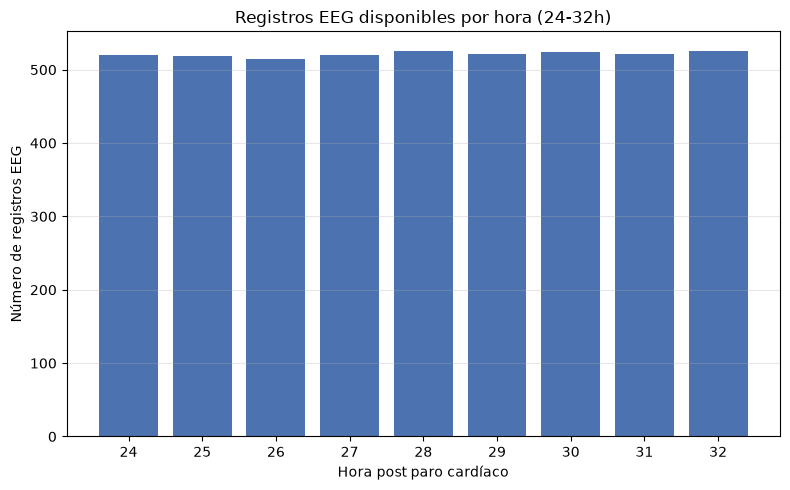

In [52]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    records_by_hour.index.astype(str),
    records_by_hour.values,
    color="#4C72B0"
)

ax.set_xlabel("Hora post paro cardíaco")
ax.set_ylabel("Número de registros EEG")
ax.set_title("Registros EEG disponibles por hora (24-32h)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Resultado de la selección temporal

La selección inicial del intervalo comprendido entre las horas 24 y 32 produjo **4,691 registros EEG candidatos**. La disponibilidad de registros es relativamente uniforme a lo largo del intervalo analizado, con entre 515 y 526 registros por hora.

Esta selección reduce el conjunto inicial de 36,123 registros EEG a aproximadamente el 13.0 % de los registros disponibles. La reducción permite concentrar las siguientes verificaciones de calidad y disponibilidad sobre los registros temporalmente relevantes para el proyecto, evitando procesar de manera innecesaria la totalidad de las señales EEG.

La selección basada en la hora codificada en el identificador constituye una primera aproximación temporal. En las siguientes etapas se utilizarán los metadatos de los archivos `.hea` para verificar las características de los registros candidatos antes de descargar y procesar las señales `.mat`.

In [53]:
patients_by_hour = (
    eeg_selected
    .groupby("Hour")["Patient"]
    .nunique()
    .rename("Number_of_patients")
)

selection_by_hour = pd.concat(
    [
        records_by_hour,
        patients_by_hour
    ],
    axis=1
)

display(selection_by_hour)

print(
    "Pacientes únicos en 24–32 h:",
    eeg_selected["Patient"].nunique()
)

,Number_of_records,Number_of_patients
Hour,,
24,520,477
25,518,480
26,515,478
27,520,485
28,526,487
29,521,487
30,524,492
31,521,490
32,526,488


Pacientes únicos en 24–32 h: 531


In [54]:
records_patient_hour = (
    eeg_selected
    .groupby(["Patient", "Hour"])
    .size()
    .rename("Records")
)

print(
    "Máximo número de registros para un mismo paciente y hora:",
    records_patient_hour.max()
)

display(
    records_patient_hour
    .value_counts()
    .sort_index()
    .to_frame("Patient-hour combinations")
)

Máximo número de registros para un mismo paciente y hora: 3


,Patient-hour combinations
Records,
1,4038
2,325
3,1


#### Distribución de registros por paciente y hora

Después de aplicar la selección temporal entre las horas 24 y 32, se analizó la cantidad de 
registros EEG disponibles para cada combinación paciente-hora.

La mayoría de las combinaciones paciente-hora (4,038) contienen un único registro EEG. Sin 
embargo, 325 combinaciones contienen dos registros y una combinación contiene tres registros. 
Por lo tanto, la relación entre paciente y hora no es necesariamente uno a uno.

La existencia de múltiples registros dentro de una misma hora no se considera duplicidad, ya 
que los identificadores corresponden a segmentos diferentes de la señal EEG. Estos segmentos 
se conservan inicialmente y su duración y posición temporal serán verificadas posteriormente 
mediante los metadatos contenidos en los archivos `.hea`.

Asimismo, el número de pacientes con EEG disponible permanece relativamente estable durante 
el intervalo estudiado, desde 477 pacientes en la hora 24 hasta aproximadamente 490 pacientes 
en las horas posteriores.

In [55]:
selected_hours = [24, 26, 28, 30, 32]

eeg_selected_hours = eeg_df[
    eeg_df["Hour"].isin(selected_hours)
].copy()

print(
    "Registros EEG seleccionados:",
    len(eeg_selected_hours)
)

print(
    "Pacientes únicos:",
    eeg_selected_hours["Patient"].nunique()
)

display(
    eeg_selected_hours
    .groupby("Hour")
    .agg(
        Number_of_records=("Record", "size"),
        Number_of_patients=("Patient", "nunique")
    )
)

Registros EEG seleccionados: 2611
Pacientes únicos: 531


,Number_of_records,Number_of_patients
Hour,,
24,520,477
26,515,478
28,526,487
30,524,492
32,526,488


#### Reducción progresiva del conjunto de registros EEG

La aplicación sucesiva de los criterios de selección permite reducir considerablemente el 
número de registros EEG que deben ser inspeccionados y procesados:

- **36,123 registros EEG** disponibles inicialmente.
- **4,691 registros EEG** correspondientes al intervalo entre 24 y 32 horas.
- **2,611 registros EEG** correspondientes específicamente a las horas 24, 26, 28, 30 y 32.

En consecuencia, la selección temporal reduce aproximadamente un **92.8 %** el número de 
registros con respecto al inventario EEG original.

Esta reducción es relevante desde el punto de vista computacional, ya que evita realizar 
solicitudes y descargas innecesarias sobre registros que no forman parte del diseño 
experimental.

Sin embargo, la selección temporal todavía puede contener más de un registro para una misma 
combinación paciente-hora. Esto ocurre porque una señal EEG puede encontrarse dividida en 
varios segmentos dentro de una misma hora de monitorización. Por esta razón, estos registros 
no se consideran duplicados ni se eliminan automáticamente.

El objetivo posterior será obtener **un segmento EEG de 90 segundos por paciente para cada 
punto temporal seleccionado**. Para determinar qué registro puede proporcionar dicho segmento, 
será necesario consultar los metadatos de los archivos `.hea`, incluyendo la información 
temporal y la duración de los registros candidatos.

Por lo tanto, la inspección de los archivos `.hea` se realiza después de esta reducción y 
únicamente sobre los registros candidatos, antes de proceder con la descarga de las señales 
`.mat`.

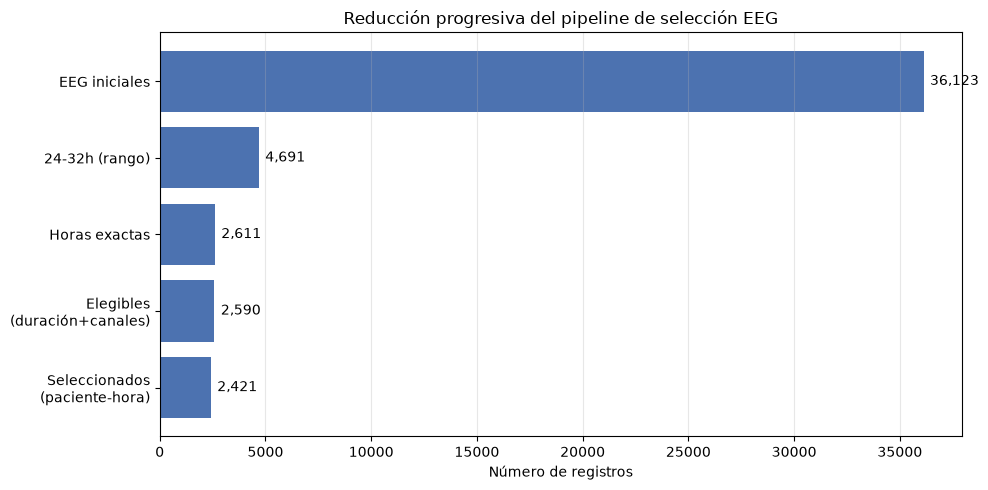

In [56]:
funnel_labels = [
    "EEG iniciales",
    "24-32h (rango)",
    "Horas exactas",
    "Elegibles\n(duración+canales)",
    "Seleccionados\n(paciente-hora)"
]

funnel_values = [
    36123,
    4691,
    2611,
    2590,
    2421
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(funnel_labels, funnel_values, color="#4C72B0")

for i, value in enumerate(funnel_values):
    ax.text(value + 300, i, f"{value:,}", va="center")

ax.invert_yaxis()
ax.set_xlabel("Número de registros")
ax.set_title("Reducción progresiva del pipeline de selección EEG")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Validación de metadatos de los registros EEG seleccionados

Después de aplicar los criterios de modalidad y selección temporal, se procede a inspeccionar 
los archivos de encabezado (`.hea`) correspondientes únicamente a los registros EEG candidatos.

A diferencia de la verificación inicial de accesibilidad, en esta etapa se requiere conocer 
la estructura y duración de cada registro para determinar si puede proporcionar el segmento 
de 90 segundos requerido por el diseño experimental.

Los archivos `.hea` contienen los metadatos necesarios para caracterizar cada registro sin 
necesidad de descargar todavía las señales completas almacenadas en los archivos `.mat`.

Para cada registro candidato se verificará su accesibilidad y se extraerán los metadatos 
necesarios para determinar posteriormente su elegibilidad. Los registros cuyo encabezado no 
pueda ser recuperado o interpretado serán identificados para su inspección antes de la 
selección definitiva de las señales.

In [57]:
sample_record = eeg_selected_hours.iloc[0]

patient_id = sample_record["Patient"]
record_name = sample_record["Record"]

header_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/"
    f"{record_name}.hea"
)

response = session.get(
    header_url,
    timeout=30
)

response.raise_for_status()

header_text = response.text

print("Patient:", patient_id)
print("Record:", record_name)
print("Status:", response.status_code)

print("\n----- HEADER -----")
print(header_text)

Patient: 0284
Record: 0284_025_024_EEG
Status: 200

----- HEADER -----
0284_025_024_EEG 19 500 229500
0284_025_024_EEG.mat 16+24 526.7411150516679(-13168)/nu 16 0 515 -4286 0 Fp1
0284_025_024_EEG.mat 16+24 434.06739580305(-8266)/nu 16 0 12250 3732 0 Fp2
0284_025_024_EEG.mat 16+24 796.9931195947929(-13698)/nu 16 0 -6226 -14284 0 F3
0284_025_024_EEG.mat 16+24 863.665629005069(-17417)/nu 16 0 21043 15015 0 F4
0284_025_024_EEG.mat 16+24 1270.962518270783(-17873)/nu 16 0 -30161 12340 0 C3
0284_025_024_EEG.mat 16+24 1288.0388155326684(19686)/nu 16 0 27736 -20697 0 C4
0284_025_024_EEG.mat 16+24 1058.4671945526416(-21500)/nu 16 0 -28839 8126 0 P3
0284_025_024_EEG.mat 16+24 924.3363707074543(-18053)/nu 16 0 1715 -27142 0 P4
0284_025_024_EEG.mat 16+24 601.3155871266445(-15561)/nu 16 0 -14093 11930 0 O1
0284_025_024_EEG.mat 16+24 667.729564344649(-3554)/nu 16 0 7075 27447 0 O2
0284_025_024_EEG.mat 16+24 740.6933812362062(-15841)/nu 16 0 -16275 21010 0 F7
0284_025_024_EEG.mat 16+24 687.56987734354

### Extracción de metadatos de los encabezados EEG

Los archivos `.hea` contienen la información necesaria para interpretar la estructura de cada 
registro EEG sin necesidad de descargar inicialmente la señal completa almacenada en el 
archivo `.mat`.

Para facilitar el análisis de estos encabezados, se define una función que extrae de manera 
automática sus principales metadatos. A partir de la primera línea del formato WFDB se obtiene 
el nombre del registro, el número de señales, la frecuencia de muestreo y el número total de 
muestras. Con esta información también se calcula la duración del registro en segundos.

Posteriormente, se identifican los nombres de los canales EEG y algunos metadatos adicionales 
incluidos por I-CARE, como la hora de inicio, la hora de finalización y la frecuencia de la red 
eléctrica (*utility frequency*).

La función se valida inicialmente utilizando el encabezado de un registro de ejemplo. Esta 
verificación permite comprobar que los metadatos pueden extraerse correctamente antes de 
aplicar el procedimiento al conjunto completo de registros EEG candidatos.

In [58]:
def parse_eeg_header(header_text):

    lines = [
        line.strip()
        for line in header_text.splitlines()
        if line.strip()
    ]

    # Primera línea WFDB
    first_line = lines[0].split()

    record_name = first_line[0]
    n_signals = int(first_line[1])
    sampling_frequency = float(first_line[2])
    n_samples = int(first_line[3])

    duration_seconds = (
        n_samples / sampling_frequency
    )

    # Líneas correspondientes a las señales
    signal_lines = lines[1:1 + n_signals]

    channels = [
        line.split()[-1]
        for line in signal_lines
    ]

    # Metadatos adicionales de I-CARE
    start_time = None
    end_time = None
    utility_frequency = None

    for line in lines:

        if line.startswith("#Start time:"):
            start_time = line.split(
                "#Start time:", 1
            )[1].strip()

        elif line.startswith("#End time:"):
            end_time = line.split(
                "#End time:", 1
            )[1].strip()

        elif line.startswith("#Utility frequency:"):
            utility_frequency = line.split(
                "#Utility frequency:", 1
            )[1].strip()

    return {
        "Record": record_name,
        "Number_of_signals": n_signals,
        "Sampling_frequency": sampling_frequency,
        "Number_of_samples": n_samples,
        "Duration_seconds": duration_seconds,
        "Channels": channels,
        "Start_time": start_time,
        "End_time": end_time,
        "Utility_frequency": utility_frequency
    }

In [59]:
sample_metadata = parse_eeg_header(
    header_text
)

for key, value in sample_metadata.items():
    print(f"{key}: {value}")

Record: 0284_025_024_EEG
Number_of_signals: 19
Sampling_frequency: 500.0
Number_of_samples: 229500
Duration_seconds: 459.0
Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Start_time: 24:00:00
End_time: 24:07:38
Utility_frequency: 50


In [60]:
print(
    "Expected shape (signals, samples):",
    (
        sample_metadata["Number_of_signals"],
        sample_metadata["Number_of_samples"]
    )
)

Expected shape (signals, samples): (19, 229500)


#### Estructura de los encabezados EEG

La inspección de un archivo `.hea` permitió identificar los metadatos disponibles para cada 
registro EEG. La primera línea del encabezado contiene el número de señales, la frecuencia 
de muestreo y el número total de muestras. A partir de estos dos últimos valores es posible 
calcular la duración efectiva del registro.

Adicionalmente, el encabezado contiene la identificación de los canales EEG y metadatos 
temporales como la hora de inicio y finalización del segmento.

Por ejemplo, el registro `0284_025_024_EEG` contiene 19 señales, una frecuencia de muestreo 
de 500 Hz y 229,500 muestras, correspondientes a aproximadamente 459 segundos de señal. El 
encabezado indica además un intervalo temporal desde `24:00:00` hasta `24:07:38`.

Esta información permite determinar la elegibilidad de cada registro sin descargar todavía 
el archivo `.mat`. En particular, los metadatos serán utilizados para identificar registros 
con duración suficiente para extraer el segmento de 90 segundos requerido por el proyecto y 
para verificar posteriormente la disponibilidad de los canales EEG necesarios.

#### Extracción de metadatos de los registros candidatos

Una vez validada la estructura de los archivos de encabezado, se extraen los metadatos de los 
registros EEG correspondientes a las horas 24, 26, 28, 30 y 32.

Para cada registro se consulta únicamente el archivo `.hea`, sin descargar todavía la señal 
completa almacenada en `.mat`. Se almacenan la frecuencia de muestreo, el número de señales, 
el número de muestras, la duración, los canales disponibles y la información temporal del 
registro.

También se registra cualquier error de acceso o interpretación del encabezado. De esta forma, 
la siguiente etapa de selección puede realizarse localmente utilizando los metadatos 
recuperados, sin efectuar nuevas solicitudes al servidor.

In [61]:
from tqdm import tqdm
import pandas as pd
import requests

eeg_metadata = []

for row in tqdm(
    eeg_selected_hours.itertuples(index=False),
    total=len(eeg_selected_hours),
    desc="Procesando headers EEG",
    unit="registro"
):

    patient_id = row.Patient
    record_name = row.Record
    hour = row.Hour
    segment = row.Segment

    header_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/"
        f"{record_name}.hea"
    )

    try:

        response = session.get(
            header_url,
            timeout=30
        )

        response.raise_for_status()

        metadata = parse_eeg_header(
            response.text
        )

        eeg_metadata.append({
            "Patient": patient_id,
            "Record": record_name,
            "Segment": segment,
            "Hour": hour,
            "Header_accessible": True,
            "Number_of_signals": metadata["Number_of_signals"],
            "Sampling_frequency": metadata["Sampling_frequency"],
            "Number_of_samples": metadata["Number_of_samples"],
            "Duration_seconds": metadata["Duration_seconds"],
            "Channels": metadata["Channels"],
            "Start_time": metadata["Start_time"],
            "End_time": metadata["End_time"],
            "Utility_frequency": metadata["Utility_frequency"],
            "Error": None
        })

    except Exception as error:

        eeg_metadata.append({
            "Patient": patient_id,
            "Record": record_name,
            "Segment": segment,
            "Hour": hour,
            "Header_accessible": False,
            "Number_of_signals": None,
            "Sampling_frequency": None,
            "Number_of_samples": None,
            "Duration_seconds": None,
            "Channels": None,
            "Start_time": None,
            "End_time": None,
            "Utility_frequency": None,
            "Error": str(error)
        })

Procesando headers EEG: 100%|██████████| 2611/2611 [05:31<00:00,  7.87registro/s]


In [62]:
eeg_metadata_df = pd.DataFrame(
    eeg_metadata
)

print(
    "Dimensiones:",
    eeg_metadata_df.shape
)

display(
    eeg_metadata_df.head()
)

Dimensiones: (2611, 14)


,Patient,Record,Segment,Hour,Header_accessible,Number_of_signals,Sampling_frequency,Number_of_samples,Duration_seconds,Channels,Start_time,End_time,Utility_frequency,Error
0,0284,0284_025_024_EEG,25,24,True,19,500.0,229500,459.0,"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7,...",24:00:00,24:07:38,50,None
1,0284,0284_026_024_EEG,26,24,True,19,500.0,1569000,3138.0,"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7,...",24:07:42,24:59:59,50,None
2,0284,0284_028_028_EEG,28,28,True,19,500.0,606000,1212.0,"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7,...",28:39:48,28:59:59,50,None
3,0284,0284_030_030_EEG,30,30,True,19,500.0,1800000,3600.0,"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7,...",30:00:00,30:59:59,50,None
4,0284,0284_032_032_EEG,32,32,True,19,500.0,1194000,2388.0,"[Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7,...",32:00:00,32:39:47,50,None


In [63]:
print(
    "Headers accesibles:",
    eeg_metadata_df["Header_accessible"].sum()
)

print(
    "Headers no accesibles:",
    (~eeg_metadata_df["Header_accessible"]).sum()
)

print("\nFrecuencias de muestreo:")
display(
    eeg_metadata_df[
        "Sampling_frequency"
    ].value_counts(
        dropna=False
    ).sort_index()
)

print("\nNúmero de señales:")
display(
    eeg_metadata_df[
        "Number_of_signals"
    ].value_counts(
        dropna=False
    ).sort_index()
)

print("\nDuración de los registros:")
display(
    eeg_metadata_df[
        "Duration_seconds"
    ].describe()
)

Headers accesibles: 2611
Headers no accesibles: 0

Frecuencias de muestreo:


Sampling_frequency
200.0      147
250.0      446
256.0     1223
500.0      543
512.0      218
1024.0      14
2048.0      20
Name: count, dtype: int64


Número de señales:


Number_of_signals
19     996
20    1541
21      74
Name: count, dtype: int64


Duración de los registros:


count    2611.000000
mean     3287.928020
std       817.122301
min         7.003906
25%      3600.000000
50%      3600.000000
75%      3600.000000
max      3600.000000
Name: Duration_seconds, dtype: float64

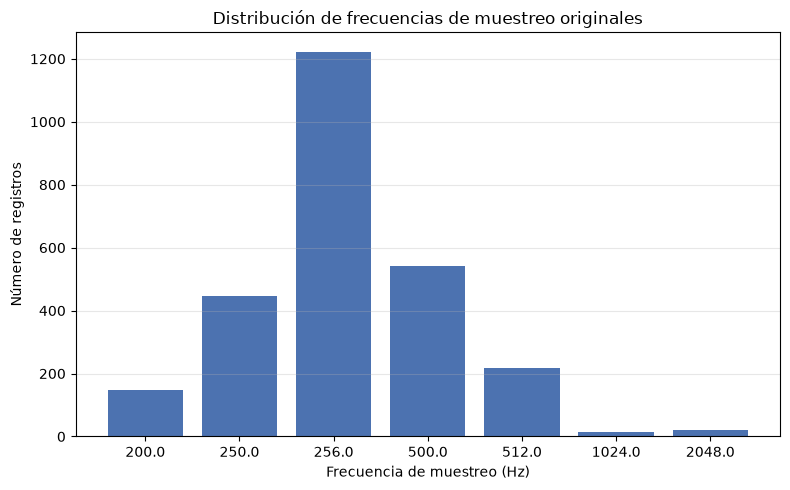

In [64]:
sampling_counts = (
    eeg_metadata_df["Sampling_frequency"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    sampling_counts.index.astype(str),
    sampling_counts.values,
    color="#4C72B0"
)

ax.set_xlabel("Frecuencia de muestreo (Hz)")
ax.set_ylabel("Número de registros")
ax.set_title("Distribución de frecuencias de muestreo originales")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
duration_summary = pd.Series({
    "Menor de 90 s": (
        eeg_metadata_df["Duration_seconds"] < 90
    ).sum(),

    "Al menos 90 s": (
        eeg_metadata_df["Duration_seconds"] >= 90
    ).sum(),

    "Duración desconocida": (
        eeg_metadata_df["Duration_seconds"].isna()
    ).sum()
})

display(
    duration_summary.to_frame(
        name="Number_of_records"
    )
)

,Number_of_records
Menor de 90 s,21
Al menos 90 s,2590
Duración desconocida,0


#### Evaluación de los metadatos de los registros candidatos

Se recuperaron correctamente los archivos `.hea` correspondientes a los **2,611 registros EEG 
candidatos**, sin identificarse encabezados inaccesibles. Por lo tanto, todos los registros 
seleccionados temporalmente pudieron ser caracterizados mediante sus metadatos.

Las frecuencias de muestreo no son uniformes entre los registros. Se identificaron frecuencias 
de 200, 250, 256, 500, 512, 1024 y 2048 Hz. Esta heterogeneidad deberá ser considerada 
posteriormente durante el preprocesamiento, mediante la definición de una frecuencia de 
muestreo común para las señales seleccionadas.

El número de señales por registro también presenta variación: se encontraron registros con 
19, 20 y 21 señales. Por esta razón, la elegibilidad definitiva no debe determinarse únicamente 
por el número total de señales, sino por la disponibilidad de los canales EEG requeridos por 
el proyecto.

Respecto a la duración, **2,590 registros (99.2 %) contienen al menos 90 segundos de señal**, 
mientras que únicamente **21 registros (0.8 %) presentan una duración inferior a 90 segundos**. 
La mayoría de los registros tiene una duración de 3,600 segundos.

Los registros con duración inferior a 90 segundos no se eliminan todavía de manera aislada. 
Primero se evaluará si existe otro segmento perteneciente al mismo paciente y punto temporal 
que permita obtener el intervalo requerido. La selección definitiva se realizará a nivel de 
paciente y hora, considerando conjuntamente la duración y la disponibilidad de canales.

In [66]:
channel_sets = (
    eeg_metadata_df["Channels"]
    .apply(
        lambda channels: tuple(channels)
        if isinstance(channels, list)
        else None
    )
)

channel_configurations = (
    channel_sets
    .value_counts()
    .rename("Number_of_records")
    .to_frame()
)

print(
    "Número de configuraciones de canales:",
    len(channel_configurations)
)

display(
    channel_configurations.head(20)
)

Número de configuraciones de canales: 10


,Number_of_records
Channels,
"(Fp1, Fp2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, Fz, Cz, Pz)",550
"(C3, C4, O1, O2, Cz, F3, F4, F7, F8, Fz, Fp1, Fp2, Fpz, P3, P4, Pz, T3, T4, T5, T6)",513
"(Fp1, Fp2, F3, F4, F7, F8, Fz, C3, C4, Cz, T3, T4, T5, T6, P3, P4, Pz, O1, O2)",446
"(C3, F3, Cz, Fpz, C4, F8, T3, F7, Fp1, Fz, Fp2, F4, T6, T4, T5, O1, P3, Pz, O2, P4)",417
"(C3, P3, Cz, C4, T6, T3, T5, O1, Pz, O2, P4, F8, T4, F7, Fp1, F3, Fz, Fpz, Fp2, F4)",296
"(C3, C4, Cz, F3, F4, F7, F8, Fz, Fp1, Fp2, Fpz, O1, O2, P3, P4, Pz, T3, T4, T5, T6)",146
"(Fp1, Fp2, F7, F3, Fz, F4, F8, T3, C3, Cz, C4, T4, T5, P3, Pz, P4, T6, O1, O2, F9)",89
"(Fp1, F7, T3, T5, O1, F3, C3, P3, Fz, Cz, Fp2, F8, T4, T6, O2, F4, C4, P4, Fpz, Pz)",80
"(Fp1, F7, T3, T5, O1, F3, C3, P3, Fz, Cz, Fp2, F8, T4, T6, O2, F4, C4, P4, Fpz, Pz, F9)",70


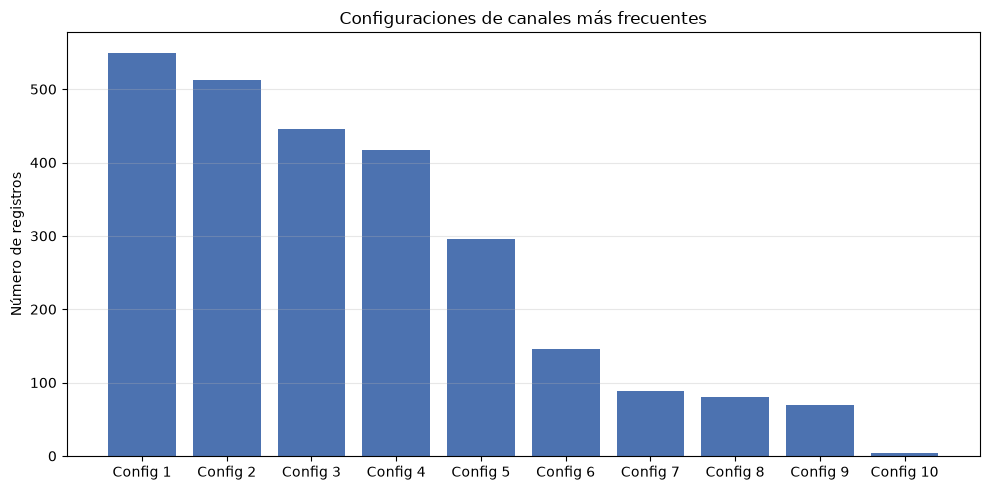

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))

top_configs = channel_configurations.head(10)

ax.bar(
    range(len(top_configs)),
    top_configs["Number_of_records"],
    color="#4C72B0"
)

ax.set_xticks(range(len(top_configs)))
ax.set_xticklabels(
    [f"Config {i+1}" for i in range(len(top_configs))],
    rotation=0
)
ax.set_ylabel("Número de registros")
ax.set_title("Configuraciones de canales más frecuentes")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
from collections import Counter

channel_counter = Counter()

for channels in eeg_metadata_df["Channels"].dropna():
    channel_counter.update(
        set(channels)
    )

channel_availability = (
    pd.DataFrame(
        channel_counter.items(),
        columns=[
            "Channel",
            "Number_of_records"
        ]
    )
    .sort_values(
        "Number_of_records",
        ascending=False
    )
    .reset_index(drop=True)
)

channel_availability["Percentage"] = (
    channel_availability["Number_of_records"]
    / len(eeg_metadata_df)
    * 100
)

display(channel_availability)

,Channel,Number_of_records,Percentage
0,Fp1,2611,100.000000
1,T5,2611,100.000000
2,P4,2611,100.000000
3,F8,2611,100.000000
4,F4,2611,100.000000
5,Fz,2611,100.000000
6,Fp2,2611,100.000000
7,T6,2611,100.000000
8,F3,2611,100.000000
9,P3,2611,100.000000


#### Homogeneidad de los canales EEG

El análisis de los encabezados identificó diez configuraciones diferentes de canales entre los 
2,611 registros candidatos. Sin embargo, estas diferencias no corresponden a la ausencia de 
los canales EEG principales.

Se identificó un conjunto común de **19 canales presentes en el 100 % de los registros**:

`Fp1`, `Fp2`, `F3`, `F4`, `C3`, `C4`, `P3`, `P4`, `O1`, `O2`, `F7`, `F8`, 
`T3`, `T4`, `T5`, `T6`, `Fz`, `Cz` y `Pz`.

Las configuraciones con 20 o 21 señales contienen canales adicionales, principalmente `Fpz` 
y `F9`. Por lo tanto, la variación en el número total de señales no implica pérdida de los 
canales comunes requeridos para el análisis.

En consecuencia, no es necesario excluir registros por disponibilidad de canales. Para 
garantizar una representación homogénea, durante el preprocesamiento se conservarán los 
19 canales comunes y se reorganizarán en un orden consistente para todos los registros. Los 
canales adicionales serán descartados.

In [69]:
common_channels = {
    "Fp1", "Fp2", "F3", "F4",
    "C3", "C4", "P3", "P4",
    "O1", "O2", "F7", "F8",
    "T3", "T4", "T5", "T6",
    "Fz", "Cz", "Pz"
}

eeg_metadata_df["Has_common_channels"] = (
    eeg_metadata_df["Channels"]
    .apply(
        lambda channels:
        common_channels.issubset(set(channels))
    )
)

eeg_metadata_df["Duration_valid"] = (
    eeg_metadata_df["Duration_seconds"] >= 90
)

eeg_metadata_df["Eligible"] = (
    eeg_metadata_df["Header_accessible"]
    & eeg_metadata_df["Has_common_channels"]
    & eeg_metadata_df["Duration_valid"]
)

print(
    eeg_metadata_df[
        [
            "Header_accessible",
            "Has_common_channels",
            "Duration_valid",
            "Eligible"
        ]
    ].sum()
)

Header_accessible      2611
Has_common_channels    2611
Duration_valid         2590
Eligible               2590
dtype: int64


/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_96299/3858389451.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(eligibility_summary.index, rotation=15, ha="right")


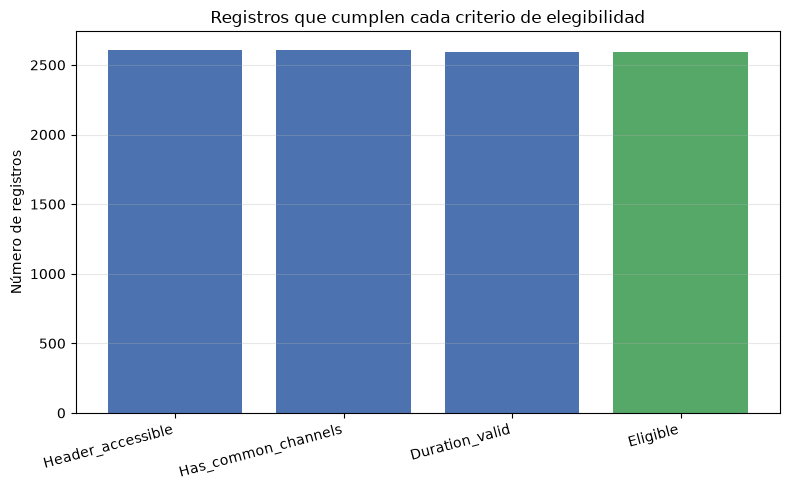

In [70]:
eligibility_summary = eeg_metadata_df[
    ["Header_accessible", "Has_common_channels", "Duration_valid", "Eligible"]
].sum()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    eligibility_summary.index,
    eligibility_summary.values,
    color=["#4C72B0", "#4C72B0", "#4C72B0", "#55A868"]
)

ax.set_ylabel("Número de registros")
ax.set_title("Registros que cumplen cada criterio de elegibilidad")
ax.set_xticklabels(eligibility_summary.index, rotation=15, ha="right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

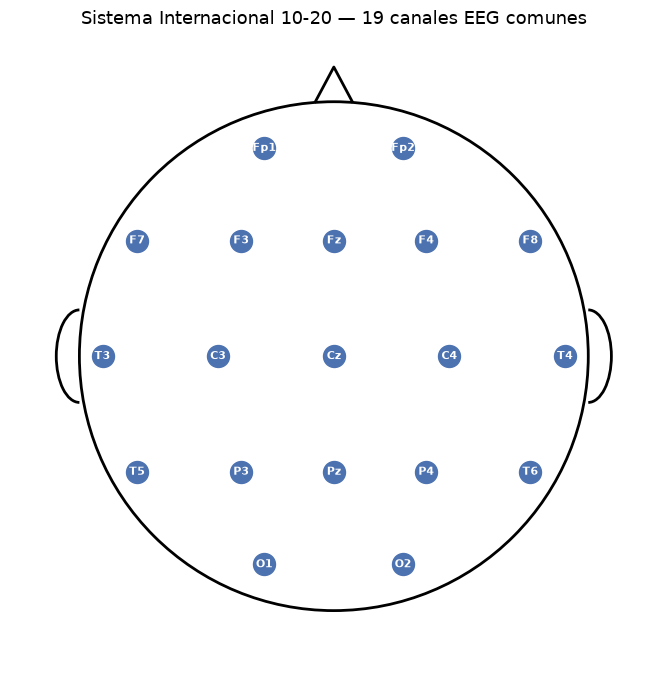

In [71]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Posiciones aproximadas (esquemáticas) de los 19 canales
# del Sistema Internacional 10-20, vista superior de la cabeza
channel_positions = {
    "Fp1": (-0.3, 0.9),  "Fp2": (0.3, 0.9),
    "F7":  (-0.85, 0.5), "F3": (-0.4, 0.5), "Fz": (0, 0.5),
    "F4":  (0.4, 0.5),   "F8": (0.85, 0.5),
    "T3":  (-1.0, 0),    "C3": (-0.5, 0),  "Cz": (0, 0),
    "C4":  (0.5, 0),     "T4": (1.0, 0),
    "T5":  (-0.85, -0.5),"P3": (-0.4, -0.5),"Pz": (0, -0.5),
    "P4":  (0.4, -0.5),  "T6": (0.85, -0.5),
    "O1":  (-0.3, -0.9), "O2": (0.3, -0.9),
}

fig, ax = plt.subplots(figsize=(7, 7))

# Contorno de la cabeza
head = patches.Circle(
    (0, 0), 1.1,
    fill=False,
    linewidth=2
)
ax.add_patch(head)

# Nariz (triángulo simple en la parte superior)
ax.plot(
    [-0.08, 0, 0.08],
    [1.1, 1.25, 1.1],
    color="black",
    linewidth=2
)

# Orejas (dos pequeños arcos a los lados)
for x_sign in [-1, 1]:
    ear = patches.Arc(
        (x_sign * 1.1, 0),
        0.2, 0.4,
        angle=0,
        theta1=-90 if x_sign == 1 else 90,
        theta2=90 if x_sign == 1 else 270,
        linewidth=2
    )
    ax.add_patch(ear)

# Electrodos
for channel, (x, y) in channel_positions.items():
    ax.scatter(x, y, s=250, color="#4C72B0", zorder=3)
    ax.text(
        x, y, channel,
        ha="center", va="center",
        fontsize=8, color="white",
        fontweight="bold", zorder=4
    )

ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(
    "Sistema Internacional 10-20 — 19 canales EEG comunes",
    fontsize=13
)

plt.tight_layout()
plt.show()

In [72]:
patient_hour_eligibility = (
    eeg_metadata_df
    .groupby(["Patient", "Hour"])
    .agg(
        Total_records=("Record", "size"),
        Eligible_records=("Eligible", "sum")
    )
    .reset_index()
)

patient_hour_eligibility["Has_eligible_record"] = (
    patient_hour_eligibility["Eligible_records"] > 0
)

display(
    patient_hour_eligibility[
        "Has_eligible_record"
    ].value_counts()
)

print(
    "Combinaciones paciente-hora totales:",
    len(patient_hour_eligibility)
)

print(
    "Combinaciones sin ningún registro elegible:",
    (~patient_hour_eligibility["Has_eligible_record"]).sum()
)

Has_eligible_record
True     2421
False       1
Name: count, dtype: int64

Combinaciones paciente-hora totales: 2422
Combinaciones sin ningún registro elegible: 1


In [73]:
unavailable_patient_hours = (
    patient_hour_eligibility[
        ~patient_hour_eligibility["Has_eligible_record"]
    ]
)

display(unavailable_patient_hours)

,Patient,Hour,Total_records,Eligible_records,Has_eligible_record
455,0445,24,1,0,False


#### Elegibilidad de los registros EEG

La elegibilidad de los registros EEG se evaluó considerando tres criterios: accesibilidad del 
archivo de encabezado, disponibilidad de los 19 canales EEG comunes y una duración mínima de 
90 segundos.

De los **2,611 registros candidatos**, todos presentaron encabezados accesibles y contienen 
los 19 canales comunes definidos para el análisis. En relación con la duración, **2,590 
registros** cumplen el requisito mínimo de 90 segundos, mientras que 21 registros presentan 
una duración inferior.

Debido a que una misma combinación paciente-hora puede contener múltiples segmentos, la 
presencia de un registro corto no implica necesariamente la exclusión del paciente en ese 
punto temporal. Por esta razón, la elegibilidad se evaluó también a nivel de paciente y hora.

Se identificaron **2,422 combinaciones paciente-hora** en los cinco puntos temporales 
seleccionados. De estas, **2,421 cuentan con al menos un registro elegible**. Únicamente la 
combinación correspondiente al paciente `0445` en la hora 24 no dispone de un registro 
individual con al menos 90 segundos de duración.

En consecuencia, los registros individuales con duración insuficiente no se eliminan de forma 
aislada como pacientes completos. La selección definitiva se realiza a nivel paciente-hora, 
conservando siempre que sea posible un registro elegible para cada punto temporal.

In [74]:
eligible_records = eeg_metadata_df[
    eeg_metadata_df["Eligible"]
].copy()

eligible_per_patient_hour = (
    eligible_records
    .groupby(["Patient", "Hour"])
    .size()
    .rename("Eligible_records")
)

display(
    eligible_per_patient_hour
    .value_counts()
    .sort_index()
    .to_frame("Patient-hour combinations")
)

,Patient-hour combinations
Eligible_records,
1,2253
2,167
3,1


In [75]:
selected_eeg_records = (
    eligible_records
    .sort_values(
        by=[
            "Patient",
            "Hour",
            "Duration_seconds",
            "Segment"
        ],
        ascending=[
            True,
            True,
            False,
            True
        ]
    )
    .drop_duplicates(
        subset=["Patient", "Hour"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "Registros EEG seleccionados:",
    len(selected_eeg_records)
)

print(
    "Pacientes únicos:",
    selected_eeg_records["Patient"].nunique()
)

display(
    selected_eeg_records[
        [
            "Patient",
            "Hour",
            "Record",
            "Duration_seconds",
            "Sampling_frequency",
            "Number_of_signals"
        ]
    ].head(10)
)

Registros EEG seleccionados: 2421
Pacientes únicos: 530


,Patient,Hour,Record,Duration_seconds,Sampling_frequency,Number_of_signals
0,0284,24,0284_026_024_EEG,3138.000000,500.0,19
1,0284,28,0284_028_028_EEG,1212.000000,500.0,19
2,0284,30,0284_030_030_EEG,3600.000000,500.0,19
3,0284,32,0284_032_032_EEG,2388.000000,500.0,19
4,0286,24,0286_005_024_EEG,3600.000000,512.0,20
5,0286,26,0286_008_026_EEG,3600.000000,512.0,20
6,0286,28,0286_010_028_EEG,3600.000000,512.0,20
7,0286,30,0286_012_030_EEG,3201.001953,512.0,20
8,0286,32,0286_015_032_EEG,3600.000000,512.0,20
9,0299,24,0299_005_024_EEG,3600.000000,500.0,19


In [76]:
assert not selected_eeg_records.duplicated(
    subset=["Patient", "Hour"]
).any()

assert (
    selected_eeg_records["Duration_seconds"] >= 90
).all()

assert selected_eeg_records[
    "Has_common_channels"
].all()

print(
    "Selección final validada correctamente."
)

Selección final validada correctamente.


#### Selección definitiva de registros por paciente y hora

Después de aplicar los criterios de elegibilidad, se identificaron **2,421 combinaciones 
paciente-hora** con al menos un registro EEG adecuado para el análisis.

La mayoría de estas combinaciones (**2,253**) dispone de un único registro elegible. Sin 
embargo, 167 combinaciones presentan dos registros elegibles y una combinación presenta tres. 
En estos casos, los registros representan segmentos diferentes de la señal dentro del mismo 
punto temporal y, por lo tanto, no corresponden a observaciones duplicadas.

Para obtener una única observación por paciente y punto temporal, se seleccionó de manera 
determinista el registro elegible con mayor duración dentro de cada combinación paciente-hora. 
En caso de igualdad en la duración, se utiliza como criterio secundario el número de segmento.

Como resultado, el conjunto seleccionado contiene **2,421 registros EEG**, cada uno asociado 
con una única combinación paciente-hora y con una duración mínima de 90 segundos. Todos los 
registros seleccionados contienen los 19 canales EEG comunes definidos para el estudio.

Esta selección constituye el conjunto de registros que continuará hacia las etapas de 
extracción y preprocesamiento de las señales.

### Preprocesamiento y transformación

### Definición de la ventana temporal de análisis

Cada registro EEG seleccionado puede contener varios minutos de señal, mientras que el diseño 
experimental requiere utilizar un segmento de **90 segundos por paciente y punto temporal**.

Para garantizar un criterio uniforme y reproducible, se selecciona una ventana continua de 
90 segundos ubicada en el centro de cada registro EEG. Esta estrategia permite aplicar la 
misma regla de extracción independientemente de la duración total del registro y evita 
seleccionar sistemáticamente los extremos de la grabación.

En esta etapa se calculan únicamente las posiciones temporales de inicio y finalización de la 
ventana. La extracción efectiva de las muestras se realizará posteriormente, una vez se 
descarguen y carguen los archivos `.mat`.

In [77]:
selected_eeg_records["Window_seconds"] = 90

selected_eeg_records["Window_start_seconds"] = (
    selected_eeg_records["Duration_seconds"] / 2
    - selected_eeg_records["Window_seconds"] / 2
)

selected_eeg_records["Window_end_seconds"] = (
    selected_eeg_records["Window_start_seconds"]
    + selected_eeg_records["Window_seconds"]
)

display(
    selected_eeg_records[
        [
            "Patient",
            "Hour",
            "Record",
            "Duration_seconds",
            "Window_start_seconds",
            "Window_end_seconds"
        ]
    ].head(10)
)

,Patient,Hour,Record,Duration_seconds,Window_start_seconds,Window_end_seconds
0,0284,24,0284_026_024_EEG,3138.000000,1524.000000,1614.000000
1,0284,28,0284_028_028_EEG,1212.000000,561.000000,651.000000
2,0284,30,0284_030_030_EEG,3600.000000,1755.000000,1845.000000
3,0284,32,0284_032_032_EEG,2388.000000,1149.000000,1239.000000
4,0286,24,0286_005_024_EEG,3600.000000,1755.000000,1845.000000
5,0286,26,0286_008_026_EEG,3600.000000,1755.000000,1845.000000
6,0286,28,0286_010_028_EEG,3600.000000,1755.000000,1845.000000
7,0286,30,0286_012_030_EEG,3201.001953,1555.500977,1645.500977
8,0286,32,0286_015_032_EEG,3600.000000,1755.000000,1845.000000
9,0299,24,0299_005_024_EEG,3600.000000,1755.000000,1845.000000


#### Validación de las ventanas temporales

Antes de realizar la extracción de las señales, se verifica que la ventana de 90 segundos 
definida para cada registro se encuentre completamente contenida dentro de la duración 
disponible del EEG.

Esta comprobación permite garantizar que las posiciones temporales calculadas sean válidas y 
que posteriormente puedan convertirse de forma segura en índices de muestras de acuerdo con 
la frecuencia de muestreo de cada registro.

In [78]:
selected_eeg_records["Window_valid"] = (
    (selected_eeg_records["Window_start_seconds"] >= 0)
    &
    (
        selected_eeg_records["Window_end_seconds"]
        <= selected_eeg_records["Duration_seconds"]
    )
)

print(
    "Ventanas válidas:",
    selected_eeg_records["Window_valid"].sum()
)

print(
    "Ventanas inválidas:",
    (~selected_eeg_records["Window_valid"]).sum()
)

assert selected_eeg_records["Window_valid"].all(), (
    "Se encontraron ventanas fuera de los límites del registro."
)

print("Todas las ventanas de 90 segundos son válidas.")

Ventanas válidas: 2421
Ventanas inválidas: 0
Todas las ventanas de 90 segundos son válidas.


In [79]:
selected_eeg_records["Start_sample"] = (
    selected_eeg_records["Window_start_seconds"]
    * selected_eeg_records["Sampling_frequency"]
).round().astype(int)

selected_eeg_records["Window_samples"] = (
    selected_eeg_records["Window_seconds"]
    * selected_eeg_records["Sampling_frequency"]
).round().astype(int)

selected_eeg_records["End_sample"] = (
    selected_eeg_records["Start_sample"]
    + selected_eeg_records["Window_samples"]
)

display(
    selected_eeg_records[
        [
            "Patient",
            "Hour",
            "Record",
            "Sampling_frequency",
            "Start_sample",
            "End_sample",
            "Window_samples"
        ]
    ].head(10)
)

,Patient,Hour,Record,Sampling_frequency,Start_sample,End_sample,Window_samples
0,0284,24,0284_026_024_EEG,500.0,762000,807000,45000
1,0284,28,0284_028_028_EEG,500.0,280500,325500,45000
2,0284,30,0284_030_030_EEG,500.0,877500,922500,45000
3,0284,32,0284_032_032_EEG,500.0,574500,619500,45000
4,0286,24,0286_005_024_EEG,512.0,898560,944640,46080
5,0286,26,0286_008_026_EEG,512.0,898560,944640,46080
6,0286,28,0286_010_028_EEG,512.0,898560,944640,46080
7,0286,30,0286_012_030_EEG,512.0,796416,842496,46080
8,0286,32,0286_015_032_EEG,512.0,898560,944640,46080
9,0299,24,0299_005_024_EEG,500.0,877500,922500,45000


In [80]:
sample_window_valid = (
    selected_eeg_records["End_sample"]
    <= selected_eeg_records["Number_of_samples"]
)

print(
    "Ventanas válidas a nivel de muestras:",
    sample_window_valid.sum()
)

print(
    "Ventanas inválidas a nivel de muestras:",
    (~sample_window_valid).sum()
)

assert sample_window_valid.all()

print("Todas las ventanas son válidas a nivel de muestras.")

Ventanas válidas a nivel de muestras: 2421
Ventanas inválidas a nivel de muestras: 0
Todas las ventanas son válidas a nivel de muestras.


### Carga de una señal EEG seleccionada

Una vez definidos y validados los registros y las ventanas temporales de análisis, se realiza 
una prueba de carga sobre un único archivo `.mat`.

El objetivo de esta etapa es verificar la estructura interna de las señales almacenadas, sus 
dimensiones y su correspondencia con los metadatos obtenidos previamente desde el archivo 
`.hea`. Esta comprobación se realiza antes de automatizar la descarga y procesamiento del 
conjunto completo de registros seleccionados.

In [81]:
sample_record = selected_eeg_records.iloc[0]

patient_id = sample_record["Patient"]
record_name = sample_record["Record"]

print("Patient:", patient_id)
print("Record:", record_name)
print("Sampling frequency:", sample_record["Sampling_frequency"])
print("Number of signals:", sample_record["Number_of_signals"])
print("Number of samples:", sample_record["Number_of_samples"])
print("Start sample:", sample_record["Start_sample"])
print("End sample:", sample_record["End_sample"])

Patient: 0284
Record: 0284_026_024_EEG
Sampling frequency: 500.0
Number of signals: 19
Number of samples: 1569000
Start sample: 762000
End sample: 807000


In [82]:
patient_eeg_dir = EEG_DATA / patient_id

signal_path = (
    patient_eeg_dir
    / f"{record_name}.mat"
)

signal_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/"
    f"{record_name}.mat"
)

download_file(
    signal_url,
    signal_path
)

Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0284/0284_026_024_EEG.mat


PosixPath('/Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0284/0284_026_024_EEG.mat')

In [83]:
from scipy.io import loadmat

mat_data = loadmat(
    signal_path
)

print(
    "Variables almacenadas en el archivo:"
)

print(mat_data.keys())

Variables almacenadas en el archivo:
dict_keys(['val'])


In [84]:
print(sample_record.index.tolist())

['Patient', 'Record', 'Segment', 'Hour', 'Header_accessible', 'Number_of_signals', 'Sampling_frequency', 'Number_of_samples', 'Duration_seconds', 'Channels', 'Start_time', 'End_time', 'Utility_frequency', 'Error', 'Has_common_channels', 'Duration_valid', 'Eligible', 'Window_seconds', 'Window_start_seconds', 'Window_end_seconds', 'Window_valid', 'Start_sample', 'Window_samples', 'End_sample']


In [85]:
eeg_signal = mat_data["val"]

print("Shape:", eeg_signal.shape)
print("Data type:", eeg_signal.dtype)
print("Number of dimensions:", eeg_signal.ndim)

print(
    "Expected signals:",
    int(sample_record["Number_of_signals"])
)

print(
    "Expected samples:",
    int(sample_record["Number_of_samples"])
)

Shape: (19, 1569000)
Data type: int16
Number of dimensions: 2
Expected signals: 19
Expected samples: 1569000


#### Correspondencia entre canales y filas de la señal

La estructura del archivo `.mat` fue consistente con la información registrada en el 
encabezado `.hea`: el número de filas de la matriz corresponde al número de señales y el 
número de columnas corresponde al número total de muestras.

La matriz EEG presenta, por tanto, una organización de tipo **canales × muestras**. Antes de 
extraer la ventana temporal de análisis, se verifica la correspondencia entre cada fila de la 
matriz y el nombre del canal definido en el encabezado.

Esta correspondencia es necesaria porque el orden de los canales puede variar entre registros. 
Posteriormente, los canales serán seleccionados y reorganizados utilizando el conjunto común 
de 19 canales definido para el estudio.

In [86]:
channel_names = sample_record["Channels"]

print(
    "Número de canales en el header:",
    len(channel_names)
)

print(
    "Número de filas en la matriz:",
    eeg_signal.shape[0]
)

for index, channel in enumerate(channel_names):
    print(
        f"Fila {index:2d} -> {channel}"
    )

Número de canales en el header: 19
Número de filas en la matriz: 19
Fila  0 -> Fp1
Fila  1 -> Fp2
Fila  2 -> F3
Fila  3 -> F4
Fila  4 -> C3
Fila  5 -> C4
Fila  6 -> P3
Fila  7 -> P4
Fila  8 -> O1
Fila  9 -> O2
Fila 10 -> F7
Fila 11 -> F8
Fila 12 -> T3
Fila 13 -> T4
Fila 14 -> T5
Fila 15 -> T6
Fila 16 -> Fz
Fila 17 -> Cz
Fila 18 -> Pz


In [87]:
COMMON_CHANNELS = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T3", "T4",
    "T5", "T6",
    "Fz", "Cz", "Pz"
]

print(
    "Número de canales EEG comunes:",
    len(COMMON_CHANNELS)
)

Número de canales EEG comunes: 19


In [88]:
assert len(channel_names) == eeg_signal.shape[0], (
    "El número de canales del header no coincide "
    "con las filas de la matriz."
)

assert set(COMMON_CHANNELS).issubset(
    set(channel_names)
), (
    "Faltan canales EEG requeridos."
)

print(
    "Correspondencia de canales validada correctamente."
)

Correspondencia de canales validada correctamente.


In [89]:
channel_indices = [
    channel_names.index(channel)
    for channel in COMMON_CHANNELS
]

print("Orden original:")
print(channel_names)

print("\nOrden seleccionado:")
print(COMMON_CHANNELS)

print("\nÍndices utilizados:")
print(channel_indices)

Orden original:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

Orden seleccionado:
['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

Índices utilizados:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


In [90]:
eeg_signal_19ch = eeg_signal[
    channel_indices,
    :
]

print(
    "Shape después de seleccionar y ordenar canales:",
    eeg_signal_19ch.shape
)

Shape después de seleccionar y ordenar canales: (19, 1569000)


#### Extracción de la ventana EEG de 90 segundos

Una vez estandarizado el conjunto y el orden de los canales, se extrae de la señal EEG la 
ventana temporal de 90 segundos definida previamente.

Las posiciones temporales calculadas se convierten en índices de muestras utilizando la 
frecuencia de muestreo original de cada registro. De esta manera, la duración temporal de la 
ventana permanece constante aunque el número de muestras pueda variar entre registros con 
diferentes frecuencias de muestreo.

In [91]:
start_sample = int(
    sample_record["Start_sample"]
)

end_sample = int(
    sample_record["End_sample"]
)

eeg_window = eeg_signal_19ch[
    :,
    start_sample:end_sample
]

print(
    "Shape señal original:",
    eeg_signal_19ch.shape
)

print(
    "Índice inicial:",
    start_sample
)

print(
    "Índice final:",
    end_sample
)

print(
    "Shape ventana extraída:",
    eeg_window.shape
)

Shape señal original: (19, 1569000)
Índice inicial: 762000
Índice final: 807000
Shape ventana extraída: (19, 45000)


In [92]:
expected_samples = int(
    90 * sample_record["Sampling_frequency"]
)

assert eeg_window.shape[0] == len(COMMON_CHANNELS), (
    "El número de canales no es el esperado."
)

assert eeg_window.shape[1] == expected_samples, (
    "La ventana no contiene exactamente 90 segundos."
)

print(
    "Duración de la ventana:",
    eeg_window.shape[1]
    / sample_record["Sampling_frequency"],
    "segundos"
)

print(
    "Ventana EEG extraída correctamente."
)

Duración de la ventana: 90.0 segundos
Ventana EEG extraída correctamente.


#### Conversión de la señal a unidades físicas

Los valores almacenados en los archivos `.mat` corresponden a valores digitales enteros 
(`int16`). Por lo tanto, antes de aplicar operaciones de preprocesamiento sobre la señal es 
necesario interpretar la información de calibración especificada para cada canal en el 
archivo `.hea`.

La información de calibración permite convertir los valores digitales almacenados en la 
matriz `val` a las unidades físicas correspondientes. Debido a que estos parámetros pueden 
variar entre registros o canales, la conversión se obtiene directamente del encabezado 
asociado con cada señal.

In [93]:
header_lines = [
    line.strip()
    for line in header_text.splitlines()
    if line.strip()
]

n_signals = int(
    header_lines[0].split()[1]
)

signal_lines = header_lines[
    1:1 + n_signals
]

for index, line in enumerate(signal_lines):
    print(
        f"{index:2d}: {line}"
    )

 0: 0284_025_024_EEG.mat 16+24 526.7411150516679(-13168)/nu 16 0 515 -4286 0 Fp1
 1: 0284_025_024_EEG.mat 16+24 434.06739580305(-8266)/nu 16 0 12250 3732 0 Fp2
 2: 0284_025_024_EEG.mat 16+24 796.9931195947929(-13698)/nu 16 0 -6226 -14284 0 F3
 3: 0284_025_024_EEG.mat 16+24 863.665629005069(-17417)/nu 16 0 21043 15015 0 F4
 4: 0284_025_024_EEG.mat 16+24 1270.962518270783(-17873)/nu 16 0 -30161 12340 0 C3
 5: 0284_025_024_EEG.mat 16+24 1288.0388155326684(19686)/nu 16 0 27736 -20697 0 C4
 6: 0284_025_024_EEG.mat 16+24 1058.4671945526416(-21500)/nu 16 0 -28839 8126 0 P3
 7: 0284_025_024_EEG.mat 16+24 924.3363707074543(-18053)/nu 16 0 1715 -27142 0 P4
 8: 0284_025_024_EEG.mat 16+24 601.3155871266445(-15561)/nu 16 0 -14093 11930 0 O1
 9: 0284_025_024_EEG.mat 16+24 667.729564344649(-3554)/nu 16 0 7075 27447 0 O2
10: 0284_025_024_EEG.mat 16+24 740.6933812362062(-15841)/nu 16 0 -16275 21010 0 F7
11: 0284_025_024_EEG.mat 16+24 687.5698773435425(-15913)/nu 16 0 20413 28316 0 F8
12: 0284_025_024_E

In [94]:
header_url = (
    f"{BASE_URL}/training/"
    f"{patient_id}/"
    f"{record_name}.hea"
)

response = session.get(
    header_url,
    timeout=30
)

response.raise_for_status()

header_text = response.text

print(
    "Header correspondiente a:",
    record_name
)

print(
    header_text.splitlines()[0]
)

Header correspondiente a: 0284_026_024_EEG
0284_026_024_EEG 19 500 1569000


In [95]:
header_lines = [
    line.strip()
    for line in header_text.splitlines()
    if line.strip()
]

n_signals = int(
    header_lines[0].split()[1]
)

signal_lines = header_lines[
    1:1 + n_signals
]

for index, line in enumerate(signal_lines):
    print(
        f"{index:2d}: {line}"
    )

 0: 0284_026_024_EEG.mat 16+24 334.6973496998656(3873)/nu 16 0 10410 -22741 0 Fp1
 1: 0284_026_024_EEG.mat 16+24 328.6328039541811(4268)/nu 16 0 9756 10525 0 Fp2
 2: 0284_026_024_EEG.mat 16+24 460.5821523561981(7444)/nu 16 0 15540 -4064 0 F3
 3: 0284_026_024_EEG.mat 16+24 394.28213325692815(11282)/nu 16 0 16403 -18448 0 F4
 4: 0284_026_024_EEG.mat 16+24 539.4438923987573(13486)/nu 16 0 22442 -17027 0 C3
 5: 0284_026_024_EEG.mat 16+24 538.1460954461362(-13480)/nu 16 0 -22624 9375 0 C4
 6: 0284_026_024_EEG.mat 16+24 458.6932302360961(12834)/nu 16 0 20763 -17142 0 P3
 7: 0284_026_024_EEG.mat 16+24 437.46296882450747(11022)/nu 16 0 14269 2112 0 P4
 8: 0284_026_024_EEG.mat 16+24 409.6875409077162(10602)/nu 16 0 16563 -3356 0 O1
 9: 0284_026_024_EEG.mat 16+24 372.4018807402314(8583)/nu 16 0 24330 -4780 0 O2
10: 0284_026_024_EEG.mat 16+24 425.26501471725555(5191)/nu 16 0 10091 30853 0 F7
11: 0284_026_024_EEG.mat 16+24 369.5309410074916(9599)/nu 16 0 11981 -13605 0 F8
12: 0284_026_024_EEG.mat 

#### Extracción de los parámetros de calibración

Cada canal EEG contiene en el archivo `.hea` los parámetros necesarios para interpretar los 
valores digitales almacenados en la matriz de señal. Estos parámetros incluyen la ganancia, 
el valor de referencia o *baseline* y la unidad física declarada para cada canal.

Debido a que estos valores pueden variar entre canales, la información de calibración se 
extrae individualmente para cada señal y se asocia con el nombre del canal correspondiente.


In [96]:
import re
import pandas as pd

calibration_data = []

pattern = re.compile(
    r"(?P<gain>[-+]?\d*\.?\d+)"
    r"\((?P<baseline>[-+]?\d+)\)"
    r"/(?P<unit>\S+)"
)

for line in signal_lines:

    parts = line.split()

    calibration_field = parts[2]
    channel = parts[-1]

    match = pattern.fullmatch(
        calibration_field
    )

    if match is None:
        raise ValueError(
            f"No se pudo interpretar: "
            f"{calibration_field}"
        )

    calibration_data.append({
        "Channel": channel,
        "Gain": float(
            match.group("gain")
        ),
        "Baseline": int(
            match.group("baseline")
        ),
        "Unit": match.group("unit")
    })

calibration_df = pd.DataFrame(
    calibration_data
)

display(calibration_df)

,Channel,Gain,Baseline,Unit
0,Fp1,334.697350,3873,nu
1,Fp2,328.632804,4268,nu
2,F3,460.582152,7444,nu
3,F4,394.282133,11282,nu
4,C3,539.443892,13486,nu
5,C4,538.146095,-13480,nu
6,P3,458.693230,12834,nu
7,P4,437.462969,11022,nu
8,O1,409.687541,10602,nu
9,O2,372.401881,8583,nu


In [97]:
assert len(calibration_df) == eeg_signal.shape[0]

assert (
    calibration_df["Channel"].tolist()
    == channel_names
)

assert (
    calibration_df["Gain"] > 0
).all()

print(
    "Parámetros de calibración "
    "extraídos correctamente."
)

display(
    calibration_df[
        ["Channel", "Gain", "Baseline", "Unit"]
    ]
)

Parámetros de calibración extraídos correctamente.


,Channel,Gain,Baseline,Unit
0,Fp1,334.697350,3873,nu
1,Fp2,328.632804,4268,nu
2,F3,460.582152,7444,nu
3,F4,394.282133,11282,nu
4,C3,539.443892,13486,nu
5,C4,538.146095,-13480,nu
6,P3,458.693230,12834,nu
7,P4,437.462969,11022,nu
8,O1,409.687541,10602,nu
9,O2,372.401881,8583,nu


#### Conversión de la ventana EEG a valores físicos

#### Fundamento de la fórmula de conversión

La fórmula utilizada para convertir los valores digitales a valores físicos no es una 
definición propia del proyecto, sino que corresponde a la especificación oficial del 
**formato WFDB (Waveform Database)**, el estándar utilizado por PhysioNet para todos sus 
conjuntos de datos, incluyendo I-CARE.

Los campos `gain` y `baseline`, extraídos directamente del archivo `.hea` de cada registro, 
están definidos en la documentación del formato de señal de WFDB de la siguiente manera:

> *"Programs compiled using the WFDB library require calibration data in order to convert 
> between sample values (expressed in analog-to-digital converter units, or adus) and 
> physical units [...] the 'gain' and 'baseline' fields [...] are written into the header 
> file for the record."*
> — WFDB Applications Guide, SIGNAL(5), PhysioNet.

A partir de estos parámetros, la conversión de unidades digitales a físicas se define como:

$$
x_{\mathrm{physical}} =
\frac{x_{\mathrm{digital}} - \mathrm{baseline}}
{\mathrm{gain}}
$$

**Referencias:**

- Moody, G. B. *WFDB Applications Guide* — Signal File Format Specification (`SIGNAL(5)`). 
  PhysioNet. Disponible en: https://physionet.org/physiotools/wag/signa-5.htm

- Goldberger, A. L., Amaral, L. A. N., Glass, L., Hausdorff, J. M., Ivanov, P. C., Mark, R. G., 
  Mietus, J. E., Moody, G. B., Peng, C.-K., & Stanley, H. E. (2000). *PhysioBank, PhysioToolkit, 
  and PhysioNet: Components of a New Research Resource for Complex Physiologic Signals.* 
  Circulation, 101(23), e215–e220.

In [98]:
calibration_ordered = (
    calibration_df
    .set_index("Channel")
    .loc[COMMON_CHANNELS]
    .reset_index()
)

display(calibration_ordered)

,Channel,Gain,Baseline,Unit
0,Fp1,334.697350,3873,nu
1,Fp2,328.632804,4268,nu
2,F3,460.582152,7444,nu
3,F4,394.282133,11282,nu
4,C3,539.443892,13486,nu
5,C4,538.146095,-13480,nu
6,P3,458.693230,12834,nu
7,P4,437.462969,11022,nu
8,O1,409.687541,10602,nu
9,O2,372.401881,8583,nu


In [99]:
import numpy as np

gains = calibration_ordered["Gain"].to_numpy(
    dtype=np.float64
)[:, np.newaxis]

baselines = calibration_ordered["Baseline"].to_numpy(
    dtype=np.float64
)[:, np.newaxis]

eeg_window_physical = (
    eeg_window.astype(np.float64)
    - baselines
) / gains

print(
    "Shape:",
    eeg_window_physical.shape
)

print(
    "Data type:",
    eeg_window_physical.dtype
)

print(
    "Valor mínimo:",
    eeg_window_physical.min()
)

print(
    "Valor máximo:",
    eeg_window_physical.max()
)

Shape: (19, 45000)
Data type: float64
Valor mínimo: -50.780079770510945
Valor máximo: 73.43758660004261


In [100]:
assert eeg_window_physical.shape == eeg_window.shape

assert np.isfinite(
    eeg_window_physical
).all()

print(
    "Conversión a valores físicos "
    "realizada correctamente."
)

print(
    "Unidades encontradas:",
    calibration_ordered["Unit"].unique()
)

Conversión a valores físicos realizada correctamente.
Unidades encontradas: <StringArray>
['nu']
Length: 1, dtype: str


#### Inspección visual de la señal EEG

Antes de aplicar las transformaciones posteriores de preprocesamiento, se realiza una 
inspección visual de la señal EEG convertida a valores físicos.

Esta visualización permite comprobar la continuidad temporal de la señal, comparar el 
comportamiento de diferentes canales y detectar posibles anomalías evidentes antes de aplicar 
operaciones como filtrado o remuestreo.

Para facilitar la inspección, se visualizan inicialmente los primeros 10 segundos de algunos 
canales representativos de la ventana seleccionada.

In [101]:
sampling_frequency = float(
    sample_record["Sampling_frequency"]
)

time = (
    np.arange(eeg_window_physical.shape[1])
    / sampling_frequency
)

print(
    "Duración:",
    time[-1] + 1 / sampling_frequency,
    "segundos"
)

Duración: 90.0 segundos


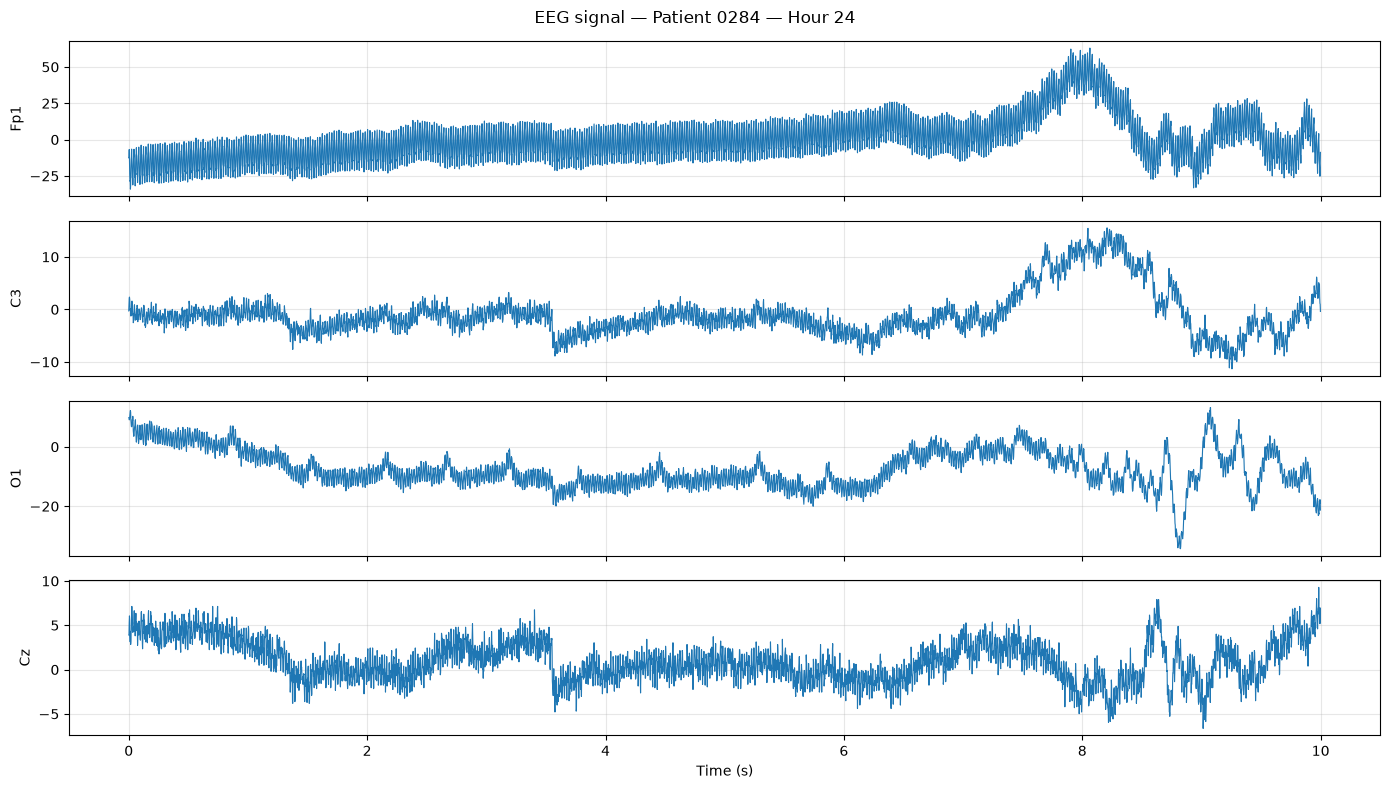

In [102]:
import matplotlib.pyplot as plt

channels_to_plot = [
    "Fp1",
    "C3",
    "O1",
    "Cz"
]

plot_seconds = 10

plot_samples = int(
    plot_seconds * sampling_frequency
)

fig, axes = plt.subplots(
    len(channels_to_plot),
    1,
    figsize=(14, 8),
    sharex=True
)

for ax, channel in zip(
    axes,
    channels_to_plot
):
    channel_index = COMMON_CHANNELS.index(
        channel
    )

    ax.plot(
        time[:plot_samples],
        eeg_window_physical[
            channel_index,
            :plot_samples
        ],
        linewidth=0.8
    )

    ax.set_ylabel(channel)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time (s)")

fig.suptitle(
    f"EEG signal — Patient {patient_id} — "
    f"Hour {int(sample_record['Hour'])}"
)

plt.tight_layout()
plt.show()

### Estandarización de la frecuencia de muestreo

Los registros EEG del conjunto de datos presentan diferentes frecuencias de muestreo. Para 
obtener una representación temporal homogénea, todas las señales se remuestrean a una 
frecuencia común de **200 Hz**.

La estandarización de la frecuencia de muestreo permite que cada ventana de 90 segundos tenga 
el mismo número de muestras independientemente de la frecuencia original del registro. Como 
resultado, cada observación quedará representada por una matriz de **19 canales × 18,000 
muestras**.

El remuestreo se realiza mediante un método polifásico, que incorpora el filtrado necesario 
durante el proceso de reducción de la frecuencia de muestreo.

In [103]:
from scipy.signal import resample_poly
from fractions import Fraction

TARGET_FS = 200

original_fs = int(
    sample_record["Sampling_frequency"]
)

ratio = Fraction(
    TARGET_FS,
    original_fs
)

up = ratio.numerator
down = ratio.denominator

print("Frecuencia original:", original_fs, "Hz")
print("Frecuencia objetivo:", TARGET_FS, "Hz")
print("Factor up:", up)
print("Factor down:", down)

eeg_window_resampled = resample_poly(
    eeg_window_physical,
    up=up,
    down=down,
    axis=1
)

print(
    "Shape antes:",
    eeg_window_physical.shape
)

print(
    "Shape después:",
    eeg_window_resampled.shape
)

Frecuencia original: 500 Hz
Frecuencia objetivo: 200 Hz
Factor up: 2
Factor down: 5
Shape antes: (19, 45000)
Shape después: (19, 18000)


In [104]:
expected_samples = int(
    90 * TARGET_FS
)

assert eeg_window_resampled.shape == (
    len(COMMON_CHANNELS),
    expected_samples
)

assert np.isfinite(
    eeg_window_resampled
).all()

print(
    "Duración después del resampling:",
    eeg_window_resampled.shape[1]
    / TARGET_FS,
    "segundos"
)

print(
    "Resampling realizado correctamente."
)

Duración después del resampling: 90.0 segundos
Resampling realizado correctamente.


### Filtrado de la señal EEG

Después de estandarizar la frecuencia de muestreo a 200 Hz, se aplica un proceso de filtrado 
para conservar el rango de frecuencias de interés y reducir componentes no deseados de la 
señal.

#### Filtro pasa banda: 0.5–70 Hz

Se utiliza un filtro pasa banda entre **0.5 y 70 Hz**. Estos valores no se eligieron de forma 
arbitraria: corresponden a los parámetros técnicos recomendados por la **American Clinical 
Neurophysiology Society (ACNS)** para el registro y análisis de EEG clínico, incluyendo 
monitorización prolongada (*Long-Term Monitoring*, LTM):

- **Filtro de baja frecuencia (LFF):** 0.5 Hz o menos. Este límite inferior elimina 
  componentes de deriva lenta (*drift*) y variaciones de línea base, sin afectar las 
  frecuencias fisiológicamente relevantes del EEG (bandas delta, theta, alfa, beta y gamma 
  baja).
- **Filtro de alta frecuencia (HFF):** 70 Hz o más. Este límite superior elimina ruido de 
  alta frecuencia y actividad muscular (artefactos EMG), conservando el contenido espectral 
  relevante para el análisis neurológico.

Estos mismos umbrales (0.5 Hz y 70 Hz) son los que definen el estándar utilizado en la 
práctica clínica rutinaria de EEG, y son consistentes con lo reportado en la literatura de 
preprocesamiento de señales EEG para tareas de aprendizaje automático, donde se emplean 
bandas similares (por ejemplo, 0.5–40 Hz o 0.5–70 Hz) para aislar los ritmos cerebrales 
dominantes y remover deriva y ruido de alta frecuencia.

#### Filtro notch: 50 Hz

Se aplica adicionalmente un filtro *notch* centrado en **50 Hz** para atenuar la interferencia 
asociada con la frecuencia de la red eléctrica. Este valor corresponde a la frecuencia 
estándar de la red eléctrica en los países donde se recolectó el dataset I-CARE (Países Bajos 
y Bélgica, con red a 50 Hz; en el caso de los centros en Estados Unidos, la red opera a 
60 Hz, por lo que este parámetro podría requerir ajuste según el sitio de origen del registro 
en una implementación más rigurosa).

> [!Nota]
> Es importante señalar que algunas guías clínicas (ACNS) desaconsejan activar el filtro 
> notch durante la *adquisición* del EEG, ya que puede distorsionar o atenuar actividad 
> epileptiforme relevante (picos, ondas agudas). Sin embargo, en el contexto de este 
> proyecto el filtro se aplica en la etapa de **preprocesamiento posterior a la adquisición**, 
> con el objetivo de limpiar la señal para tareas de análisis automatizado, no para 
> interpretación clínica visual directa — por lo que su uso aquí es apropiado.

#### Filtrado de fase cero

Los filtros se aplican utilizando **filtrado de fase cero** (`sosfiltfilt` para el pasa banda, 
`filtfilt` para el notch), evitando introducir desplazamientos temporales en la señal EEG. 
Esta técnica aplica el filtro dos veces (hacia adelante y hacia atrás en el tiempo), cancelando 
la distorsión de fase que introduciría un filtrado convencional de una sola pasada. Esto es 
especialmente importante en EEG, donde la posición temporal exacta de los eventos (picos, 
transitorios) debe conservarse con precisión para análisis posteriores.

**Referencias:**

- American Clinical Neurophysiology Society (ACNS). *Guideline on Minimum Technical Standards 
  for EEG Recording in Suspected Cerebral Death and for Long-Term Monitoring.* Disponible en: 
  https://acns.org/practice/guidelines

- Goldberger, A. L., et al. (2000). *PhysioBank, PhysioToolkit, and PhysioNet: Components of a 
  New Research Resource for Complex Physiologic Signals.* Circulation, 101(23), e215–e220.

In [105]:
from scipy.signal import butter, sosfiltfilt

LOWCUT = 0.5
HIGHCUT = 70.0
FILTER_ORDER = 4

sos = butter(
    FILTER_ORDER,
    [LOWCUT, HIGHCUT],
    btype="bandpass",
    fs=TARGET_FS,
    output="sos"
)

eeg_window_bandpass = sosfiltfilt(
    sos,
    eeg_window_resampled,
    axis=1
)

print(
    "Shape después del band-pass:",
    eeg_window_bandpass.shape
)

print(
    "Valores finitos:",
    np.isfinite(eeg_window_bandpass).all()
)

Shape después del band-pass: (19, 18000)
Valores finitos: True


In [106]:
from scipy.signal import iirnotch, filtfilt

NOTCH_FREQ = 50.0
NOTCH_Q = 30.0

b_notch, a_notch = iirnotch(
    NOTCH_FREQ,
    NOTCH_Q,
    fs=TARGET_FS
)

eeg_window_filtered = filtfilt(
    b_notch,
    a_notch,
    eeg_window_bandpass,
    axis=1
)

print(
    "Shape final:",
    eeg_window_filtered.shape
)

print(
    "Valores finitos:",
    np.isfinite(eeg_window_filtered).all()
)

Shape final: (19, 18000)
Valores finitos: True


In [107]:
assert eeg_window_filtered.shape == (
    len(COMMON_CHANNELS),
    90 * TARGET_FS
)

assert np.isfinite(
    eeg_window_filtered
).all()

print(
    "Filtrado EEG realizado correctamente."
)

Filtrado EEG realizado correctamente.


#### Validación visual del filtrado

Para verificar el efecto del preprocesamiento, se compara un mismo segmento de la señal antes 
y después de aplicar el filtro pasa banda y el filtro *notch*.

Adicionalmente, se analiza la densidad espectral de potencia para observar el efecto del 
filtrado en el dominio de la frecuencia. Esta validación permite comprobar que las 
transformaciones aplicadas producen el comportamiento esperado antes de extender el pipeline 
al conjunto completo de registros EEG.

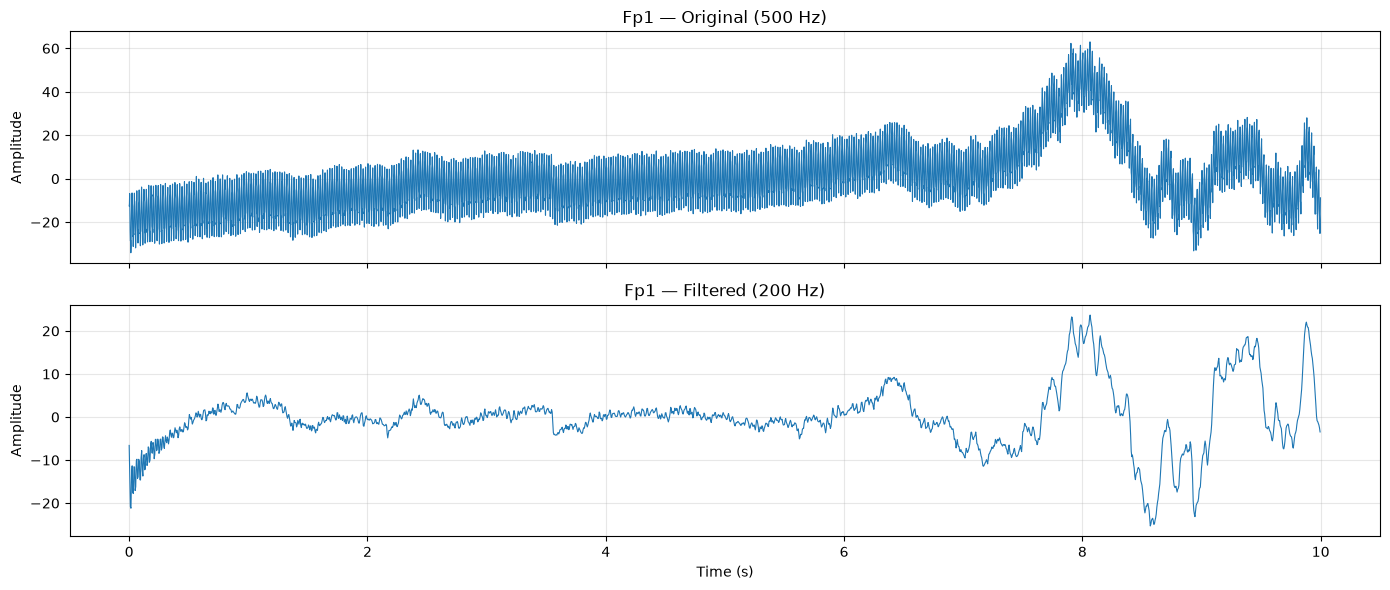

In [108]:
channel = "Fp1"
channel_index = COMMON_CHANNELS.index(channel)

plot_seconds = 10

original_plot_samples = int(
    plot_seconds * sampling_frequency
)

filtered_plot_samples = int(
    plot_seconds * TARGET_FS
)

time_original = (
    np.arange(original_plot_samples)
    / sampling_frequency
)

time_filtered = (
    np.arange(filtered_plot_samples)
    / TARGET_FS
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 6),
    sharex=True
)

axes[0].plot(
    time_original,
    eeg_window_physical[
        channel_index,
        :original_plot_samples
    ],
    linewidth=0.8
)

axes[0].set_title(
    f"{channel} — Original ({sampling_frequency:.0f} Hz)"
)

axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

axes[1].plot(
    time_filtered,
    eeg_window_filtered[
        channel_index,
        :filtered_plot_samples
    ],
    linewidth=0.8
)

axes[1].set_title(
    f"{channel} — Filtered ({TARGET_FS} Hz)"
)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretación de la densidad espectral de potencia (PSD)

Esta gráfica permite validar el efecto del filtrado **en el dominio de la frecuencia**, en 
lugar del dominio del tiempo. Mientras que una gráfica temporal muestra cómo cambia la 
amplitud de la señal instante a instante, la densidad espectral de potencia (*Power Spectral 
Density*, PSD) muestra **cuánta energía tiene la señal en cada frecuencia**.

##### Qué calcula `welch()`

El método de Welch estima la PSD dividiendo la señal en segmentos superpuestos (`nperseg`), 
calculando la transformada de Fourier de cada uno y promediando los resultados. Esto produce 
una estimación más estable y menos ruidosa que aplicar una única Transformada Rápida de 
Fourier (FFT) sobre toda la señal.

##### Cómo leer los ejes

- **Eje X (Frequency, Hz):** cada frecuencia presente en la señal, limitada aquí a 0–100 Hz 
  para poder observar con claridad la zona de interés.
- **Eje Y (Power Spectral Density, escala logarítmica):** la cantidad de energía o "potencia" 
  concentrada en cada frecuencia. Se usa `semilogy` (escala log en Y) porque la potencia de 
  una señal EEG puede variar en varios órdenes de magnitud entre frecuencias bajas y altas; 
  sin la escala logarítmica, las diferencias pequeñas en frecuencias altas serían invisibles 
  frente a los picos de baja frecuencia.

##### Qué comparar entre las dos curvas

- **Curva "Before filtering" (naranja/azul, según el estilo):** corresponde a la señal ya 
  remuestreada a 200 Hz, pero **antes** de aplicar el filtro pasa banda y el notch.
- **Curva "After filtering":** corresponde a la señal después de aplicar ambos filtros.

##### Qué se espera observar (validación del filtrado)

1. **Zona de baja frecuencia (cerca de 0 Hz):** la curva "After filtering" debería mostrar una 
   **caída notable de potencia** respecto a "Before filtering", reflejando la eliminación de 
   la deriva de línea base (*drift*) por el filtro pasa banda (corte inferior en 0.5 Hz).

2. **Línea vertical en 50 Hz:** marca la frecuencia de la red eléctrica. Si existía 
   interferencia de red en la señal original, se debería observar un **pico angosto en 
   "Before filtering"** justo en esa línea, que **desaparece o se atenúa fuertemente** en 
   "After filtering" gracias al filtro notch.

3. **Zona por encima de 70 Hz:** la curva "After filtering" debería mostrar una **atenuación 
   progresiva** de la potencia a partir de este punto, como efecto del corte superior del 
   filtro pasa banda.

4. **Zona intermedia (aprox. 0.5–70 Hz, excluyendo 50 Hz):** ambas curvas deberían verse 
   **muy similares** en esta región, ya que el filtrado no debe alterar significativamente 
   el contenido espectral fisiológicamente relevante del EEG (bandas delta, theta, alfa, 
   beta y gamma baja).

##### Qué indicaría un problema

- Si la curva "After filtering" **no muestra caída** en 50 Hz, el filtro notch no está 
  siendo efectivo (parámetros mal configurados o la frecuencia de red del sitio de origen 
  es distinta, por ejemplo 60 Hz en registros de Estados Unidos).
- Si las curvas son **idénticas en todo el rango**, el filtrado probablemente no se aplicó 
  correctamente sobre la señal graficada (por ejemplo, si accidentalmente se grafica dos 
  veces la misma variable).
- Si "After filtering" muestra **más potencia** que "Before filtering" en alguna zona, podría 
  indicar artefactos introducidos por el proceso de filtrado (poco común con filtrado de fase 
  cero, pero posible si el orden del filtro es demasiado alto).

En resumen, esta gráfica es la evidencia visual de que el preprocesamiento cumplió su 
propósito: conservar el contenido espectral relevante del EEG mientras se elimina la deriva 
de baja frecuencia, la interferencia de red eléctrica y el ruido de alta frecuencia.

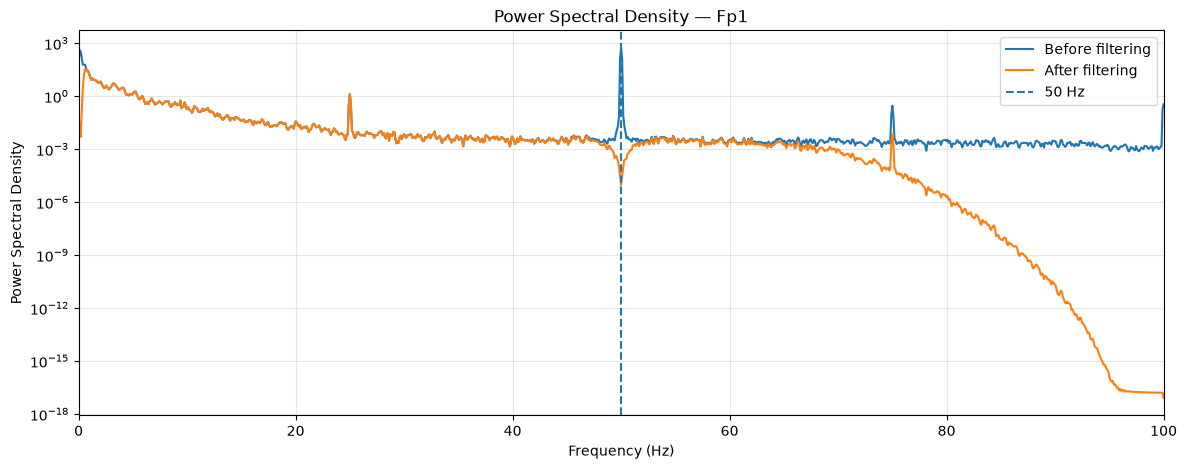

In [109]:
from scipy.signal import welch

frequencies_before, psd_before = welch(
    eeg_window_resampled[channel_index],
    fs=TARGET_FS,
    nperseg=2048
)

frequencies_after, psd_after = welch(
    eeg_window_filtered[channel_index],
    fs=TARGET_FS,
    nperseg=2048
)

plt.figure(
    figsize=(14, 5)
)

plt.semilogy(
    frequencies_before,
    psd_before,
    label="Before filtering"
)

plt.semilogy(
    frequencies_after,
    psd_after,
    label="After filtering"
)

plt.axvline(
    50,
    linestyle="--",
    label="50 Hz"
)

plt.xlim(0, 100)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(
    f"Power Spectral Density — {channel}"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Espectrograma: evolución tiempo-frecuencia

A diferencia del PSD (que promedia toda la ventana), el espectrograma muestra cómo cambia el 
contenido espectral **a lo largo de los 90 segundos**. Esto permite detectar eventos 
transitorios, cambios de estado o posibles artefactos localizados en el tiempo que un PSD 
promedio no revela.

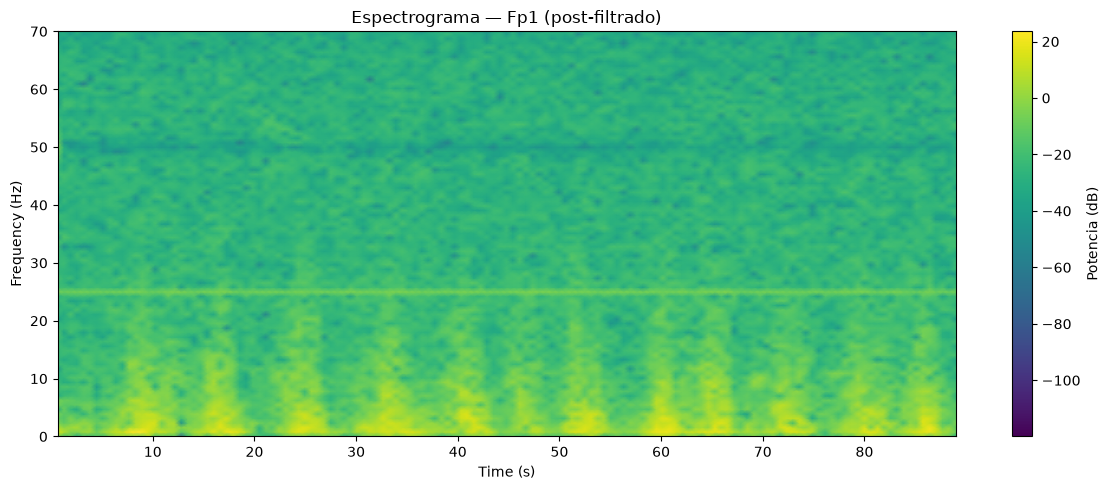

In [110]:
from scipy.signal import spectrogram

f_spec, t_spec, Sxx = spectrogram(
    eeg_window_filtered[channel_index],
    fs=TARGET_FS,
    nperseg=256,
    noverlap=128
)

fig, ax = plt.subplots(figsize=(12, 5))

pcm = ax.pcolormesh(
    t_spec,
    f_spec,
    10 * np.log10(Sxx + 1e-12),
    shading="gouraud",
    cmap="viridis"
)

ax.set_ylim(0, 70)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Espectrograma — {channel} (post-filtrado)")

fig.colorbar(pcm, ax=ax, label="Potencia (dB)")

plt.tight_layout()
plt.show()

### Validación del preprocesamiento

Antes de aplicar el pipeline de preprocesamiento al conjunto completo de registros EEG, se 
evalúa su comportamiento sobre el registro utilizado como prueba.

La validación se realiza tanto en el dominio temporal como en el dominio de la frecuencia. 
Primero, se compara visualmente un mismo canal antes y después del preprocesamiento para 
verificar que la señal conserve su estructura temporal general. Posteriormente, se analiza 
la densidad espectral de potencia para comprobar el efecto de los filtros sobre las 
componentes frecuenciales de la señal.

Esta etapa permite validar el pipeline sobre un único registro antes de automatizar su 
aplicación al conjunto completo de datos.

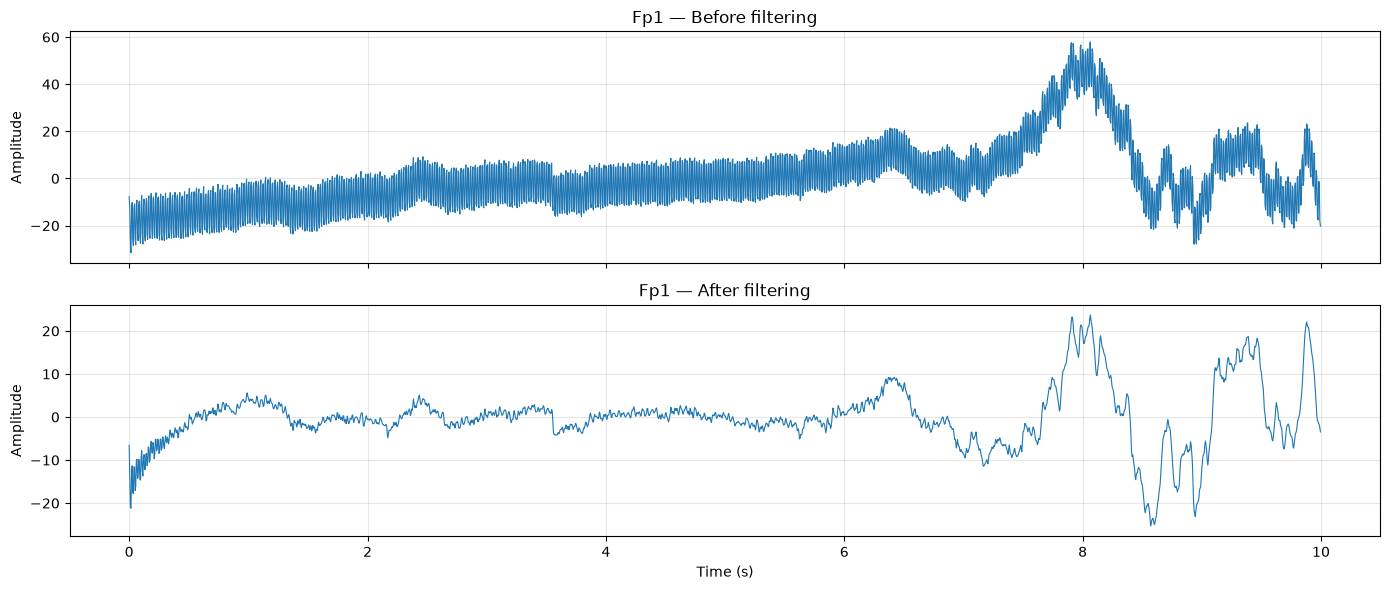

In [111]:
channel = "Fp1"

channel_index = COMMON_CHANNELS.index(
    channel
)

plot_seconds = 10

plot_samples = int(
    plot_seconds * TARGET_FS
)

time_plot = (
    np.arange(plot_samples)
    / TARGET_FS
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 6),
    sharex=True
)

# Señal antes del filtrado
axes[0].plot(
    time_plot,
    eeg_window_resampled[
        channel_index,
        :plot_samples
    ],
    linewidth=0.8
)

axes[0].set_title(
    f"{channel} — Before filtering"
)

axes[0].set_ylabel("Amplitude")
axes[0].grid(alpha=0.3)

# Señal después del filtrado
axes[1].plot(
    time_plot,
    eeg_window_filtered[
        channel_index,
        :plot_samples
    ],
    linewidth=0.8
)

axes[1].set_title(
    f"{channel} — After filtering"
)

axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Como resultado de este pipeline, cada registro procesado queda representado por una matriz 
homogénea de **19 × 18,000 muestras** (19 canales EEG, 90 segundos a 200 Hz).

### Estimación del volumen de descarga

Antes de iniciar el procesamiento masivo de los registros seleccionados, se estima el volumen 
de datos que sería necesario transferir desde PhysioNet.

Debido a que los archivos `.mat` contienen las señales EEG completas y pueden tener tamaños 
considerables, se consulta el tamaño de una muestra de los archivos seleccionados sin 
descargar su contenido. Esta información permite aproximar el almacenamiento y el tiempo de 
transferencia requeridos antes de ejecutar el pipeline sobre el conjunto completo.

In [112]:
import numpy as np
import pandas as pd
from tqdm import tqdm

N_SIZE_SAMPLE = 50

sample_indices = np.linspace(
    0,
    len(selected_eeg_records) - 1,
    N_SIZE_SAMPLE,
    dtype=int
)

size_sample = selected_eeg_records.iloc[
    sample_indices
].copy()

print(
    "Archivos utilizados para la estimación:",
    len(size_sample)
)

Archivos utilizados para la estimación: 50


In [113]:
file_sizes = []

for _, row in tqdm(
    size_sample.iterrows(),
    total=len(size_sample),
    desc="Consultando tamaños",
    unit="archivo"
):

    patient_id = row["Patient"]
    record_name = row["Record"]

    signal_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/"
        f"{record_name}.mat"
    )

    try:

        response = session.get(
            signal_url,
            stream=True,
            timeout=30
        )

        response.raise_for_status()

        content_length = response.headers.get(
            "Content-Length"
        )

        size_bytes = (
            int(content_length)
            if content_length is not None
            else np.nan
        )

        response.close()

    except Exception as error:

        size_bytes = np.nan

        print(
            f"\nError en {record_name}:",
            error
        )

    file_sizes.append(size_bytes)

size_sample["Size_bytes"] = file_sizes

size_sample["Size_MB"] = (
    size_sample["Size_bytes"]
    / 1024**2
)

Consultando tamaños: 100%|██████████| 50/50 [00:26<00:00,  1.88archivo/s]


In [114]:
display(
    size_sample["Size_MB"]
    .describe()
    .to_frame("Size_MB")
)

print(
    "Archivos con tamaño disponible:",
    size_sample["Size_MB"].notna().sum()
)

print(
    "Archivos sin tamaño disponible:",
    size_sample["Size_MB"].isna().sum()
)

,Size_MB
count,50.000000
mean,40.628247
std,13.334657
min,26.425842
25%,32.615685
50%,35.156273
75%,35.767113
max,70.312523


Archivos con tamaño disponible: 50
Archivos sin tamaño disponible: 0


In [115]:
mean_size_mb = (
    size_sample["Size_MB"].mean()
)

estimated_total_gb = (
    mean_size_mb
    * len(selected_eeg_records)
    / 1024
)

print(
    f"Tamaño medio estimado: "
    f"{mean_size_mb:.2f} MB"
)

print(
    f"Registros a procesar: "
    f"{len(selected_eeg_records):,}"
)

print(
    f"Descarga total estimada: "
    f"{estimated_total_gb:.2f} GB"
)

Tamaño medio estimado: 40.63 MB
Registros a procesar: 2,421
Descarga total estimada: 96.06 GB


In [116]:
speeds_mbps = [
    0.05,
    0.5,
    1,
    5,
    10,
    20
]

estimated_mb = (
    estimated_total_gb * 1024
)

time_estimates = []

for speed in speeds_mbps:

    hours = (
        estimated_mb
        / speed
        / 3600
    )

    time_estimates.append({
        "Download_speed_MB_s": speed,
        "Estimated_hours": hours,
        "Estimated_days": hours / 24
    })

time_estimates_df = pd.DataFrame(
    time_estimates
)

display(time_estimates_df)

,Download_speed_MB_s,Estimated_hours,Estimated_days
0,0.05,546.449917,22.768747
1,0.50,54.644992,2.276875
2,1.00,27.322496,1.138437
3,5.00,5.464499,0.227687
4,10.00,2.732250,0.113844
5,20.00,1.366125,0.056922


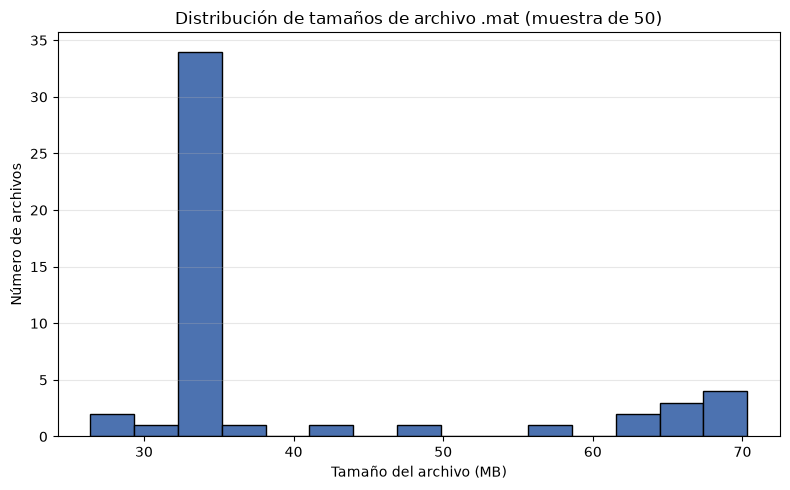

In [117]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(size_sample["Size_MB"].dropna(), bins=15, edgecolor="black", color="#4C72B0")

ax.set_xlabel("Tamaño del archivo (MB)")
ax.set_ylabel("Número de archivos")
ax.set_title("Distribución de tamaños de archivo .mat (muestra de 50)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

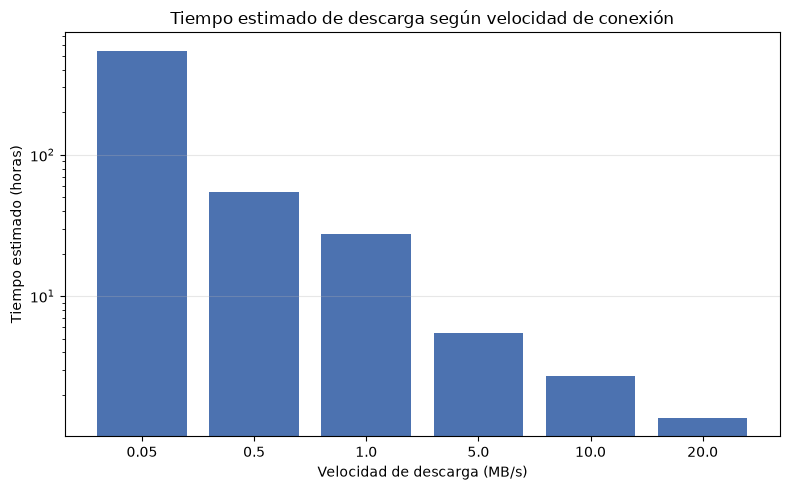

In [118]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    time_estimates_df["Download_speed_MB_s"].astype(str),
    time_estimates_df["Estimated_hours"],
    color="#4C72B0"
)

ax.set_xlabel("Velocidad de descarga (MB/s)")
ax.set_ylabel("Tiempo estimado (horas)")
ax.set_yscale("log")
ax.set_title("Tiempo estimado de descarga según velocidad de conexión")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusiones de la preparación de Records

La preparación de los registros fisiológicos permitió establecer un procedimiento reproducible 
para identificar, seleccionar y transformar las señales EEG relevantes del conjunto I-CARE.

Inicialmente se construyó un inventario global a partir de los archivos `RECORDS` de los 
pacientes. Sobre este inventario se evaluaron valores faltantes, duplicados, inconsistencias 
estructurales y valores atípicos. Estas verificaciones permitieron comprobar la integridad 
estructural de los identificadores y modalidades antes de iniciar la selección de las señales.

Posteriormente, el inventario se restringió a la modalidad EEG. A partir de los 36,123 
registros EEG identificados inicialmente, se aplicó una selección temporal centrada en las 
horas 24, 26, 28, 30 y 32, obteniendo 2,611 registros candidatos.

Los archivos `.hea` de estos registros fueron utilizados para evaluar su accesibilidad, 
duración, frecuencia de muestreo y configuración de canales. Se identificó un conjunto común 
de 19 canales EEG presente en todos los registros candidatos. Después de exigir una duración 
mínima de 90 segundos, se obtuvieron 2,590 registros elegibles.

Debido a que una misma combinación paciente-hora puede contener múltiples segmentos, la 
selección definitiva se realizó a este nivel. Se identificaron 2,421 combinaciones 
paciente-hora con al menos un registro elegible, seleccionando un único registro mediante un 
criterio determinista basado principalmente en su duración.

Para el preprocesamiento se definió una ventana central de 90 segundos por registro. Sobre un 
registro EEG real se validó el procedimiento completo de lectura de la señal, interpretación 
de los parámetros de calibración, selección y reorganización de los 19 canales comunes, 
conversión de valores digitales a unidades físicas y extracción de la ventana temporal.

La señal fue posteriormente remuestreada a 200 Hz y acondicionada mediante un filtro pasa 
banda de 0.5 a 70 Hz y un filtro notch de 50 Hz. De esta manera, el pipeline definido produce 
una representación homogénea de 19 canales por 18,000 muestras para cada ventana EEG de 
90 segundos.

Finalmente, se realizó una estimación del volumen requerido para materializar el conjunto 
completo de señales procesadas. Debido al tamaño considerable de los archivos `.mat`, en esta 
fase se validó la metodología de preprocesamiento sobre un registro individual, sin realizar 
la descarga y transformación masiva de todos los registros seleccionados.

En consecuencia, esta fase deja definido y validado el procedimiento que permite transformar 
los registros EEG originales de I-CARE en una representación estandarizada y reproducible, 
preparada para su posterior aplicación a gran escala y para las siguientes etapas de análisis.

---

## Transición: Entrega 03 → Entrega 04

Hasta este punto, el trabajo desarrollado sobre `Records` corresponde a la **Entrega 03 — Preparación de los datos**.

Durante esta etapa se construyó y depuró el inventario de registros fisiológicos disponibles en I-CARE, se identificaron los registros correspondientes a EEG y se aplicaron criterios de calidad y selección temporal para obtener un conjunto homogéneo de registros candidatos. Posteriormente, se verificó la disponibilidad y estructura de los archivos asociados y se definió un procedimiento reproducible para el preprocesamiento de las señales EEG.

Como resultado de esta etapa se dispone de un **marco de registros EEG elegibles**, organizado a nivel de paciente y ventana temporal, sobre el cual puede desarrollarse el análisis posterior sin necesidad de descargar y procesar inicialmente la totalidad de las señales disponibles.

A partir de este punto comienza la **Entrega 04 — Análisis de los datos**.

El objetivo de esta nueva etapa es pasar de la preparación técnica de los registros a su **caracterización estadística y selección de una muestra reducida de pacientes para la exploración de señales EEG**, de acuerdo con el objetivo específico 6 del proyecto:

> *Explorar de forma complementaria la disponibilidad y características básicas de las señales EEG en una muestra reducida de pacientes.*

La selección de esta muestra no se realizará de manera arbitraria. Primero se caracterizará el marco muestral disponible, considerando la cantidad de pacientes, la distribución de registros EEG y su cobertura en las ventanas temporales seleccionadas. A partir de esta información se definirá una estrategia de muestreo que permita obtener una muestra reducida y metodológicamente justificable.

Es importante distinguir entre **muestreo** e **inferencia estadística**. El muestreo corresponde al procedimiento mediante el cual se selecciona un subconjunto de pacientes a partir del marco muestral disponible. La estadística inferencial, cuando resulte aplicable, se utilizará posteriormente para cuantificar la incertidumbre y evaluar hasta qué punto los resultados observados en la muestra pueden generalizarse a la población objetivo definida para este análisis.

De esta manera, el flujo de trabajo para la componente EEG de la Entrega 04 será:

```mermaid
flowchart LR

    A["ENTREGA 03<br/>Preparación de los datos"] --> B["Marco de registros<br/>EEG elegibles"]

    B --> C["ENTREGA 04<br/>Análisis de los datos"]

    C --> D["1. Caracterización<br/>del marco muestral"]

    D --> E["Pacientes<br/>disponibles"]
    D --> F["Registros EEG<br/>por paciente"]
    D --> G["Cobertura<br/>temporal"]

    E --> H["2. Definición de la<br/>población objetivo"]
    F --> H
    G --> H

    H --> I["3. Diseño<br/>muestral"]

    I --> J["4. Muestra reducida<br/>de pacientes"]

    J --> K["5. Descarga y<br/>procesamiento EEG"]

    K --> L["6. Caracterización<br/>básica de señales"]

    L --> M["7. Análisis estadístico<br/>cuando sea aplicable"]

    M --> N["Resultados y<br/>conclusiones"]

    N --> O["Cumplimiento<br/>Objetivo específico 6"]
```

### A partir de aquí: Entrega 04

El análisis comenzará sobre el **marco muestral completo**, utilizando los metadatos disponibles en `Records` sin necesidad de descargar inicialmente todas las señales EEG.

Primero se determinará cuántos pacientes y registros cumplen los criterios definidos durante la preparación de datos y cómo se distribuye su disponibilidad entre las ventanas temporales consideradas. Esta caracterización permitirá establecer formalmente la **población objetivo y el marco muestral** del análisis EEG.

Posteriormente se definirá una estrategia de muestreo adecuada. La selección podrá considerar variables relevantes para la representatividad de la muestra, siempre que estas se encuentren disponibles y su utilización esté justificada por los objetivos del proyecto. Solo después de definir esta estrategia se seleccionarán los pacientes cuyas señales serán descargadas y procesadas.

Finalmente, sobre la muestra obtenida se realizará una exploración de las características básicas de las señales EEG y se evaluará qué técnicas estadísticas descriptivas o inferenciales resultan apropiadas. Las conclusiones de esta sección estarán orientadas a caracterizar la disponibilidad y estructura de los datos EEG y a establecer el cumplimiento del componente complementario definido en el objetivo específico 6.


# Análisis estadístico de la disponibilidad de EEG

## 1. Caracterización del marco muestral

Antes de definir una muestra reducida de pacientes, es necesario caracterizar el conjunto
completo de registros EEG que superó los criterios establecidos durante la preparación de
los datos.

El conjunto `selected_eeg_records` contiene una observación por combinación paciente-hora.
Por esta razón, el número total de registros no debe interpretarse como el número de
pacientes disponibles para el análisis.

En esta primera etapa se determinará:

- el número total de registros paciente-hora disponibles;
- el número de pacientes únicos representados;
- la disponibilidad de pacientes en cada ventana temporal;
- y el número de ventanas temporales disponibles para cada paciente.

Esta caracterización permitirá establecer el **marco muestral** a partir del cual se
diseñará posteriormente la muestra reducida de pacientes para el análisis de las señales EEG.

In [119]:
# ============================================================
# 1. DIMENSIONES GENERALES DEL MARCO MUESTRAL EEG
# ============================================================

n_records = len(selected_eeg_records)

n_patients = (
    selected_eeg_records["Patient"]
    .nunique()
)

n_hours = (
    selected_eeg_records["Hour"]
    .nunique()
)

available_hours = sorted(
    selected_eeg_records["Hour"]
    .unique()
)

print(
    f"Registros paciente-hora disponibles: "
    f"{n_records:,}"
)

print(
    f"Pacientes únicos representados: "
    f"{n_patients:,}"
)

print(
    f"Ventanas temporales disponibles: "
    f"{n_hours}"
)

print(
    f"Horas analizadas: "
    f"{available_hours}"
)

Registros paciente-hora disponibles: 2,421
Pacientes únicos representados: 530
Ventanas temporales disponibles: 5
Horas analizadas: [np.int64(24), np.int64(26), np.int64(28), np.int64(30), np.int64(32)]


In [120]:
available_hours = sorted(
    selected_eeg_records["Hour"]
    .astype(int)
    .unique()
)

### 1.1 Disponibilidad de EEG por ventana temporal

Una vez identificado que el marco muestral contiene **530 pacientes únicos**, se analiza
la disponibilidad de registros EEG en cada una de las cinco ventanas temporales
seleccionadas durante la preparación de los datos: 24, 26, 28, 30 y 32 horas.

Debido a que durante la preparación se seleccionó como máximo un registro válido por
combinación paciente-hora, el número de registros disponibles en cada ventana puede
interpretarse directamente como el número de pacientes con EEG elegible en ese momento.

Este análisis permite determinar si la cobertura temporal es aproximadamente homogénea
o si existen ventanas con una pérdida importante de pacientes. Esta información será
relevante posteriormente para definir la población objetivo y la estrategia de muestreo.

In [121]:
# ============================================================
# 2. DISPONIBILIDAD DE EEG POR VENTANA TEMPORAL
# ============================================================

availability_by_hour = (
    selected_eeg_records
    .groupby("Hour")["Patient"]
    .nunique()
    .sort_index()
    .rename("Patients")
    .reset_index()
)

availability_by_hour["Percentage"] = (
    availability_by_hour["Patients"] / n_patients * 100
)

availability_by_hour["Hour"] = (
    availability_by_hour["Hour"].astype(int)
)

availability_by_hour

,Hour,Patients,Percentage
0,24,476,89.811321
1,26,478,90.188679
2,28,487,91.886792
3,30,492,92.830189
4,32,488,92.075472


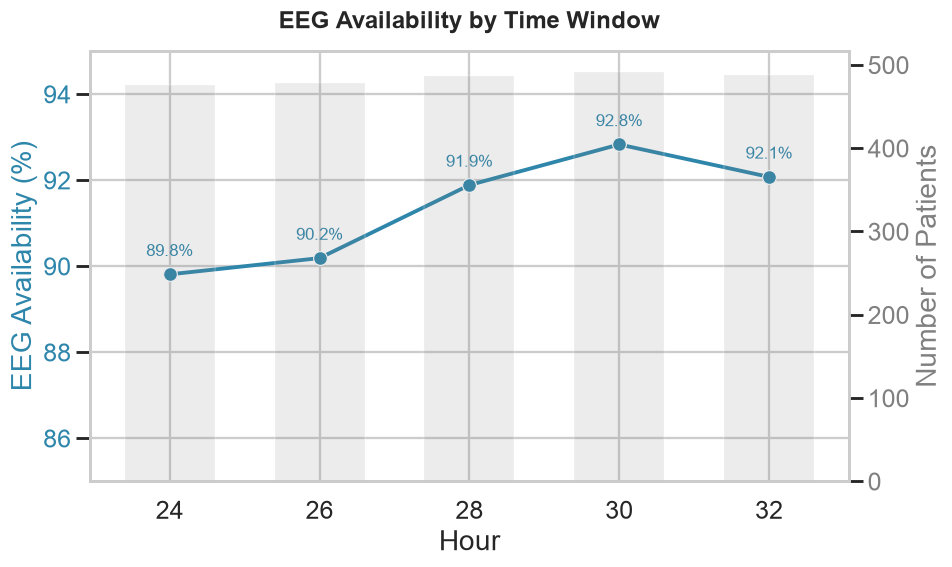

In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Your data (already computed in availability_by_hour)

sns.set_theme(style="whitegrid", context="talk")

fig, ax1 = plt.subplots(figsize=(9, 5.5), dpi=110)

# Line for percentage (primary y-axis)
sns.lineplot(
    data=availability_by_hour, x="Hour", y="Percentage",
    marker="o", markersize=9, linewidth=2.5, color="#2E86AB", ax=ax1
)
ax1.set_ylabel("EEG Availability (%)", color="#2E86AB")
ax1.tick_params(axis='y', labelcolor="#2E86AB")
ax1.set_xlabel("Hour")
ax1.set_ylim(85, 95)

# Annotate each point with its percentage
for _, row in availability_by_hour.iterrows():
    ax1.annotate(f'{row["Percentage"]:.1f}%',
                 (row["Hour"], row["Percentage"]),
                 textcoords="offset points", xytext=(0, 12),
                 ha='center', fontsize=11, color="#2E86AB")

# Secondary y-axis: raw patient counts as bars (context)
ax2 = ax1.twinx()
ax2.bar(availability_by_hour["Hour"], availability_by_hour["Patients"],
        width=1.2, alpha=0.15, color="gray")
ax2.set_ylabel("Number of Patients", color="gray")
ax2.tick_params(axis='y', labelcolor="gray")
ax2.grid(False)

plt.title("EEG Availability by Time Window", fontsize=16, weight="bold", pad=15)
fig.tight_layout()
plt.show()

#### Interpretación

El marco muestral presenta una cobertura EEG elevada en todas las ventanas temporales
analizadas. De los 530 pacientes únicos identificados, entre 476 y 492 cuentan con un
registro EEG elegible dependiendo de la hora considerada, lo que corresponde a una
cobertura entre aproximadamente 89.8 % y 92.8 %.

La disponibilidad se mantiene relativamente estable entre las 24 y 32 horas, sin
observarse una reducción progresiva importante en el número de pacientes representados.
La menor cobertura se presenta a las 24 horas (89.8 %), mientras que la mayor se observa
a las 30 horas (92.8 %).

Estos resultados indican que ninguna de las cinco ventanas temporales presenta, de manera
individual, una pérdida sustancial de pacientes. Sin embargo, esta caracterización no
permite determinar todavía si los mismos pacientes se encuentran disponibles en todas
las ventanas. Por esta razón, el siguiente análisis evaluará el número de ventanas
temporales disponibles para cada paciente.

In [123]:
# ============================================================
# 3. NÚMERO DE VENTANAS TEMPORALES DISPONIBLES POR PACIENTE
# ============================================================

windows_per_patient = (
    selected_eeg_records
    .groupby("Patient")["Hour"]
    .nunique()
    .rename("Available_windows")
)

window_distribution = (
    windows_per_patient
    .value_counts()
    .sort_index()
    .rename_axis("Available_windows")
    .reset_index(name="Patients")
)

window_distribution["Percentage"] = (
    window_distribution["Patients"] / n_patients * 100
)

window_distribution

,Available_windows,Patients,Percentage
0,1,12,2.264151
1,2,31,5.849057
2,3,32,6.037736
3,4,24,4.528302
4,5,431,81.320755


#### Interpretación de la cobertura longitudinal

La disponibilidad de EEG presenta una alta completitud temporal. De los 530 pacientes
que conforman el marco muestral, 431 (81.32 %) disponen de un registro EEG elegible en
las cinco ventanas temporales consideradas: 24, 26, 28, 30 y 32 horas.

Los 99 pacientes restantes presentan distintos niveles de información incompleta:
24 pacientes (4.53 %) tienen cuatro ventanas disponibles, 32 (6.04 %) tienen tres,
31 (5.85 %) tienen dos y 12 (2.26 %) cuentan únicamente con una ventana.

La distribución obtenida es consistente con los 2,421 registros paciente-hora
seleccionados durante la preparación de los datos:

$$
431(5)+24(4)+32(3)+31(2)+12(1)=2{,}421
$$

Estos resultados muestran que la mayor parte del marco muestral dispone de seguimiento
EEG completo en el intervalo analizado. Sin embargo, restringir inmediatamente el
análisis a los 431 pacientes con cinco ventanas podría introducir un criterio adicional
de selección. Antes de definir la muestra reducida se evaluará si la completitud temporal
se encuentra relacionada con características clínicas relevantes o con el centro
hospitalario.

## 2. Evaluación del marco muestral para el análisis EEG

La caracterización inicial identificó **530 pacientes con al menos un registro EEG
elegible** entre las 24 y 32 horas. De ellos, **431 pacientes (81.32 %)** presentan
cobertura completa en las cinco ventanas temporales consideradas.

Este resultado plantea una decisión metodológica importante:

> **¿Debe construirse la muestra reducida a partir de los 530 pacientes con algún EEG
> elegible o únicamente a partir de los 431 pacientes con cobertura temporal completa?**

Trabajar exclusivamente con los 431 pacientes completos presenta una ventaja evidente:
cada paciente tendría información disponible en las mismas cinco ventanas temporales,
facilitando posteriormente comparaciones entre las 24, 26, 28, 30 y 32 horas.

Sin embargo, exigir cobertura completa introduce un criterio adicional de selección.
Si la ausencia de alguna ventana EEG estuviera relacionada con el hospital de procedencia
o con el desenlace neurológico, restringir el marco muestral a los pacientes completos
podría modificar sistemáticamente la composición de la población analizada.

Por esta razón, antes de definir el marco muestral definitivo se compararán tres niveles
de la cohorte:

1. **Cohorte clínica completa:** 607 pacientes de I-CARE.
2. **Pacientes con EEG elegible:** 530 pacientes con al menos una ventana disponible.
3. **Pacientes con cobertura completa:** 431 pacientes con EEG disponible en las cinco
   ventanas temporales.

La comparación se realizará inicialmente sobre dos variables especialmente relevantes:
el **hospital de procedencia** y el **desenlace neurológico (`Outcome`)**.

El propósito de este análisis no es repetir las pruebas de asociación entre las variables
clínicas y el desenlace realizadas en el análisis clínico principal. En este caso la
pregunta es diferente:

> **¿El proceso de selección basado en la disponibilidad de EEG está generando un
> subconjunto de pacientes con una composición diferente de la cohorte original?**

La respuesta permitirá decidir de manera fundamentada si el diseño muestral posterior
debe utilizar los 530 pacientes con EEG elegible o puede restringirse a los 431 pacientes
con cobertura longitudinal completa.

In [124]:
# ============================================================
# 4. DEFINICIÓN DE LOS GRUPOS PARA EVALUAR EL MARCO MUESTRAL
# ============================================================

# Cohorte clínica completa
clinical_cohort = clinical_df.copy()

# Pacientes con al menos una ventana EEG elegible
eeg_eligible_patients = (
    selected_eeg_records["Patient"]
    .drop_duplicates()
)

# Pacientes con las cinco ventanas temporales disponibles
complete_eeg_patients = (
    windows_per_patient[
        windows_per_patient == 5
    ]
    .index
)

# Construimos indicadores a nivel de paciente
sampling_frame_df = clinical_cohort.copy()

sampling_frame_df["EEG_eligible"] = (
    sampling_frame_df["Patient"]
    .isin(eeg_eligible_patients)
)

sampling_frame_df["EEG_complete"] = (
    sampling_frame_df["Patient"]
    .isin(complete_eeg_patients)
)

print(
    "Cohorte clínica completa:",
    len(sampling_frame_df)
)

print(
    "Pacientes con EEG elegible:",
    sampling_frame_df["EEG_eligible"].sum()
)

print(
    "Pacientes con EEG completo (5/5):",
    sampling_frame_df["EEG_complete"].sum()
)

Cohorte clínica completa: 607
Pacientes con EEG elegible: 530
Pacientes con EEG completo (5/5): 431


In [125]:
# ============================================================
# 5. RETENCIÓN DE PACIENTES DURANTE LA SELECCIÓN EEG
# ============================================================

n_total = len(sampling_frame_df)
n_eligible = sampling_frame_df["EEG_eligible"].sum()
n_complete = sampling_frame_df["EEG_complete"].sum()

retention_summary = pd.DataFrame({
    "Group": [
        "Cohorte clínica completa",
        "EEG elegible",
        "EEG completo (5/5)"
    ],
    "Patients": [
        n_total,
        n_eligible,
        n_complete
    ]
})

retention_summary["Percentage_of_total"] = (
    retention_summary["Patients"]
    / n_total
    * 100
)

retention_summary

,Group,Patients,Percentage_of_total
0,Cohorte clínica completa,607,100.000000
1,EEG elegible,530,87.314662
2,EEG completo (5/5),431,71.004942


### 2.1 Distribución del desenlace neurológico

La primera comparación evalúa si la proporción de pacientes con desenlace neurológico
`Good` y `Poor` se mantiene aproximadamente estable a medida que se aplican los criterios
de disponibilidad EEG.

Si la distribución del desenlace cambia considerablemente al pasar de la cohorte completa
a los pacientes con EEG elegible o a los pacientes con cobertura completa, esto podría
indicar que el mecanismo de disponibilidad de EEG está seleccionando preferentemente
algún tipo de paciente.

Por el contrario, una distribución similar entre los tres grupos proporcionaría evidencia
descriptiva de que la selección basada en disponibilidad EEG no altera de forma importante
la composición de la cohorte respecto al desenlace neurológico.

In [126]:
# ============================================================
# 6. DISTRIBUCIÓN DE OUTCOME EN LOS TRES GRUPOS
# ============================================================

groups = {
    "Cohorte completa":
        sampling_frame_df,

    "EEG elegible":
        sampling_frame_df[
            sampling_frame_df["EEG_eligible"]
        ],

    "EEG completo (5/5)":
        sampling_frame_df[
            sampling_frame_df["EEG_complete"]
        ]
}

outcome_tables = []

for group_name, group_df in groups.items():

    counts = (
        group_df["Outcome"]
        .value_counts(dropna=False)
    )

    percentages = (
        group_df["Outcome"]
        .value_counts(
            normalize=True,
            dropna=False
        )
        * 100
    )

    for outcome in counts.index:

        outcome_tables.append({
            "Group": group_name,
            "Outcome": outcome,
            "Patients": counts[outcome],
            "Percentage": percentages[outcome]
        })

outcome_comparison = pd.DataFrame(
    outcome_tables
)

outcome_comparison

,Group,Outcome,Patients,Percentage
0,Cohorte completa,Poor,382,62.932455
1,Cohorte completa,Good,225,37.067545
2,EEG elegible,Poor,322,60.754717
3,EEG elegible,Good,208,39.245283
4,EEG completo (5/5),Poor,256,59.396752
5,EEG completo (5/5),Good,175,40.603248


#### Interpretación

La distribución del desenlace neurológico se mantiene relativamente estable durante
las etapas de selección basadas en disponibilidad EEG.

En la cohorte clínica completa, el 37.07 % de los pacientes presenta un desenlace
`Good` y el 62.93 % un desenlace `Poor`. Entre los pacientes con al menos una ventana
EEG elegible, estas proporciones corresponden a 39.25 % y 60.75 %, respectivamente.
Finalmente, entre los pacientes con cobertura completa en las cinco ventanas, el
40.60 % presenta desenlace `Good` y el 59.40 % desenlace `Poor`.

Se observa, por tanto, un incremento gradual de aproximadamente 3.54 puntos porcentuales
en la representación de pacientes con desenlace `Good` entre la cohorte completa y el
grupo con cobertura EEG completa.

Descriptivamente, la magnitud de este cambio es moderada y no sugiere una transformación
drástica de la composición de la cohorte. Sin embargo, este análisis por sí solo no
permite establecer si la disponibilidad de EEG es independiente del desenlace
neurológico.

Además, todavía debe evaluarse la distribución por hospital, dado que la disponibilidad
de registros EEG podría depender de diferencias entre centros. Por esta razón, la
decisión entre utilizar los 530 pacientes con EEG elegible o restringir el marco
muestral a los 431 pacientes con cobertura completa se mantiene abierta hasta evaluar
la representación de los diferentes hospitales.

### 2.2 Distribución de pacientes por hospital

El conjunto I-CARE tiene naturaleza multicéntrica, por lo que la disponibilidad de EEG
puede no ser homogénea entre hospitales. Diferencias en protocolos de monitorización,
duración de los registros o disponibilidad de los archivos podrían provocar que algunos
centros tengan mayor representación dentro del marco EEG que otros.

Esto conduce a una segunda pregunta:

> **¿La selección de pacientes con EEG elegible y, especialmente, con cobertura completa
> mantiene aproximadamente la representación de los hospitales observada en la cohorte
> clínica original?**

Para responderla se comparará la distribución porcentual de pacientes por hospital en
la cohorte completa, en el grupo con EEG elegible y en el grupo con cobertura completa.

Una reducción desproporcionada de determinados hospitales sería relevante para el diseño
muestral posterior, ya que sugeriría que una muestra aleatoria simple podría reproducir
o incluso amplificar el desequilibrio entre centros.

In [127]:
# ============================================================
# 7. DISTRIBUCIÓN POR HOSPITAL EN LOS TRES GRUPOS
# ============================================================

hospital_comparison = pd.DataFrame()

for group_name, group_df in groups.items():

    percentages = (
        group_df["Hospital"]
        .value_counts(normalize=True)
        .mul(100)
    )

    hospital_comparison[group_name] = percentages

# Hospitales ausentes en algún grupo aparecen inicialmente como NaN
hospital_comparison = (
    hospital_comparison
    .fillna(0)
    .sort_index()
)

hospital_comparison.round(2)

,Cohorte completa,EEG elegible,EEG completo (5/5)
Hospital,,,
A,43.00,44.53,48.72
B,19.77,18.11,18.56
D,13.67,13.58,12.06
E,12.19,11.51,7.66
F,11.37,12.26,12.99


In [128]:
# Cambio en puntos porcentuales respecto a la cohorte completa

hospital_comparison["Δ EEG elegible"] = (
    hospital_comparison["EEG elegible"]
    - hospital_comparison["Cohorte completa"]
)

hospital_comparison["Δ EEG completo"] = (
    hospital_comparison["EEG completo (5/5)"]
    - hospital_comparison["Cohorte completa"]
)

hospital_comparison.round(2)

,Cohorte completa,EEG elegible,EEG completo (5/5),Δ EEG elegible,Δ EEG completo
Hospital,,,,,
A,43.00,44.53,48.72,1.53,5.73
B,19.77,18.11,18.56,-1.66,-1.21
D,13.67,13.58,12.06,-0.09,-1.61
E,12.19,11.51,7.66,-0.68,-4.53
F,11.37,12.26,12.99,0.90,1.63


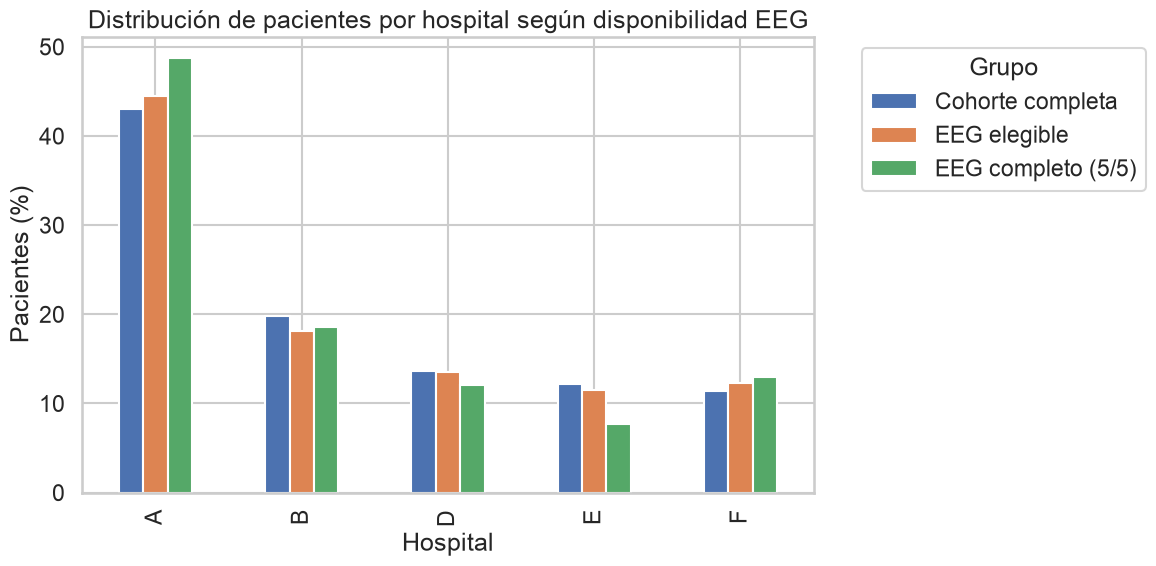

In [129]:
# ============================================================
# 8. VISUALIZACIÓN DE LA REPRESENTACIÓN POR HOSPITAL
# ============================================================

plot_data = (
    hospital_comparison[
        [
            "Cohorte completa",
            "EEG elegible",
            "EEG completo (5/5)"
        ]
    ]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Distribución de pacientes por hospital según disponibilidad EEG"
)

ax.set_xlabel("Hospital")
ax.set_ylabel("Pacientes (%)")

ax.legend(
    title="Grupo",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### Interpretación de la distribución por hospital

La disponibilidad de EEG no afecta de la misma manera la representación de todos los
centros hospitalarios.

Al comparar la cohorte clínica completa con los pacientes que presentan al menos una
ventana EEG elegible, las diferencias son relativamente pequeñas. El mayor cambio
corresponde al hospital B, con una reducción de aproximadamente 1.66 puntos porcentuales,
mientras que los demás centros presentan variaciones inferiores a aproximadamente
1.6 puntos porcentuales.

Sin embargo, al exigir cobertura completa en las cinco ventanas temporales aparecen
diferencias más pronunciadas. El hospital A incrementa su representación desde 43.00 %
en la cohorte completa hasta 48.72 % en el grupo con cobertura completa, una diferencia
de +5.73 puntos porcentuales. En contraste, el hospital E disminuye desde 12.19 % hasta
7.66 %, correspondiente a una diferencia de -4.53 puntos porcentuales.

Por tanto, aunque la selección inicial de pacientes con algún EEG elegible conserva
razonablemente la distribución multicéntrica original, el requisito de cobertura completa
parece modificar en mayor medida la composición por hospital.

Este resultado conduce a una nueva pregunta:

> **¿Las diferencias observadas corresponden únicamente a variaciones descriptivas o
> existe evidencia estadística de una asociación entre el hospital y la disponibilidad
> de cobertura EEG completa?**

Responder esta pregunta es relevante antes de restringir el marco muestral a los
431 pacientes con cinco ventanas, ya que una asociación entre centro hospitalario y
completitud EEG indicaría que dicho criterio de selección no afecta de manera uniforme
a todos los hospitales.

### 2.3 Asociación entre hospital y cobertura EEG completa

La comparación descriptiva anterior sugiere que la probabilidad de conservar las cinco
ventanas EEG podría variar entre hospitales. Para evaluar formalmente esta posibilidad
se plantea una prueba de independencia $\chi^2$ entre el hospital de procedencia y la
disponibilidad de cobertura EEG completa.

Las hipótesis son:

$$
H_0:\text{ el hospital y la disponibilidad de EEG completo son independientes.}
$$

$$
H_1:\text{ existe asociación entre el hospital y la disponibilidad de EEG completo.}
$$


La unidad de análisis es el paciente. Cada uno de los 607 pacientes de la cohorte se
clasifica según su hospital y según presente o no las cinco ventanas EEG requeridas.

Adicionalmente al valor $p$, se calculará el **V de Cramér** como medida del tamaño del
efecto. Esto permitirá diferenciar entre la existencia de evidencia estadística de
asociación y la magnitud práctica de dicha asociación.

In [130]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

# ============================================================
# 9. HOSPITAL vs COBERTURA EEG COMPLETA
# ============================================================

hospital_complete_table = pd.crosstab(
    sampling_frame_df["Hospital"],
    sampling_frame_df["EEG_complete"]
)

# Nombres más interpretables
hospital_complete_table.columns = [
    "EEG incompleto",
    "EEG completo (5/5)"
]

hospital_complete_table

,EEG incompleto,EEG completo (5/5)
Hospital,,
A,51,210
B,40,80
D,31,52
E,41,33
F,13,56


In [131]:
# ============================================================
# 10. PRUEBA CHI-CUADRADO DE INDEPENDENCIA
# ============================================================

chi2, p_value, dof, expected = chi2_contingency(
    hospital_complete_table
)

print(f"Chi-cuadrado : {chi2:.4f}")
print(f"Grados de libertad: {dof}")
print(f"p-value      : {p_value:.6f}")

Chi-cuadrado : 43.7701
Grados de libertad: 4
p-value      : 0.000000


In [132]:
# ============================================================
# 11. TAMAÑO DEL EFECTO: V DE CRAMÉR
# ============================================================

n = hospital_complete_table.to_numpy().sum()

r, k = hospital_complete_table.shape

cramers_v = np.sqrt(
    chi2 /
    (n * min(r - 1, k - 1))
)

print(f"V de Cramér: {cramers_v:.4f}")

V de Cramér: 0.2685


In [133]:
expected_df = pd.DataFrame(
    expected,
    index=hospital_complete_table.index,
    columns=hospital_complete_table.columns
)

print(
    "Frecuencia esperada mínima:",
    expected_df.min().min()
)

expected_df.round(2)

Frecuencia esperada mínima: 20.00658978583196


,EEG incompleto,EEG completo (5/5)
Hospital,,
A,75.68,185.32
B,34.79,85.21
D,24.07,58.93
E,21.46,52.54
F,20.01,48.99


#### Resultado de la prueba de independencia

La prueba $\chi^2$ mostró evidencia estadísticamente significativa de asociación entre
el hospital de procedencia y la disponibilidad de cobertura EEG completa:

\[
\chi^2(4)=43.77,\qquad p<0.001.
\]

Por tanto, se rechaza la hipótesis nula de independencia entre ambas variables. La
probabilidad de disponer de las cinco ventanas EEG no es homogénea entre los hospitales
incluidos en la cohorte.

Las condiciones de aplicación de la prueba fueron adecuadas. La menor frecuencia
esperada fue aproximadamente 20.01, superior al umbral convencional de 5.

El tamaño del efecto, cuantificado mediante el V de Cramér, fue:

\[
V=0.2685.
\]

Por tanto, además de la evidencia estadística de asociación, se observa una diferencia
no despreciable en la composición del grupo con cobertura EEG completa.

La comparación entre frecuencias observadas y esperadas permite identificar parte de
esta diferencia. En el hospital A se observaron 210 pacientes con cobertura completa,
frente a aproximadamente 185 esperados bajo independencia. En contraste, en el hospital
E se observaron únicamente 33 pacientes completos, frente a aproximadamente 53 esperados.

### ¿Debemos entonces utilizar únicamente los 431 pacientes con cobertura completa?

Los resultados anteriores indican que **no resulta conveniente definir automáticamente
los 431 pacientes con cinco ventanas como el marco muestral principal**. Aunque este
grupo facilitaría un análisis longitudinal balanceado, el criterio de completitud está
asociado con el hospital y modifica la composición multicéntrica de la cohorte.

En consecuencia, se conservarán como marco muestral principal los **530 pacientes con
al menos un EEG elegible**. La cobertura temporal se considerará posteriormente como
una característica del paciente y no como un criterio obligatorio de inclusión.

Esta decisión permite conservar una mayor proporción de la cohorte original y evita
introducir innecesariamente un criterio de selección que favorece la representación de
algunos hospitales y reduce la de otros.

Para la construcción de la muestra reducida de pacientes se deberá considerar la
estructura multicéntrica del conjunto de datos, evitando una selección puramente
arbitraria y evaluando una estrategia de muestreo que preserve adecuadamente la
representación de los hospitales y del desenlace neurológico.

### 2.4 Asociación entre desenlace neurológico y cobertura EEG completa

Aunque la distribución del desenlace neurológico presentó variaciones menores que las
observadas entre hospitales, se identificó un incremento progresivo en la proporción de
pacientes con desenlace `Good` a medida que se aplicaron criterios más restrictivos de
disponibilidad EEG.

Para determinar si esta diferencia proporciona evidencia de una asociación entre el
desenlace y la disponibilidad de las cinco ventanas temporales, se plantea una segunda
prueba $\chi^2$ de independencia.

Las hipótesis son:

$$
H_0:\text{ el desenlace neurológico y la cobertura EEG completa son independientes.}
$$

$$
H_1:\text{ existe asociación entre el desenlace neurológico y la cobertura EEG completa.}
$$

Al igual que en el análisis por hospital, se reportará el valor $p$ junto con el
V de Cramér como medida del tamaño del efecto.

In [134]:
# ============================================================
# 12. OUTCOME vs COBERTURA EEG COMPLETA
# ============================================================

outcome_complete_table = pd.crosstab(
    sampling_frame_df["Outcome"],
    sampling_frame_df["EEG_complete"]
)

outcome_complete_table.columns = [
    "EEG incompleto",
    "EEG completo (5/5)"
]

outcome_complete_table

,EEG incompleto,EEG completo (5/5)
Outcome,,
Good,50,175
Poor,126,256


In [135]:
# ============================================================
# 13. CHI-CUADRADO Y V DE CRAMÉR
# ============================================================

chi2_outcome, p_outcome, dof_outcome, expected_outcome = (
    chi2_contingency(outcome_complete_table)
)

n_outcome = outcome_complete_table.to_numpy().sum()
r_outcome, k_outcome = outcome_complete_table.shape

cramers_v_outcome = np.sqrt(
    chi2_outcome /
    (
        n_outcome *
        min(r_outcome - 1, k_outcome - 1)
    )
)

print(f"Chi-cuadrado       : {chi2_outcome:.4f}")
print(f"Grados de libertad: {dof_outcome}")
print(f"p-value            : {p_outcome:.6f}")
print(f"V de Cramér        : {cramers_v_outcome:.4f}")
print(
    "Frecuencia esperada mínima:",
    expected_outcome.min()
)

Chi-cuadrado       : 7.4518
Grados de libertad: 1
p-value            : 0.006337
V de Cramér        : 0.1108
Frecuencia esperada mínima: 65.23887973640856


#### Resultado de la asociación entre desenlace y cobertura EEG completa

La prueba de independencia mostró evidencia estadísticamente significativa de asociación
entre el desenlace neurológico y la disponibilidad de cobertura EEG completa:

$$
\chi^2(1)=7.45,\qquad p=0.0063.
$$

Por tanto, se rechaza la hipótesis nula de independencia entre ambas variables.

Las condiciones de aplicación de la prueba fueron adecuadas. La menor frecuencia
esperada fue aproximadamente 65.24, por lo que no se identificaron problemas asociados
con frecuencias esperadas pequeñas.

El tamaño del efecto, medido mediante el V de Cramér, fue:

$$
V=0.1108.
$$

Aunque existe evidencia estadística de asociación, la magnitud observada es menor que
la encontrada previamente entre hospital y cobertura EEG completa
($V=0.2685$).

La tabla de contingencia permite interpretar la dirección de esta diferencia. Entre los
225 pacientes con desenlace `Good`, 175 presentan cobertura EEG completa
(77.78 %), mientras que entre los 382 pacientes con desenlace `Poor`, 256 presentan
cobertura completa (67.02 %).

Por tanto, los pacientes con desenlace `Good` presentan una mayor proporción de
cobertura temporal completa que los pacientes con desenlace `Poor`.

Este resultado es consistente con el cambio descriptivo observado previamente, donde
la representación de pacientes `Good` aumentó desde 37.07 % en la cohorte completa
hasta 40.60 % entre los pacientes con las cinco ventanas disponibles.

En consecuencia, restringir el marco muestral únicamente a pacientes con cobertura
5/5 no solo modificaría la representación de los hospitales, sino que también
incrementaría ligeramente la representación relativa de pacientes con desenlace
neurológico favorable.

### 2.5 Definición del marco muestral para la exploración EEG

Al inicio de esta sección se planteó la siguiente pregunta:

> **¿Debe construirse la muestra reducida utilizando los 530 pacientes con algún EEG
> elegible o únicamente los 431 pacientes con cobertura completa en las cinco ventanas?**

Los análisis realizados permiten responder esta pregunta.

Aunque utilizar exclusivamente pacientes con cinco ventanas proporcionaría un conjunto
temporalmente balanceado, la completitud EEG no es independiente de las características
de la cohorte. Se encontró evidencia de asociación tanto con el hospital de procedencia
como con el desenlace neurológico:

$$
\begin{aligned}
\text{Hospital:}\quad
&\chi^2(4)=43.77,\quad p<0.001,\quad V=0.2685,\\
\text{Outcome:}\quad
&\chi^2(1)=7.45,\quad p=0.0063,\quad V=0.1108.
\end{aligned}
$$

Además, la restricción a cobertura completa incrementaría la representación del hospital
A y reduciría particularmente la del hospital E, al tiempo que aumentaría ligeramente
la proporción de pacientes con desenlace `Good`.

Por estas razones, se define como **marco muestral principal** el conjunto de:

$$
\boxed{530\text{ pacientes con al menos una ventana EEG elegible}}
$$

y no únicamente los 431 pacientes con cobertura temporal completa.

La unidad de muestreo será el **paciente**, no el registro EEG individual. Esta decisión
evita que pacientes con mayor número de ventanas disponibles tengan una probabilidad
mayor de ser seleccionados.

Dado que la disponibilidad EEG presenta diferencias relacionadas con el hospital y el
desenlace, la muestra reducida deberá diseñarse de forma que conserve explícitamente
estas características de la población elegible. Por tanto, antes de seleccionar los
registros que serán descargados y procesados, se evaluará la distribución conjunta de
**Hospital × Outcome** dentro de los 530 pacientes que conforman el marco muestral.

## 3. Diseño de la muestra reducida de pacientes

Una vez definido el marco muestral de 530 pacientes, el siguiente objetivo consiste en
diseñar una muestra reducida que permita explorar las señales EEG sin requerir la
descarga y procesamiento de la totalidad de los registros disponibles.

Los análisis anteriores mostraron que tanto el hospital como el desenlace neurológico
son variables relevantes para comprender la composición del marco EEG. Por esta razón,
antes de realizar la selección se evaluará su distribución conjunta.

Se consideran inicialmente los estratos definidos por:

$$
\text{Hospital}\times\text{Outcome}.
$$

Con cinco hospitales y dos categorías de desenlace (`Good` y `Poor`) pueden existir
hasta diez estratos.

La primera pregunta será:

> **¿Todos los estratos Hospital × Outcome contienen suficientes pacientes para ser
> representados en una muestra reducida?**

Esta evaluación debe realizarse antes de decidir el tamaño y la asignación de la muestra,
ya que la presencia de estratos pequeños podría hacer inconveniente una estratificación
completa o requerir una estrategia de asignación diferente.

In [136]:
# ============================================================
# 14. DISTRIBUCIÓN HOSPITAL × OUTCOME EN EL MARCO MUESTRAL
# ============================================================

eeg_sampling_frame = (
    sampling_frame_df[
        sampling_frame_df["EEG_eligible"]
    ]
    .copy()
)

hospital_outcome_counts = pd.crosstab(
    eeg_sampling_frame["Hospital"],
    eeg_sampling_frame["Outcome"],
    margins=True
)

hospital_outcome_counts

Outcome,Good,Poor,All
Hospital,,,
A,118,118,236
B,26,70,96
D,25,47,72
E,12,49,61
F,27,38,65
All,208,322,530


In [137]:
# ============================================================
# 15. PORCENTAJE DEL MARCO MUESTRAL EN CADA ESTRATO
# ============================================================

hospital_outcome_percentages = pd.crosstab(
    eeg_sampling_frame["Hospital"],
    eeg_sampling_frame["Outcome"],
    normalize="all"
) * 100

hospital_outcome_percentages.round(2)

Outcome,Good,Poor
Hospital,,
A,22.26,22.26
B,4.91,13.21
D,4.72,8.87
E,2.26,9.25
F,5.09,7.17


### 3.1 Evaluación de los estratos Hospital × Outcome

El marco muestral de 530 pacientes contiene observaciones en las diez combinaciones
posibles entre los cinco hospitales y las dos categorías de desenlace neurológico.

La distribución, sin embargo, no es uniforme. El hospital A concentra 236 pacientes
(44.53 % del marco muestral) y presenta una distribución equilibrada entre `Good`
y `Poor`, con 118 pacientes en cada categoría.

En los demás hospitales predomina el desenlace `Poor`. Particularmente, el hospital E
presenta únicamente 12 pacientes con desenlace `Good`, equivalentes al 2.26 % del marco
muestral total, mientras que otros estratos alcanzan tamaños considerablemente mayores.

Por tanto, una estratificación conjunta por `Hospital × Outcome` es técnicamente posible,
ya que ninguno de los diez estratos se encuentra vacío. Sin embargo, las diferencias
en sus tamaños deben considerarse al definir la asignación de la muestra.

Esto plantea una nueva decisión metodológica:

> **¿La muestra debe reproducir exactamente las proporciones observadas en los 530
> pacientes o debe garantizar una representación mínima de los estratos menos
> frecuentes?**

Una asignación estrictamente proporcional conservaría la estructura del marco muestral,
pero podría seleccionar muy pocos pacientes de algunos estratos pequeños. En contraste,
una asignación uniforme aumentaría la representación de los estratos minoritarios, pero
dejaría de reproducir la distribución original de la población elegible.

Por esta razón, el tamaño total de la muestra y el método de asignación deben definirse
conjuntamente antes de realizar la selección aleatoria de pacientes.

### 3.2 Definición del propósito de la muestra reducida

El cálculo del tamaño de una muestra depende del parámetro que se desea estimar y de la
precisión requerida. En este caso, la muestra EEG reducida no se utilizará para estimar
la proporción de desenlaces clínicos de la cohorte, puesto que dicha información ya se
encuentra disponible para los 530 pacientes del marco muestral.

El propósito de la muestra es diferente: permitir la descarga, procesamiento y
caracterización exploratoria de señales EEG manteniendo diversidad respecto al hospital
y al desenlace neurológico.

Por tanto, el tamaño de muestra no debe justificarse aplicando de manera automática una
fórmula para estimación de proporciones. En su lugar, debe buscar un equilibrio entre:

- la representación de los diez estratos `Hospital × Outcome`;
- la disponibilidad temporal de EEG de los pacientes seleccionados;
- la cantidad de señales que deberán descargarse y procesarse;
- y el carácter exploratorio del análisis EEG propuesto.

La selección continuará realizándose a nivel de **paciente**, evitando utilizar los
2,421 registros paciente-hora como unidades independientes de muestreo.

### 3.3 Cobertura temporal dentro de los estratos

Además del hospital y el desenlace, cada paciente presenta un número diferente de
ventanas EEG disponibles entre las 24 y 32 horas.

Aunque la cobertura completa no se utilizará como criterio obligatorio de inclusión,
resulta necesario conocer su distribución dentro de los estratos antes de seleccionar
la muestra.

Esta evaluación permitirá determinar si algunos estratos presentan simultáneamente
pocos pacientes y baja disponibilidad temporal, situación que podría limitar la
comparación posterior de señales entre diferentes momentos.

In [138]:
# ============================================================
# 16. INCORPORAR COBERTURA TEMPORAL AL MARCO MUESTRAL
# ============================================================

eeg_sampling_frame = (
    eeg_sampling_frame
    .merge(
        windows_per_patient.rename("Available_windows"),
        left_on="Patient",
        right_index=True,
        how="left"
    )
)

eeg_sampling_frame[
    [
        "Patient",
        "Hospital",
        "Outcome",
        "Available_windows"
    ]
].head()

,Patient,Hospital,Outcome,Available_windows
0,0284,A,Good,4
1,0286,F,Good,5
3,0299,A,Good,5
4,0303,D,Good,5
5,0306,E,Good,5


In [139]:
print(
    "Pacientes:",
    len(eeg_sampling_frame)
)

print(
    "Cobertura faltante:",
    eeg_sampling_frame["Available_windows"].isna().sum()
)

print(
    "Rango de ventanas:",
    eeg_sampling_frame["Available_windows"].min(),
    "-",
    eeg_sampling_frame["Available_windows"].max()
)

Pacientes: 530
Cobertura faltante: 0
Rango de ventanas: 1 - 5


In [140]:
# ============================================================
# 17. COBERTURA TEMPORAL POR HOSPITAL × OUTCOME
# ============================================================

coverage_by_stratum = (
    eeg_sampling_frame
    .groupby(
        ["Hospital", "Outcome"]
    )
    .agg(
        Patients=("Patient", "count"),
        Mean_windows=("Available_windows", "mean"),
        Median_windows=("Available_windows", "median"),
        Complete_5of5=(
            "Available_windows",
            lambda x: (x == 5).sum()
        )
    )
    .reset_index()
)

coverage_by_stratum["Complete_percentage"] = (
    coverage_by_stratum["Complete_5of5"]
    / coverage_by_stratum["Patients"]
    * 100
)

coverage_by_stratum.round(2)

,Hospital,Outcome,Patients,Mean_windows,Median_windows,Complete_5of5,Complete_percentage
0,A,Good,118,4.75,5.0,106,89.83
1,A,Poor,118,4.66,5.0,104,88.14
2,B,Good,26,4.54,5.0,19,73.08
3,B,Poor,70,4.69,5.0,61,87.14
4,D,Good,25,4.40,5.0,19,76.00
5,D,Poor,47,4.47,5.0,33,70.21
6,E,Good,12,4.08,5.0,8,66.67
7,E,Poor,49,3.88,5.0,25,51.02
8,F,Good,27,4.63,5.0,23,85.19
9,F,Poor,38,4.76,5.0,33,86.84


#### Interpretación de la cobertura temporal por estrato

La cobertura temporal es elevada en la mayor parte de los estratos definidos por
`Hospital × Outcome`. En todos ellos, la mediana del número de ventanas disponibles es
igual a cinco, mientras que el promedio oscila entre 3.88 y 4.76 ventanas por paciente.

Sin embargo, existen diferencias importantes en la proporción de pacientes con cobertura
completa.

Los estratos correspondientes al hospital A presentan las mayores proporciones de
cobertura completa: 89.83 % para `Good` y 88.14 % para `Poor`. De manera similar, el
hospital F presenta valores de 85.19 % y 86.84 %, respectivamente.

En contraste, el hospital E presenta la menor disponibilidad longitudinal. Solamente
el 66.67 % de los pacientes `Good` y el 51.02 % de los pacientes `Poor` disponen de
las cinco ventanas temporales. El estrato `E × Poor` presenta además el menor promedio
de ventanas disponibles, con 3.88 de las cinco ventanas consideradas.

Estos resultados ayudan a explicar la asociación identificada previamente entre hospital
y cobertura EEG completa. La reducción de la representación del hospital E al restringir
la cohorte a pacientes 5/5 no corresponde únicamente a una fluctuación en los porcentajes,
sino a una menor disponibilidad longitudinal de EEG en este centro.

Al mismo tiempo, los promedios elevados y la mediana de cinco ventanas en todos los
estratos muestran que los pacientes sin cobertura completa no necesariamente presentan
una disponibilidad EEG muy limitada. En muchos casos conservan varias de las ventanas
temporales consideradas.

Por esta razón, exigir cinco ventanas como condición de inclusión descartaría información
potencialmente útil y afectaría de manera desproporcionada a determinados estratos,
particularmente los correspondientes al hospital E.

Estos resultados respaldan la decisión de conservar los 530 pacientes con al menos una
ventana EEG elegible como marco muestral para la selección posterior.

### 3.4 Evaluación de tamaños candidatos para la muestra reducida

Dado que el propósito de la muestra EEG es exploratorio, no existe un tamaño de muestra
único determinado por una prueba de hipótesis o por la estimación de una proporción
poblacional específica.

En consecuencia, el tamaño de la muestra se evaluará considerando simultáneamente dos
criterios:

1. **Representatividad:** conservar la diversidad observada respecto al hospital y al
   desenlace neurológico.
2. **Factibilidad computacional:** limitar la cantidad de señales EEG que deberán ser
   descargadas, almacenadas y procesadas.

Para evitar seleccionar un tamaño de manera arbitraria, se evaluarán diferentes tamaños
candidatos y se calculará cuántos pacientes corresponderían a cada estrato
`Hospital × Outcome` bajo una asignación proporcional.

Los tamaños considerados inicialmente serán:

$$
n\in\{30,50,75,100,150\}.
$$

Este análisis permitirá identificar tamaños para los cuales los estratos minoritarios
quedarían insuficientemente representados y ayudará a determinar si resulta necesario
utilizar una asignación proporcional modificada.

In [141]:
# ============================================================
# 18. TAMAÑOS DE LOS ESTRATOS
# ============================================================

stratum_sizes = (
    eeg_sampling_frame
    .groupby(["Hospital", "Outcome"])
    .size()
    .rename("N_h")
    .reset_index()
)

stratum_sizes["Population_percentage"] = (
    stratum_sizes["N_h"] / len(eeg_sampling_frame) * 100
)

stratum_sizes

,Hospital,Outcome,N_h,Population_percentage
0,A,Good,118,22.264151
1,A,Poor,118,22.264151
2,B,Good,26,4.905660
3,B,Poor,70,13.207547
4,D,Good,25,4.716981
5,D,Poor,47,8.867925
6,E,Good,12,2.264151
7,E,Poor,49,9.245283
8,F,Good,27,5.094340
9,F,Poor,38,7.169811


In [142]:
# ============================================================
# 19. ASIGNACIÓN PROPORCIONAL PARA DIFERENTES TAMAÑOS
# ============================================================

candidate_sizes = [30, 50, 75, 100, 150]

allocation_comparison = stratum_sizes[
    ["Hospital", "Outcome", "N_h"]
].copy()

for n in candidate_sizes:

    allocation_comparison[f"n={n}"] = (
        n
        * allocation_comparison["N_h"]
        / len(eeg_sampling_frame)
    ).round().astype(int)

allocation_comparison

,Hospital,Outcome,N_h,n=30,n=50,n=75,n=100,n=150
0,A,Good,118,7,11,17,22,33
1,A,Poor,118,7,11,17,22,33
2,B,Good,26,1,2,4,5,7
3,B,Poor,70,4,7,10,13,20
4,D,Good,25,1,2,4,5,7
5,D,Poor,47,3,4,7,9,13
6,E,Good,12,1,1,2,2,3
7,E,Poor,49,3,5,7,9,14
8,F,Good,27,2,3,4,5,8
9,F,Poor,38,2,4,5,7,11


In [143]:
for n in candidate_sizes:

    column = f"n={n}"

    print(
        f"{column}: "
        f"{allocation_comparison[column].sum()} pacientes"
    )

n=30: 31 pacientes
n=50: 50 pacientes
n=75: 77 pacientes
n=100: 99 pacientes
n=150: 149 pacientes


#### Evaluación de la asignación proporcional

La simulación de asignación proporcional muestra que los tamaños de muestra pequeños
conservan la distribución global del marco muestral, pero proporcionan una representación
muy limitada de algunos estratos minoritarios.

Con una muestra de aproximadamente 50 pacientes, los estratos `B-Good` y `D-Good`
estarían representados por aproximadamente dos pacientes cada uno, mientras que
`E-Good` tendría solamente un paciente. Incluso aumentando la muestra a aproximadamente
100 pacientes, el estrato `E-Good` conservaría únicamente dos observaciones.

Por otra parte, debido a que los estratos `A-Good` y `A-Poor` representan conjuntamente
el 44.53 % del marco muestral, una asignación estrictamente proporcional destinaría casi
la mitad de cualquier muestra a pacientes del hospital A.

Esta distribución sería apropiada si el objetivo principal fuera reproducir con máxima
fidelidad las proporciones del marco muestral. Sin embargo, el propósito de la muestra
reducida es realizar una **exploración de las características básicas de las señales EEG**
considerando la diversidad multicéntrica y clínica de I-CARE.

Por esta razón, una asignación estrictamente proporcional no resulta necesariamente la
más informativa para este objetivo exploratorio. Se evaluará una estrategia de
**asignación estratificada mixta**, que garantice una representación mínima de cada
estrato y distribuya posteriormente los pacientes restantes de acuerdo con el tamaño
de los estratos.

### 3.5 Evaluación de una asignación estratificada mixta

Como alternativa a la asignación estrictamente proporcional, se evaluará una estrategia
que combine dos objetivos:

1. garantizar una representación mínima de cada combinación `Hospital × Outcome`;
2. conservar parcialmente la estructura poblacional mediante la asignación proporcional
   de los lugares restantes.

Sea $m$ el número mínimo de pacientes asignados inicialmente a cada estrato. Para diez
estratos, esta primera etapa requiere:

$$
10m
$$

pacientes.

Los lugares restantes hasta alcanzar el tamaño total de la muestra se distribuyen
proporcionalmente según el tamaño de cada estrato.

Esta estrategia produce una muestra deliberadamente más equilibrada que la población
original. Por tanto, no debe interpretarse como una muestra proporcional de los 530
pacientes, sino como un diseño orientado a la **exploración comparativa de señales EEG
entre diferentes contextos clínicos y hospitalarios**.

Se evaluarán distintas combinaciones de tamaño total y representación mínima antes de
seleccionar el diseño definitivo.

In [144]:
# ============================================================
# 20. ASIGNACIÓN ESTRATIFICADA: MÍNIMO + PROPORCIONAL
# ============================================================

import numpy as np
import pandas as pd


def mixed_allocation(strata, total_n, minimum_per_stratum):
    
    result = strata.copy()
    
    H = len(result)
    
    minimum_required = H * minimum_per_stratum
    
    if minimum_required > total_n:
        raise ValueError(
            "El tamaño total no permite asignar el mínimo "
            "solicitado a todos los estratos."
        )
    
    # Asignación mínima inicial
    result["Base"] = minimum_per_stratum
    
    remaining = total_n - minimum_required
    
    # Distribución proporcional de los lugares restantes
    weights = result["N_h"] / result["N_h"].sum()
    
    exact_extra = remaining * weights
    
    result["Extra"] = np.floor(
        exact_extra
    ).astype(int)
    
    # Restos decimales para el método de restos mayores
    result["Remainder"] = (
        exact_extra - result["Extra"]
    )
    
    # Pacientes todavía sin asignar por efecto del redondeo
    missing = (
        remaining - result["Extra"].sum()
    )
    
    if missing > 0:
        indices = (
            result["Remainder"]
            .nlargest(missing)
            .index
        )
        
        result.loc[indices, "Extra"] += 1
    
    result["Sample_n"] = (
        result["Base"] + result["Extra"]
    )
    
    return result[
        [
            "Hospital",
            "Outcome",
            "N_h",
            "Sample_n"
        ]
    ]

In [145]:
# ============================================================
# 21. COMPARACIÓN DE DISEÑOS CANDIDATOS
# ============================================================

design_50 = mixed_allocation(
    stratum_sizes,
    total_n=50,
    minimum_per_stratum=3
)

design_75 = mixed_allocation(
    stratum_sizes,
    total_n=75,
    minimum_per_stratum=4
)

design_100 = mixed_allocation(
    stratum_sizes,
    total_n=100,
    minimum_per_stratum=5
)

design_comparison = (
    design_50[
        ["Hospital", "Outcome", "N_h", "Sample_n"]
    ]
    .rename(columns={"Sample_n": "n=50, min=3"})
    .merge(
        design_75[
            ["Hospital", "Outcome", "Sample_n"]
        ].rename(
            columns={"Sample_n": "n=75, min=4"}
        ),
        on=["Hospital", "Outcome"]
    )
    .merge(
        design_100[
            ["Hospital", "Outcome", "Sample_n"]
        ].rename(
            columns={"Sample_n": "n=100, min=5"}
        ),
        on=["Hospital", "Outcome"]
    )
)

design_comparison

,Hospital,Outcome,N_h,"n=50, min=3","n=75, min=4","n=100, min=5"
0,A,Good,118,7,12,16
1,A,Poor,118,7,12,16
2,B,Good,26,4,6,7
3,B,Poor,70,6,8,12
4,D,Good,25,4,6,7
5,D,Poor,47,5,7,9
6,E,Good,12,4,5,6
7,E,Poor,49,5,7,10
8,F,Good,27,4,6,8
9,F,Poor,38,4,6,9


In [146]:
print(
    "Diseño 50:",
    design_50["Sample_n"].sum()
)

print(
    "Diseño 75:",
    design_75["Sample_n"].sum()
)

print(
    "Diseño 100:",
    design_100["Sample_n"].sum()
)

Diseño 50: 50
Diseño 75: 75
Diseño 100: 100


#### Comparación de las estrategias de asignación mixta

La asignación estratificada mixta mejora considerablemente la representación de los
estratos minoritarios respecto a la asignación estrictamente proporcional.

Con una muestra total de 50 pacientes, todos los estratos quedarían representados por
al menos cuatro pacientes. Para tamaños de 75 y 100 pacientes, la representación mínima
aumentaría a cinco y seis pacientes, respectivamente.

Al mismo tiempo, la estrategia conserva parcialmente la estructura del marco muestral.
Los estratos `A-Good` y `A-Poor`, que son los más numerosos de la población elegible,
reciben una mayor asignación que los estratos pequeños, pero sin concentrar una fracción
tan elevada de la muestra como ocurriría mediante una asignación estrictamente
proporcional.

Por tanto, los tres diseños considerados permiten representar las diez combinaciones
`Hospital × Outcome`. La diferencia entre ellos deja de ser únicamente estadística y
pasa a depender también del costo computacional asociado con la descarga y procesamiento
de las señales EEG.

Antes de establecer el tamaño definitivo de la muestra se estimará, por tanto, la
cantidad de registros EEG que implicaría aproximadamente cada diseño.

In [147]:
# ============================================================
# 22. COSTO ESPERADO EN REGISTROS EEG POR DISEÑO
# ============================================================

mean_windows_by_stratum = (
    coverage_by_stratum[
        ["Hospital", "Outcome", "Mean_windows"]
    ]
)

design_cost = (
    design_comparison
    .merge(
        mean_windows_by_stratum,
        on=["Hospital", "Outcome"],
        how="left"
    )
)

for column in [
    "n=50, min=3",
    "n=75, min=4",
    "n=100, min=5"
]:
    design_cost[f"Records_{column}"] = (
        design_cost[column]
        * design_cost["Mean_windows"]
    )

design_cost.round(2)

,Hospital,Outcome,N_h,"n=50, min=3","n=75, min=4","n=100, min=5",Mean_windows,"Records_n=50, min=3","Records_n=75, min=4","Records_n=100, min=5"
0,A,Good,118,7,12,16,4.75,33.22,56.95,75.93
1,A,Poor,118,7,12,16,4.66,32.63,55.93,74.58
2,B,Good,26,4,6,7,4.54,18.15,27.23,31.77
3,B,Poor,70,6,8,12,4.69,28.11,37.49,56.23
4,D,Good,25,4,6,7,4.40,17.60,26.40,30.80
5,D,Poor,47,5,7,9,4.47,22.34,31.28,40.21
6,E,Good,12,4,5,6,4.08,16.33,20.42,24.50
7,E,Poor,49,5,7,10,3.88,19.39,27.14,38.78
8,F,Good,27,4,6,8,4.63,18.52,27.78,37.04
9,F,Poor,38,4,6,9,4.76,19.05,28.58,42.87


In [148]:
# ============================================================
# 23. RESUMEN DEL COSTO ESPERADO
# ============================================================

cost_summary = pd.DataFrame({
    "Design": [
        "n=50",
        "n=75",
        "n=100"
    ],
    "Patients": [
        50,
        75,
        100
    ],
    "Expected_EEG_records": [
        design_cost["Records_n=50, min=3"].sum(),
        design_cost["Records_n=75, min=4"].sum(),
        design_cost["Records_n=100, min=5"].sum()
    ]
})

cost_summary["Records_per_patient"] = (
    cost_summary["Expected_EEG_records"]
    / cost_summary["Patients"]
)

cost_summary.round(2)

,Design,Patients,Expected_EEG_records,Records_per_patient
0,n=50,50,225.35,4.51
1,n=75,75,339.19,4.52
2,n=100,100,452.70,4.53


In [149]:
# ============================================================
# 24. ESTIMACIÓN DEL VOLUMEN DE DATOS PROCESADOS
# ============================================================

channels = 19
window_seconds = 90
sampling_frequency = 200
bytes_per_value = 4  # float32

values_per_record = (
    channels
    * window_seconds
    * sampling_frequency
)

mib_per_record = (
    values_per_record
    * bytes_per_value
    / (1024 ** 2)
)

cost_summary["Processed_MiB"] = (
    cost_summary["Expected_EEG_records"]
    * mib_per_record
)

cost_summary["Processed_GiB"] = (
    cost_summary["Processed_MiB"]
    / 1024
)

cost_summary.round(2)

,Design,Patients,Expected_EEG_records,Records_per_patient,Processed_MiB,Processed_GiB
0,n=50,50,225.35,4.51,294.00,0.29
1,n=75,75,339.19,4.52,442.52,0.43
2,n=100,100,452.70,4.53,590.60,0.58


### 3.7 Selección del tamaño de la muestra

La comparación de los tres diseños candidatos mostró que el costo computacional de
incrementar el número de pacientes es relativamente reducido para la representación
EEG utilizada en este trabajo.

Los diseños evaluados presentan aproximadamente:

| Pacientes | Registros EEG esperados | Tamaño procesado estimado |
|----------:|-------------------------:|--------------------------:|
| 50        | 225                      | 0.29 GiB                  |
| 75        | 339                      | 0.43 GiB                  |
| 100       | 453                      | 0.58 GiB                  |

Estas estimaciones corresponden a ventanas procesadas de 90 segundos, 19 canales,
200 Hz y almacenamiento en `float32`. No representan necesariamente el tamaño de los
archivos originales descargados.

El número esperado de registros por paciente permanece prácticamente constante entre
los diseños, con aproximadamente 4.5 ventanas por paciente. Por tanto, el incremento
del costo computacional es aproximadamente lineal con el tamaño de la muestra.

Dado que el diseño de 100 pacientes continúa siendo manejable computacionalmente y
mejora la representación de los estratos menos frecuentes, se selecciona:

\[
\boxed{n=100\text{ pacientes}}
\]

para la exploración de señales EEG.

Esta elección no corresponde a un cálculo clásico de potencia estadística ni a la
estimación de una proporción con un margen de error determinado. Se trata de una
decisión de diseño para un análisis exploratorio, basada conjuntamente en diversidad
de la muestra, representación de los estratos y factibilidad computacional.

La asignación final será estratificada por `Hospital × Outcome`, utilizando una
estrategia mixta con una representación mínima inicial de cinco pacientes por estrato
y distribución proporcional de los lugares restantes.

La asignación resultante es:

| Hospital | Outcome | Pacientes seleccionados |
|----------|---------|-------------------------:|
| A | Good | 16 |
| A | Poor | 16 |
| B | Good | 7 |
| B | Poor | 12 |
| D | Good | 7 |
| D | Poor | 9 |
| E | Good | 6 |
| E | Poor | 10 |
| F | Good | 8 |
| F | Poor | 9 |

De esta manera, los diez estratos se encuentran representados y ninguno contiene menos
de seis pacientes en la muestra final.

### 3.8 Selección estratificada de pacientes

Una vez establecido el tamaño y la asignación de la muestra, los pacientes serán
seleccionados aleatoriamente dentro de cada estrato `Hospital × Outcome`.

La cantidad de ventanas EEG disponibles no será utilizada como criterio adicional de
selección. Esto evita favorecer nuevamente a los pacientes con cobertura temporal
completa, característica que previamente mostró asociación con el hospital y con el
desenlace neurológico.

La selección se realizará utilizando una semilla aleatoria fija, permitiendo reproducir
exactamente la misma muestra en ejecuciones posteriores del análisis.

In [150]:
# ============================================================
# 25. SELECCIÓN ESTRATIFICADA DE LOS 100 PACIENTES
# ============================================================

final_design = design_100.copy()

sampled_groups = []

RANDOM_STATE = 42

for _, row in final_design.iterrows():

    hospital = row["Hospital"]
    outcome = row["Outcome"]
    n_sample = int(row["Sample_n"])

    stratum = eeg_sampling_frame[
        (eeg_sampling_frame["Hospital"] == hospital)
        &
        (eeg_sampling_frame["Outcome"] == outcome)
    ]

    sampled_stratum = stratum.sample(
        n=n_sample,
        replace=False,
        random_state=RANDOM_STATE
    )

    sampled_groups.append(
        sampled_stratum
    )

eeg_patient_sample = (
    pd.concat(
        sampled_groups,
        ignore_index=True
    )
)

print(
    "Pacientes seleccionados:",
    len(eeg_patient_sample)
)

print(
    "Pacientes únicos:",
    eeg_patient_sample["Patient"].nunique()
)

Pacientes seleccionados: 100
Pacientes únicos: 100


In [151]:
# ============================================================
# 26. VERIFICACIÓN DE LA MUESTRA
# ============================================================

sample_distribution = pd.crosstab(
    eeg_patient_sample["Hospital"],
    eeg_patient_sample["Outcome"],
    margins=True
)

sample_distribution

Outcome,Good,Poor,All
Hospital,,,
A,16,16,32
B,7,12,19
D,7,9,16
E,6,10,16
F,8,9,17
All,44,56,100


In [152]:
# ============================================================
# 27. REGISTROS EEG DE LOS PACIENTES SELECCIONADOS
# ============================================================

sampled_eeg_records = (
    selected_eeg_records[
        selected_eeg_records["Patient"].isin(
            eeg_patient_sample["Patient"]
        )
    ]
    .copy()
    .sort_values(
        ["Patient", "Hour"]
    )
    .reset_index(drop=True)
)

print(
    "Pacientes:",
    sampled_eeg_records["Patient"].nunique()
)

print(
    "Registros EEG:",
    len(sampled_eeg_records)
)

print(
    "Promedio de ventanas por paciente:",
    round(
        len(sampled_eeg_records)
        / sampled_eeg_records["Patient"].nunique(),
        2
    )
)

Pacientes: 100
Registros EEG: 453
Promedio de ventanas por paciente: 4.53


### 3.9 Resultado del muestreo estratificado

El procedimiento de muestreo seleccionó correctamente 100 pacientes únicos a partir
del marco de 530 pacientes con al menos un registro EEG elegible.

La distribución final fue:

| Hospital | Good | Poor | Total |
|----------|-----:|-----:|------:|
| A | 16 | 16 | 32 |
| B | 7 | 12 | 19 |
| D | 7 | 9 | 16 |
| E | 6 | 10 | 16 |
| F | 8 | 9 | 17 |
| **Total** | **44** | **56** | **100** |

Los 100 pacientes seleccionados contienen en conjunto **453 registros EEG
paciente-hora**, correspondientes a las ventanas disponibles entre las 24 y 32 horas.
Esto representa un promedio de **4.53 ventanas por paciente**.

El número observado de registros resulta prácticamente idéntico al valor esperado
durante el diseño de la muestra (452.70 registros), lo que confirma que la estimación
del costo computacional basada en la cobertura promedio de los estratos fue adecuada.

Es importante distinguir las dos unidades involucradas en las siguientes etapas:

- **Unidad de muestreo:** paciente ($n=100$).
- **Unidad de observación temporal:** registro EEG paciente-hora ($n=453$).

Por tanto, los 453 registros no deben interpretarse como 453 pacientes independientes.
Las diferentes ventanas correspondientes a un mismo paciente constituyen mediciones
repetidas y conservan dependencia intraindividual.

Con esta muestra queda finalizada la etapa de diseño muestral. A partir de este punto
el análisis se concentrará en la disponibilidad y las características básicas de las
señales EEG de los pacientes seleccionados.

In [153]:
# ============================================================
# 28. DISTRIBUCIÓN TEMPORAL DE LOS REGISTROS DE LA MUESTRA
# ============================================================

sample_hour_distribution = (
    sampled_eeg_records
    .groupby("Hour")
    .agg(
        EEG_records=("Patient", "count"),
        Unique_patients=("Patient", "nunique")
    )
    .reset_index()
)

sample_hour_distribution["Patient_percentage"] = (
    sample_hour_distribution["Unique_patients"]
    / eeg_patient_sample["Patient"].nunique()
    * 100
)

sample_hour_distribution

,Hour,EEG_records,Unique_patients,Patient_percentage
0,24,89,89,89.0
1,26,93,93,93.0
2,28,90,90,90.0
3,30,90,90,90.0
4,32,91,91,91.0


### 4.1 Distribución temporal de los registros EEG

Los 100 pacientes seleccionados aportaron un total de 453 registros EEG distribuidos
entre las cinco ventanas temporales consideradas.

La disponibilidad fue elevada y relativamente homogénea:

| Hora | Pacientes con EEG | Disponibilidad |
|-----:|------------------:|---------------:|
| 24 h | 89 | 89 % |
| 26 h | 93 | 93 % |
| 28 h | 90 | 90 % |
| 30 h | 90 | 90 % |
| 32 h | 91 | 91 % |

La diferencia entre la ventana con mayor disponibilidad (26 h, 93 %) y la de menor
disponibilidad (24 h, 89 %) fue de únicamente cuatro puntos porcentuales.

Por tanto, no se observa una concentración importante de los registros seleccionados
en un momento específico. Las cinco ventanas presentan una cobertura cercana al 90 %,
lo que proporciona una representación temporal adecuada para la exploración posterior.

Debe recordarse que las observaciones correspondientes a diferentes horas de un mismo
paciente no son independientes. Los 453 registros corresponden a mediciones repetidas
sobre los 100 pacientes seleccionados.

### 4.2 Cobertura temporal por paciente

La muestra podría contener un máximo teórico de 500 observaciones paciente-hora,
correspondientes a 100 pacientes evaluados en cinco ventanas temporales.

Se observaron 453 registros, equivalentes al 90.6 % de la cobertura temporal teórica.
Los 47 registros restantes corresponden a ventanas no disponibles para determinados
pacientes.

Para caracterizar esta pérdida de información se evaluará el número de ventanas
disponibles por paciente dentro de la muestra seleccionada.

In [154]:
# ============================================================
# 29. NÚMERO DE VENTANAS DISPONIBLES POR PACIENTE
# ============================================================

sample_windows_per_patient = (
    sampled_eeg_records
    .groupby("Patient")
    ["Hour"]
    .nunique()
)

sample_window_distribution = (
    sample_windows_per_patient
    .value_counts()
    .sort_index()
    .rename_axis("Available_windows")
    .reset_index(name="Patients")
)

sample_window_distribution["Percentage"] = (
    sample_window_distribution["Patients"]
    / eeg_patient_sample["Patient"].nunique()
    * 100
)

sample_window_distribution

,Available_windows,Patients,Percentage
0,2,10,10.0
1,3,5,5.0
2,4,7,7.0
3,5,78,78.0


### 4.2 Cobertura temporal por paciente

La disponibilidad temporal dentro de la muestra seleccionada fue elevada. De los
100 pacientes incluidos, 78 presentaron registros EEG en las cinco ventanas temporales,
mientras que siete pacientes presentaron cuatro ventanas, cinco pacientes presentaron
tres y diez pacientes presentaron dos.

La distribución fue:

| Ventanas disponibles | Pacientes | Porcentaje |
|----------------------:|----------:|-----------:|
| 2 | 10 | 10 % |
| 3 | 5 | 5 % |
| 4 | 7 | 7 % |
| 5 | 78 | 78 % |

No se seleccionaron pacientes con una única ventana disponible.

En consecuencia, el 78 % de la muestra presenta cobertura temporal completa y el
85 % dispone de al menos cuatro de las cinco ventanas consideradas.

La consistencia del inventario puede verificarse mediante:

$$
10(2)+5(3)+7(4)+78(5)=453,
$$

que corresponde exactamente al número total de registros EEG de la muestra.

Considerando que el máximo teórico para 100 pacientes y cinco ventanas es de 500
registros, la muestra conserva:

$$
\frac{453}{500}\times100=90.6\%
$$

de la cobertura temporal posible.

Estos resultados muestran que la estrategia de muestreo permitió conservar una elevada
disponibilidad longitudinal sin utilizar la cobertura completa como criterio obligatorio
de selección.

## 5. Exploración de las señales EEG

Una vez definida y caracterizada la muestra de pacientes, el análisis pasa del inventario
de registros a las señales fisiológicas propiamente dichas.

El objetivo de esta etapa no es desarrollar modelos predictivos ni realizar una
caracterización espectral avanzada. De acuerdo con el alcance del trabajo, se busca
explorar las **características básicas de las señales EEG** disponibles en una muestra
reducida de pacientes.

El procedimiento se organizará en cuatro etapas:

1. validar la disponibilidad física de los registros seleccionados;
2. comprobar que las señales pueden ser cargadas correctamente;
3. caracterizar su estructura básica, incluyendo dimensiones, frecuencia de muestreo,
   duración y canales;
4. realizar una exploración descriptiva de las señales y de posibles problemas básicos
   de calidad.

Esta separación es importante porque la presencia de un registro en los archivos
`RECORDS` o en el inventario preparado previamente no implica por sí sola que todos los
archivos físicos necesarios para cargar la señal se encuentren disponibles localmente.

In [155]:
sampled_eeg_records.columns.tolist()

['Patient',
 'Record',
 'Segment',
 'Hour',
 'Header_accessible',
 'Number_of_signals',
 'Sampling_frequency',
 'Number_of_samples',
 'Duration_seconds',
 'Channels',
 'Start_time',
 'End_time',
 'Utility_frequency',
 'Error',
 'Has_common_channels',
 'Duration_valid',
 'Eligible',
 'Window_seconds',
 'Window_start_seconds',
 'Window_end_seconds',
 'Window_valid',
 'Start_sample',
 'Window_samples',
 'End_sample']

In [156]:
sampled_eeg_records.head(3)

,Patient,Record,Segment,Hour,Header_accessible,Number_of_signals,Sampling_frequency,Number_of_samples,Duration_seconds,Channels,...,Has_common_channels,Duration_valid,Eligible,Window_seconds,Window_start_seconds,Window_end_seconds,Window_valid,Start_sample,Window_samples,End_sample
0,0286,0286_005_024_EEG,5,24,True,20,512.0,1843200,3600.0,"[C3, C4, O1, O2, Cz, F3, F4, F7, F8, Fz, Fp1, ...",...,True,True,True,90,1755.0,1845.0,True,898560,46080,944640
1,0286,0286_008_026_EEG,8,26,True,20,512.0,1843200,3600.0,"[C3, C4, O1, O2, Cz, F3, F4, F7, F8, Fz, Fp1, ...",...,True,True,True,90,1755.0,1845.0,True,898560,46080,944640
2,0286,0286_010_028_EEG,10,28,True,20,512.0,1843200,3600.0,"[C3, C4, O1, O2, Cz, F3, F4, F7, F8, Fz, Fp1, ...",...,True,True,True,90,1755.0,1845.0,True,898560,46080,944640


### 5.1 Metadatos disponibles para la extracción de señales

El conjunto `sampled_eeg_records` contiene la información necesaria para identificar
cada registro y localizar dentro de la señal original la ventana temporal previamente
definida.

Para cada registro se dispone, entre otras, de las siguientes variables:

- `Patient`: identificador del paciente;
- `Record`: identificador del registro EEG;
- `Hour`: ventana temporal clínica asociada;
- `Sampling_frequency`: frecuencia de muestreo original del registro;
- `Number_of_samples`: número total de muestras del registro;
- `Duration_seconds`: duración del registro;
- `Channels`: canales disponibles;
- `Start_sample`: muestra inicial de la ventana seleccionada;
- `Window_samples`: número de muestras de la ventana;
- `End_sample`: muestra final de la ventana.

Los índices de las ventanas fueron calculados utilizando la frecuencia de muestreo
original de cada registro. Por ejemplo, para un registro adquirido a 512 Hz, una
ventana de 90 segundos contiene:

$$
90 \times 512 = 46\,080
$$

muestras por canal.

Por tanto, la extracción de la ventana debe realizarse sobre la señal en su frecuencia
original. Cualquier procedimiento posterior de remuestreo, como la transformación a
200 Hz definida durante la preparación, debe aplicarse después de esta extracción.

### 5.2 Validación de disponibilidad y tamaño de los archivos seleccionados

Durante la preparación de los datos se validó el pipeline completo de lectura y
preprocesamiento sobre un registro EEG real. Sin embargo, los archivos `.mat`
correspondientes a todos los registros elegibles no fueron descargados, debido al volumen
de información involucrado.

En esta etapa se reutilizará el mismo procedimiento sobre los 453 registros pertenecientes
a los 100 pacientes seleccionados.

Antes de iniciar la descarga de las señales completas se verificará la accesibilidad de
los archivos `.mat` y se consultará su tamaño. Esta operación permite:

1. comprobar que los registros seleccionados continúan disponibles en PhysioNet;
2. identificar archivos inaccesibles antes del procesamiento;
3. calcular el volumen real de información que deberá descargarse;
4. comparar este volumen con el tamaño estimado de la representación procesada.

Esta comprobación no descarga todavía el contenido completo de las señales.

In [157]:
# ============================================================
# 30. VERIFICACIÓN DE ARCHIVOS .MAT DE LA MUESTRA
# ============================================================

from tqdm import tqdm
import numpy as np
import pandas as pd

mat_validation = []

for _, row in tqdm(
    sampled_eeg_records.iterrows(),
    total=len(sampled_eeg_records),
    desc="Verificando archivos .mat",
    unit="archivo"
):

    patient_id = row["Patient"]
    record_name = row["Record"]

    signal_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/"
        f"{record_name}.mat"
    )

    try:

        response = session.get(
            signal_url,
            stream=True,
            timeout=30
        )

        response.raise_for_status()

        content_length = response.headers.get(
            "Content-Length"
        )

        size_bytes = (
            int(content_length)
            if content_length is not None
            else np.nan
        )

        accessible = True
        error = None

        response.close()

    except Exception as exc:

        accessible = False
        size_bytes = np.nan
        error = str(exc)

    mat_validation.append({
        "Patient": patient_id,
        "Record": record_name,
        "Hour": row["Hour"],
        "MAT_accessible": accessible,
        "Size_bytes": size_bytes,
        "Error": error
    })


mat_validation_df = pd.DataFrame(
    mat_validation
)

mat_validation_df["Size_MB"] = (
    mat_validation_df["Size_bytes"]
    / 1024**2
)

Verificando archivos .mat: 100%|██████████| 453/453 [04:13<00:00,  1.78archivo/s]


In [158]:
# ============================================================
# 31. RESUMEN DE DISPONIBILIDAD Y TAMAÑO
# ============================================================

print(
    "Archivos evaluados:",
    len(mat_validation_df)
)

print(
    "Archivos accesibles:",
    mat_validation_df["MAT_accessible"].sum()
)

print(
    "Archivos inaccesibles:",
    (~mat_validation_df["MAT_accessible"]).sum()
)

print(
    "\nTamaño de los archivos accesibles:"
)

display(
    mat_validation_df.loc[
        mat_validation_df["MAT_accessible"],
        "Size_MB"
    ]
    .describe()
    .to_frame("Size_MB")
)

total_download_gb = (
    mat_validation_df["Size_bytes"].sum()
    / 1024**3
)

print(
    f"\nVolumen total estimado de descarga: "
    f"{total_download_gb:.2f} GiB"
)

Archivos evaluados: 453
Archivos accesibles: 453
Archivos inaccesibles: 0

Tamaño de los archivos accesibles:


,Size_MB
count,453.000000
mean,45.434082
std,31.266739
min,6.523155
25%,32.615685
50%,35.156273
75%,64.488434
max,281.250023



Volumen total estimado de descarga: 20.10 GiB


### 5.2 Disponibilidad y tamaño de los archivos EEG

Se verificó la disponibilidad física de los 453 archivos `.mat` correspondientes a los
100 pacientes seleccionados. Todos los registros fueron accesibles:

\[
\boxed{453/453 = 100\%}
\]

Por tanto, la muestra definida durante el diseño muestral no presenta pérdidas
adicionales debidas a archivos EEG inaccesibles.

El tamaño de los archivos originales mostró una variabilidad considerable:

| Estadístico | Tamaño |
|-------------|-------:|
| Media | 45.43 MB |
| Desviación estándar | 31.27 MB |
| Mínimo | 6.52 MB |
| Q1 | 32.62 MB |
| Mediana | 35.16 MB |
| Q3 | 64.49 MB |
| Máximo | 281.25 MB |

El volumen total estimado para descargar los 453 registros completos es de
aproximadamente **20.10 GiB**.

Este valor es considerablemente mayor que el tamaño estimado de las ventanas procesadas.
La diferencia se debe a que los archivos originales contienen registros de mayor
duración y conservan su frecuencia de muestreo y número de canales originales, mientras
que el análisis utilizará únicamente ventanas de 90 segundos, un conjunto común de
19 canales y una representación posteriormente remuestreada a 200 Hz.

En consecuencia, aunque la representación final de las señales es computacionalmente
manejable, la transferencia de los archivos originales constituye un costo de
procesamiento relevante.

In [159]:
pilot_row = sampled_eeg_records.iloc[0]

pilot_row[
    [
        "Patient",
        "Record",
        "Hour",
        "Sampling_frequency",
        "Number_of_signals",
        "Duration_seconds",
        "Start_sample",
        "Window_samples",
        "End_sample"
    ]
]

Patient                           0286
Record                0286_005_024_EEG
Hour                                24
Sampling_frequency               512.0
Number_of_signals                   20
Duration_seconds                3600.0
Start_sample                    898560
Window_samples                   46080
End_sample                      944640
Name: 0, dtype: object

### 5.3 Validación del pipeline sobre un registro de la muestra

Antes de extender el procesamiento a los 453 registros EEG seleccionados, se valida el
pipeline definido durante la preparación sobre un registro perteneciente a la muestra final.

El registro piloto corresponde al paciente `0286`, en la ventana de 24 horas. La señal
original presenta una frecuencia de muestreo de 512 Hz y la ventana previamente definida
contiene 46,080 muestras por canal, equivalentes exactamente a 90 segundos.

El procesamiento conserva el procedimiento establecido durante la preparación:

1. descarga del archivo `.mat`;
2. lectura de la matriz de señal;
3. selección y ordenamiento de los 19 canales EEG comunes;
4. extracción de la ventana central de 90 segundos;
5. conversión de valores digitales a unidades físicas utilizando la calibración del
   archivo `.hea`;
6. remuestreo a 200 Hz;
7. filtrado pasa banda entre 0.5 y 70 Hz;
8. aplicación del filtro notch;
9. obtención de una representación final de 19 canales × 18,000 muestras.

La validación de un registro permite comprobar el funcionamiento del procedimiento antes
de iniciar el procesamiento automatizado de la muestra completa.

In [160]:
# ============================================================
# 32. FUNCIÓN DE PROCESAMIENTO DE UN REGISTRO EEG
# ============================================================

import re
import numpy as np

from scipy.io import loadmat
from scipy.signal import (
    resample_poly,
    butter,
    sosfiltfilt,
    iirnotch,
    filtfilt
)
from fractions import Fraction


COMMON_CHANNELS = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T3", "T4",
    "T5", "T6",
    "Fz", "Cz", "Pz"
]

TARGET_FS = 200

LOWCUT = 0.5
HIGHCUT = 70.0
FILTER_ORDER = 4

NOTCH_FREQ = 50.0
NOTCH_Q = 30.0


def process_eeg_record(row):

    patient_id = row["Patient"]
    record_name = row["Record"]

    # --------------------------------------------------------
    # 1. Rutas
    # --------------------------------------------------------

    patient_eeg_dir = EEG_DATA / patient_id

    signal_path = (
        patient_eeg_dir
        / f"{record_name}.mat"
    )

    signal_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/"
        f"{record_name}.mat"
    )

    header_url = (
        f"{BASE_URL}/training/"
        f"{patient_id}/"
        f"{record_name}.hea"
    )

    # --------------------------------------------------------
    # 2. Descargar .mat
    # --------------------------------------------------------

    download_file(
        signal_url,
        signal_path
    )

    # --------------------------------------------------------
    # 3. Cargar señal
    # --------------------------------------------------------

    mat_data = loadmat(
        signal_path
    )

    eeg_signal = mat_data["val"]

    # --------------------------------------------------------
    # 4. Obtener header
    # --------------------------------------------------------

    response = session.get(
        header_url,
        timeout=30
    )

    response.raise_for_status()

    header_text = response.text

    header_lines = [
        line.strip()
        for line in header_text.splitlines()
        if line.strip()
    ]

    n_signals = int(
        header_lines[0].split()[1]
    )

    signal_lines = header_lines[
        1:1 + n_signals
    ]

    # --------------------------------------------------------
    # 5. Canales
    # --------------------------------------------------------

    channel_names = row["Channels"]

    assert len(channel_names) == eeg_signal.shape[0]

    assert set(COMMON_CHANNELS).issubset(
        set(channel_names)
    )

    channel_indices = [
        channel_names.index(channel)
        for channel in COMMON_CHANNELS
    ]

    eeg_signal_19ch = eeg_signal[
        channel_indices,
        :
    ]

    # --------------------------------------------------------
    # 6. Extraer ventana de 90 segundos
    # --------------------------------------------------------

    start_sample = int(
        row["Start_sample"]
    )

    end_sample = int(
        row["End_sample"]
    )

    eeg_window = eeg_signal_19ch[
        :,
        start_sample:end_sample
    ]

    original_fs = int(
        row["Sampling_frequency"]
    )

    expected_original_samples = int(
        90 * original_fs
    )

    assert eeg_window.shape == (
        len(COMMON_CHANNELS),
        expected_original_samples
    )

    # --------------------------------------------------------
    # 7. Extraer calibración
    # --------------------------------------------------------

    pattern = re.compile(
        r"(?P<gain>[-+]?\d*\.?\d+)"
        r"\((?P<baseline>[-+]?\d+)\)"
        r"/(?P<unit>\S+)"
    )

    calibration_data = []

    for line in signal_lines:

        parts = line.split()

        calibration_field = parts[2]
        channel = parts[-1]

        match = pattern.fullmatch(
            calibration_field
        )

        if match is None:
            raise ValueError(
                f"No se pudo interpretar "
                f"{calibration_field}"
            )

        calibration_data.append({
            "Channel": channel,
            "Gain": float(
                match.group("gain")
            ),
            "Baseline": int(
                match.group("baseline")
            ),
            "Unit": match.group("unit")
        })

    calibration_df_record = pd.DataFrame(
        calibration_data
    )

    calibration_ordered = (
        calibration_df_record
        .set_index("Channel")
        .loc[COMMON_CHANNELS]
        .reset_index()
    )

    # --------------------------------------------------------
    # 8. Conversión a unidades físicas
    # --------------------------------------------------------

    gains = (
        calibration_ordered["Gain"]
        .to_numpy(dtype=np.float64)
        [:, np.newaxis]
    )

    baselines = (
        calibration_ordered["Baseline"]
        .to_numpy(dtype=np.float64)
        [:, np.newaxis]
    )

    eeg_window_physical = (
        eeg_window.astype(np.float64)
        - baselines
    ) / gains

    # --------------------------------------------------------
    # 9. Resampling a 200 Hz
    # --------------------------------------------------------

    ratio = Fraction(
        TARGET_FS,
        original_fs
    )

    eeg_window_resampled = resample_poly(
        eeg_window_physical,
        up=ratio.numerator,
        down=ratio.denominator,
        axis=1
    )

    # --------------------------------------------------------
    # 10. Band-pass 0.5–70 Hz
    # --------------------------------------------------------

    sos = butter(
        FILTER_ORDER,
        [LOWCUT, HIGHCUT],
        btype="bandpass",
        fs=TARGET_FS,
        output="sos"
    )

    eeg_window_bandpass = sosfiltfilt(
        sos,
        eeg_window_resampled,
        axis=1
    )

    # --------------------------------------------------------
    # 11. Notch 50 Hz
    # --------------------------------------------------------

    b_notch, a_notch = iirnotch(
        NOTCH_FREQ,
        NOTCH_Q,
        fs=TARGET_FS
    )

    eeg_window_filtered = filtfilt(
        b_notch,
        a_notch,
        eeg_window_bandpass,
        axis=1
    )

    # --------------------------------------------------------
    # 12. Validación final
    # --------------------------------------------------------

    assert eeg_window_filtered.shape == (
        19,
        18000
    )

    assert np.isfinite(
        eeg_window_filtered
    ).all()

    return {
        "Patient": patient_id,
        "Record": record_name,
        "Hour": int(row["Hour"]),
        "Original_fs": original_fs,
        "Units": calibration_ordered["Unit"].unique().tolist(),
        "Signal": eeg_window_filtered.astype(np.float32)
    }

In [161]:
# ============================================================
# 33. PRUEBA DEL PIPELINE SOBRE EL REGISTRO PILOTO
# ============================================================

pilot_result = process_eeg_record(
    sampled_eeg_records.iloc[0]
)

print(
    "Patient:",
    pilot_result["Patient"]
)

print(
    "Record:",
    pilot_result["Record"]
)

print(
    "Hour:",
    pilot_result["Hour"]
)

print(
    "Original sampling frequency:",
    pilot_result["Original_fs"],
    "Hz"
)

print(
    "Units:",
    pilot_result["Units"]
)

print(
    "Final shape:",
    pilot_result["Signal"].shape
)

print(
    "Data type:",
    pilot_result["Signal"].dtype
)

print(
    "Finite values:",
    np.isfinite(
        pilot_result["Signal"]
    ).all()
)

print(
    "Min:",
    pilot_result["Signal"].min()
)

print(
    "Max:",
    pilot_result["Signal"].max()
)

print(
    "Mean:",
    pilot_result["Signal"].mean()
)

print(
    "Std:",
    pilot_result["Signal"].std()
)

Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0286/0286_005_024_EEG.mat
Patient: 0286
Record: 0286_005_024_EEG
Hour: 24
Original sampling frequency: 512 Hz
Units: ['nu']
Final shape: (19, 18000)
Data type: float32
Finite values: True
Min: -81.7174
Max: 66.800995
Mean: -0.027866794
Std: 11.726776


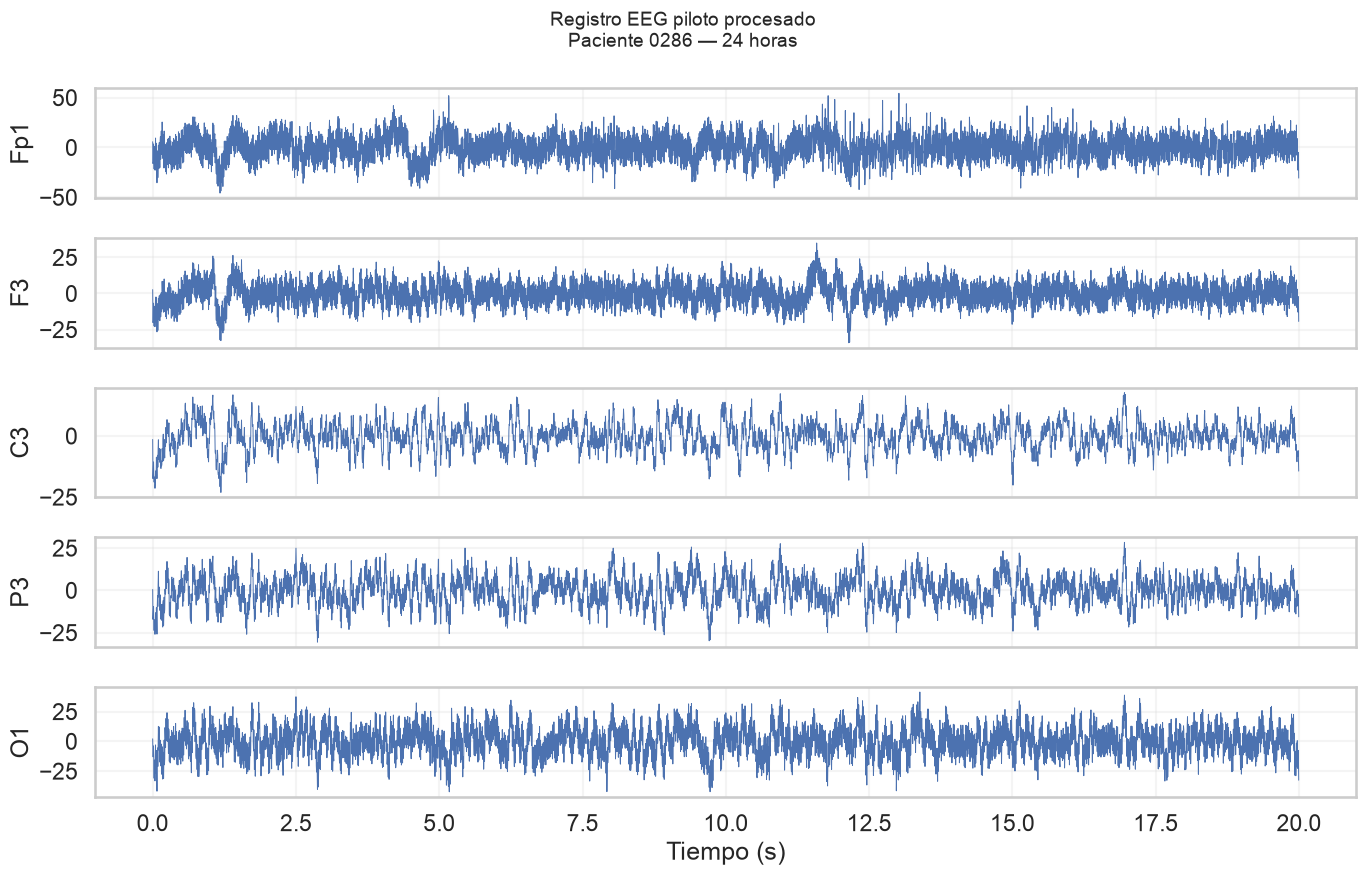

In [162]:
# ============================================================
# 34. VISUALIZACIÓN DEL REGISTRO PILOTO
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

signal = pilot_result["Signal"]

fs = TARGET_FS

channels_to_plot = [
    "Fp1",
    "F3",
    "C3",
    "P3",
    "O1"
]

seconds_to_plot = 20
n_samples_plot = seconds_to_plot * fs

time = np.arange(
    n_samples_plot
) / fs

fig, axes = plt.subplots(
    len(channels_to_plot),
    1,
    figsize=(14, 9),
    sharex=True
)

for ax, channel in zip(
    axes,
    channels_to_plot
):

    channel_index = COMMON_CHANNELS.index(
        channel
    )

    ax.plot(
        time,
        signal[
            channel_index,
            :n_samples_plot
        ],
        linewidth=0.7
    )

    ax.set_ylabel(channel)

    ax.grid(
        alpha=0.2
    )

axes[-1].set_xlabel(
    "Tiempo (s)"
)

fig.suptitle(
    "Registro EEG piloto procesado\n"
    "Paciente 0286 — 24 horas",
    fontsize=14
)

plt.tight_layout()

plt.show()

### 5.5 Procesamiento de la muestra EEG

Una vez validado el pipeline sobre un registro individual, se procede al procesamiento
de los 453 registros EEG correspondientes a los 100 pacientes seleccionados.

Cada registro es procesado de manera independiente mediante el pipeline definido
previamente. Para cada archivo se realiza la descarga de la señal original, selección
de los 19 canales comunes, extracción de la ventana de 90 segundos, calibración,
remuestreo a 200 Hz y filtrado.

La representación final de cada registro corresponde a una matriz de:

\[
19 \times 18\,000
\]

valores almacenados en formato `float32`.

Para evitar mantener simultáneamente los aproximadamente 20.10 GiB correspondientes a
los archivos originales, cada ventana procesada se almacena individualmente. El
procedimiento también conserva un registro del estado de procesamiento y permite
reanudar la ejecución sin repetir los registros procesados correctamente.

In [163]:
# ============================================================
# 35. DIRECTORIO PARA EEG PROCESADO
# ============================================================

PROCESSED_EEG_DIR = (
    PROCESSED_DATA
    / "eeg_sample"
)

PROCESSED_EEG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Directorio EEG procesado:",
    PROCESSED_EEG_DIR
)

Directorio EEG procesado: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/processed/eeg_sample


In [164]:
# ============================================================
# 36. DESCARGA CONCURRENTE DE LOS REGISTROS EEG
# ============================================================

from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

import requests
import pandas as pd
import time


# ------------------------------------------------------------
# 1. Construir lista de registros pendientes
# ------------------------------------------------------------

download_tasks = []

already_downloaded = 0

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    output_path = (
        EEG_DATA
        / patient_id
        / f"{record_name}.mat"
    )

    if output_path.exists():

        already_downloaded += 1

    else:

        download_tasks.append({
            "Patient": patient_id,
            "Record": record_name,
            "Hour": int(row["Hour"]),
            "Output_path": output_path
        })


print("Registros totales:", len(sampled_eeg_records))
print("Ya descargados:", already_downloaded)
print("Pendientes:", len(download_tasks))

Registros totales: 453
Ya descargados: 71
Pendientes: 382


In [165]:
# ============================================================
# 36. VERIFICACIÓN DE ARCHIVOS .MAT YA DESCARGADOS
# ============================================================

local_mat_status = []

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    mat_path = (
        EEG_DATA
        / patient_id
        / f"{record_name}.mat"
    )

    if mat_path.exists():

        size_mb = mat_path.stat().st_size / (1024 ** 2)

        local_mat_status.append({
            "Patient": patient_id,
            "Record": record_name,
            "Hour": int(row["Hour"]),
            "Size_MB": size_mb
        })


local_mat_df = pd.DataFrame(local_mat_status)

print("Archivos .mat encontrados:", len(local_mat_df))

if len(local_mat_df) > 0:

    display(
        local_mat_df.sort_values("Size_MB")
    )

    print("\nResumen de tamaños:")
    display(
        local_mat_df["Size_MB"].describe()
    )

Archivos .mat encontrados: 71


,Patient,Record,Hour,Size_MB
70,0434,0434_001_024_EEG,24,6.523155
21,0334,0334_022_026_EEG,26,6.845726
13,0306,0306_012_030_EEG,30,20.374535
34,0364,0364_025_028_EEG,28,28.112911
59,0411,0411_023_030_EEG,30,28.769592
...,...,...,...,...
35,0365,0365_011_024_EEG,24,70.312523
53,0402,0402_014_030_EEG,30,281.250023
52,0402,0402_012_028_EEG,28,281.250023
51,0402,0402_010_026_EEG,26,281.250023



Resumen de tamaños:


count     71.000000
mean      61.407963
std       57.110200
min        6.523155
25%       33.885979
50%       36.914085
75%       70.312523
max      281.250023
Name: Size_MB, dtype: float64

In [166]:
print("mat_validation_df existe:", "mat_validation_df" in globals())

if "mat_validation_df" in globals():
    print("Columnas:")
    print(mat_validation_df.columns.tolist())
    print("\nShape:", mat_validation_df.shape)

mat_validation_df existe: True
Columnas:
['Patient', 'Record', 'Hour', 'MAT_accessible', 'Size_bytes', 'Error', 'Size_MB']

Shape: (453, 7)


In [167]:
# ============================================================
# 37. VALIDAR INTEGRIDAD DE LOS .MAT EXISTENTES
# ============================================================

local_validation = []

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    mat_path = (
        EEG_DATA
        / patient_id
        / f"{record_name}.mat"
    )

    if not mat_path.exists():
        continue

    # Tamaño real del archivo local
    local_bytes = mat_path.stat().st_size

    # Tamaño esperado obtenido previamente del servidor
    remote_info = mat_validation_df.loc[
        mat_validation_df["Record"] == record_name
    ]

    if len(remote_info) == 1:

        expected_bytes = int(
            remote_info.iloc[0]["Size_bytes"]
        )

        complete = local_bytes == expected_bytes

    else:

        expected_bytes = None
        complete = False

    local_validation.append({
        "Patient": patient_id,
        "Record": record_name,
        "Hour": int(row["Hour"]),
        "Local_MB": local_bytes / 1024**2,
        "Expected_MB": (
            expected_bytes / 1024**2
            if expected_bytes is not None
            else None
        ),
        "Complete": complete
    })


local_validation_df = pd.DataFrame(local_validation)

display(
    local_validation_df.sort_values(
        ["Complete", "Patient", "Hour"]
    )
)

print("\nResumen:")
print(
    local_validation_df["Complete"]
    .value_counts(dropna=False)
)

print(
    "\nArchivos completos:",
    local_validation_df["Complete"].sum()
)

print(
    "Archivos incompletos:",
    (~local_validation_df["Complete"]).sum()
)

,Patient,Record,Hour,Local_MB,Expected_MB,Complete
0,0286,0286_005_024_EEG,24,70.312523,70.312523,True
1,0286,0286_008_026_EEG,26,70.312523,70.312523,True
2,0286,0286_010_028_EEG,28,70.312523,70.312523,True
3,0286,0286_012_030_EEG,30,62.519592,62.519592,True
4,0286,0286_015_032_EEG,32,70.312523,70.312523,True
...,...,...,...,...,...,...
66,0424,0424_022_024_EEG,24,32.615685,32.615685,True
67,0424,0424_024_026_EEG,26,32.615685,32.615685,True
68,0424,0424_026_028_EEG,28,32.615685,32.615685,True
69,0424,0424_028_030_EEG,30,32.615685,32.615685,True



Resumen:
Complete
True    71
Name: count, dtype: int64

Archivos completos: 71
Archivos incompletos: 0


In [168]:
# ============================================================
# 38. ELIMINAR ÚNICAMENTE ARCHIVOS .MAT INCOMPLETOS
# ============================================================

incomplete_records = local_validation_df.loc[
    ~local_validation_df["Complete"]
]

deleted_files = 0

for _, row in incomplete_records.iterrows():

    mat_path = (
        EEG_DATA
        / row["Patient"]
        / f"{row['Record']}.mat"
    )

    if mat_path.exists():

        mat_path.unlink()

        deleted_files += 1

        print(
            f"Eliminado: {row['Record']} "
            f"({row['Local_MB']:.2f} / "
            f"{row['Expected_MB']:.2f} MB)"
        )


print("\nArchivos incompletos eliminados:", deleted_files)


Archivos incompletos eliminados: 0


In [169]:
# Verificación después de la limpieza

remaining_mat_files = []

for _, row in sampled_eeg_records.iterrows():

    mat_path = (
        EEG_DATA
        / row["Patient"]
        / f"{row['Record']}.mat"
    )

    if mat_path.exists():
        remaining_mat_files.append(mat_path)


print(
    "Archivos .mat restantes:",
    len(remaining_mat_files)
)

print(
    "Registros pendientes:",
    len(sampled_eeg_records)
    - len(remaining_mat_files)
)

Archivos .mat restantes: 71
Registros pendientes: 382


In [170]:
# CELDA DESACTIVADA: todo el código está comentado y el kernel no ejecuta nada.
# Para reactivarla: selecciona todo y pulsa Ctrl+/ (Cmd+/ en Mac).
#
# # ============================================================
# # 39. DESCARGA CONCURRENTE ROBUSTA DE LOS EEG
# # ============================================================
#
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from tqdm.auto import tqdm
# import requests
# import time
#
#
# # ------------------------------------------------------------
# # 1. Construir tareas pendientes
# # ------------------------------------------------------------
#
# download_tasks = []
#
# for _, row in sampled_eeg_records.iterrows():
#
#     patient_id = row["Patient"]
#     record_name = row["Record"]
#
#     final_path = (
#         EEG_DATA
#         / patient_id
#         / f"{record_name}.mat"
#     )
#
#     # Tamaño esperado obtenido previamente del servidor
#     remote_info = mat_validation_df.loc[
#         mat_validation_df["Record"] == record_name
#     ]
#
#     if len(remote_info) != 1:
#         continue
#
#     expected_bytes = int(
#         remote_info.iloc[0]["Size_bytes"]
#     )
#
#     # Si existe y tiene exactamente el tamaño correcto,
#     # ya está completo.
#     if (
#         final_path.exists()
#         and final_path.stat().st_size == expected_bytes
#     ):
#         continue
#
#     download_tasks.append({
#         "Patient": patient_id,
#         "Record": record_name,
#         "Hour": int(row["Hour"]),
#         "Expected_bytes": expected_bytes,
#         "Final_path": final_path
#     })
#
#
# print("Registros totales:", len(sampled_eeg_records))
# print(
#     "Archivos completos:",
#     len(sampled_eeg_records) - len(download_tasks)
# )
# print("Pendientes:", len(download_tasks))
#
#
# # ------------------------------------------------------------
# # 2. Función robusta de descarga
# # ------------------------------------------------------------
#
# def download_eeg_file(task):
#
#     patient_id = task["Patient"]
#     record_name = task["Record"]
#
#     expected_bytes = task["Expected_bytes"]
#     final_path = task["Final_path"]
#
#     final_path.parent.mkdir(
#         parents=True,
#         exist_ok=True
#     )
#
#     # Archivo temporal
#     part_path = final_path.with_suffix(".mat.part")
#
#     # Eliminar un .part viejo si quedó de una interrupción
#     if part_path.exists():
#         part_path.unlink()
#
#     url = (
#         f"{BASE_URL}/training/"
#         f"{patient_id}/"
#         f"{record_name}.mat"
#     )
#
#     start = time.time()
#
#     try:
#
#         with requests.get(
#             url,
#             stream=True,
#             timeout=(30, 300)
#         ) as response:
#
#             response.raise_for_status()
#
#             with open(part_path, "wb") as file:
#
#                 for chunk in response.iter_content(
#                     chunk_size=1024 * 1024
#                 ):
#
#                     if chunk:
#                         file.write(chunk)
#
#         actual_bytes = part_path.stat().st_size
#
#         # Validación estricta
#         if actual_bytes != expected_bytes:
#
#             part_path.unlink()
#
#             raise ValueError(
#                 f"Tamaño incorrecto: "
#                 f"{actual_bytes} != {expected_bytes}"
#             )
#
#         # Solo un archivo completamente validado
#         # recibe extensión .mat
#         part_path.replace(final_path)
#
#         return {
#             "Patient": patient_id,
#             "Record": record_name,
#             "Hour": task["Hour"],
#             "Status": "OK",
#             "Size_MB": actual_bytes / 1024**2,
#             "Seconds": time.time() - start,
#             "Error": None
#         }
#
#     except Exception as error:
#
#         if part_path.exists():
#             part_path.unlink()
#
#         return {
#             "Patient": patient_id,
#             "Record": record_name,
#             "Hour": task["Hour"],
#             "Status": "ERROR",
#             "Size_MB": None,
#             "Seconds": time.time() - start,
#             "Error": str(error)
#         }
#
#
# # ------------------------------------------------------------
# # 3. Descargar concurrentemente
# # ------------------------------------------------------------
#
# MAX_WORKERS = 4
#
# results = []
#
# start_time = time.time()
#
# with ThreadPoolExecutor(
#     max_workers=MAX_WORKERS
# ) as executor:
#
#     futures = [
#         executor.submit(
#             download_eeg_file,
#             task
#         )
#         for task in download_tasks
#     ]
#
#     with tqdm(
#         total=len(futures),
#         desc="Descargando EEG",
#         unit="archivo"
#     ) as progress:
#
#         for future in as_completed(futures):
#
#             result = future.result()
#
#             results.append(result)
#
#             progress.update(1)
#
#             # Mostrar errores sin destruir la barra
#             if result["Status"] == "ERROR":
#                 tqdm.write(
#                     f"ERROR: {result['Record']} "
#                     f"→ {result['Error']}"
#                 )
#
#
# # ------------------------------------------------------------
# # 4. Resumen
# # ------------------------------------------------------------
#
# download_results_df = pd.DataFrame(results)
#
# elapsed = time.time() - start_time
#
# print("\nDescarga terminada.")
#
# print(
#     f"Tiempo total: "
#     f"{elapsed / 60:.2f} minutos"
# )
#
# if len(download_results_df) > 0:
#
#     print("\nResultado:")
#
#     print(
#         download_results_df["Status"]
#         .value_counts()
#     )
#
#     successful = (
#         download_results_df["Status"] == "OK"
#     ).sum()
#
#     failed = (
#         download_results_df["Status"] == "ERROR"
#     ).sum()
#
#     print("\nDescargados correctamente:", successful)
#     print("Errores:", failed)

### Verificación final de los registros EEG descargados

Una vez finalizada la descarga, se verificó la integridad de los archivos EEG utilizados en la muestra. Para cada registro se comparó el tamaño del archivo almacenado localmente con el tamaño esperado obtenido previamente durante la validación de disponibilidad en PhysioNet.

Esta comprobación permite identificar descargas incompletas o archivos faltantes antes de iniciar el procesamiento de las señales. Un registro se considera válido para las etapas posteriores únicamente cuando el archivo existe localmente y su tamaño coincide con el tamaño esperado.

In [171]:
print("Kernel disponible")
print(len(sampled_eeg_records))

Kernel disponible
453


### Construcción de la submuestra piloto de señales EEG

La muestra diseñada para la exploración EEG comprende 100 pacientes y 453 observaciones paciente-hora. Sin embargo, los archivos originales de señal representan un volumen considerable de almacenamiento y transferencia.

Por esta razón, la inspección directa de las señales se realizó sobre una submuestra piloto constituida por los registros que se encontraban completamente disponibles localmente al momento del análisis. Para evitar incorporar descargas incompletas, cada archivo local se comparó con el tamaño esperado obtenido durante la validación previa de disponibilidad.

Esta submuestra se utiliza exclusivamente para la exploración descriptiva de la estructura y características básicas de las señales EEG. En consecuencia, los resultados derivados directamente de las señales se interpretan como exploratorios y no como estimaciones representativas de la población completa.

In [172]:
# ============================================================
# 39.1 SUBMUESTRA PILOTO DISPONIBLE LOCALMENTE
# ============================================================

pilot_records = []

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    mat_path = (
        EEG_DATA
        / patient_id
        / f"{record_name}.mat"
    )

    remote_info = mat_validation_df.loc[
        mat_validation_df["Record"] == record_name
    ]

    if len(remote_info) != 1:
        continue

    expected_bytes = int(
        remote_info.iloc[0]["Size_bytes"]
    )

    # Solo se incluyen archivos completamente descargados
    if (
        mat_path.exists()
        and mat_path.stat().st_size == expected_bytes
    ):

        pilot_records.append(
            row.to_dict()
        )


pilot_eeg_records = pd.DataFrame(
    pilot_records
).reset_index(drop=True)


# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

print("=== SUBMUESTRA PILOTO EEG ===")

print(
    "Registros completos disponibles:",
    len(pilot_eeg_records)
)

print(
    "Pacientes únicos:",
    pilot_eeg_records["Patient"].nunique()
)

print("\nDistribución por hora:")

display(
    pilot_eeg_records["Hour"]
    .value_counts()
    .sort_index()
    .rename_axis("Hour")
    .reset_index(name="Records")
)


print("\nNúmero de ventanas disponibles por paciente:")

display(
    pilot_eeg_records
    .groupby("Patient")
    .size()
    .value_counts()
    .sort_index()
    .rename_axis("Available_windows")
    .reset_index(name="Patients")
)

=== SUBMUESTRA PILOTO EEG ===
Registros completos disponibles: 71
Pacientes únicos: 17

Distribución por hora:


,Hour,Records
0,24,17
1,26,16
2,28,14
3,30,13
4,32,11



Número de ventanas disponibles por paciente:


,Available_windows,Patients
0,1,1
1,2,2
2,3,1
3,4,2
4,5,11


In [173]:
# A partir de este punto, el análisis directo de señales
# utiliza exclusivamente la submuestra piloto disponible.

sampled_eeg_records_original = sampled_eeg_records.copy()

sampled_eeg_records = pilot_eeg_records.copy()

print(
    f"Registros utilizados para exploración directa: "
    f"{len(sampled_eeg_records)}"
)

print(
    f"Pacientes representados: "
    f"{sampled_eeg_records['Patient'].nunique()}"
)

Registros utilizados para exploración directa: 71
Pacientes representados: 17


In [174]:
# ============================================================
# 40. VERIFICACIÓN FINAL DE INTEGRIDAD DE LOS ARCHIVOS EEG
# ============================================================

integrity_results = []

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    mat_path = (
        EEG_DATA
        / patient_id
        / f"{record_name}.mat"
    )

    remote_info = mat_validation_df.loc[
        mat_validation_df["Record"] == record_name
    ]

    if len(remote_info) == 1:
        expected_bytes = int(
            remote_info.iloc[0]["Size_bytes"]
        )
    else:
        expected_bytes = None

    exists = mat_path.exists()

    local_bytes = (
        mat_path.stat().st_size
        if exists
        else None
    )

    valid_size = (
        exists
        and expected_bytes is not None
        and local_bytes == expected_bytes
    )

    integrity_results.append({
        "Patient": patient_id,
        "Record": record_name,
        "Hour": int(row["Hour"]),
        "Exists": exists,
        "Local_MB": (
            local_bytes / 1024**2
            if local_bytes is not None
            else None
        ),
        "Expected_MB": (
            expected_bytes / 1024**2
            if expected_bytes is not None
            else None
        ),
        "Valid_size": valid_size
    })


integrity_df = pd.DataFrame(integrity_results)


# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

n_total = len(integrity_df)

n_existing = integrity_df["Exists"].sum()

n_valid = integrity_df["Valid_size"].sum()

n_invalid = n_total - n_valid


print("Registros esperados:", n_total)
print("Archivos encontrados:", n_existing)
print("Archivos íntegros:", n_valid)
print("Archivos faltantes/incompletos:", n_invalid)


# ------------------------------------------------------------
# Mostrar problemas, si existen
# ------------------------------------------------------------

invalid_files = integrity_df.loc[
    ~integrity_df["Valid_size"]
]

if len(invalid_files) == 0:

    print(
        "\n✓ Todos los archivos EEG están disponibles "
        "y presentan el tamaño esperado."
    )

else:

    print(
        "\n⚠ Se encontraron archivos faltantes "
        "o incompletos:"
    )

    display(invalid_files)

Registros esperados: 71
Archivos encontrados: 71
Archivos íntegros: 71
Archivos faltantes/incompletos: 0

✓ Todos los archivos EEG están disponibles y presentan el tamaño esperado.


### Verificación de registros EEG previamente procesados

Antes de iniciar el procesamiento completo de la muestra, se verificaron los registros que pudieran haber sido procesados durante ejecuciones anteriores. Cada señal procesada debe cumplir con la representación definida durante la preparación de los datos: 19 canales EEG comunes, una ventana temporal de 90 segundos y una frecuencia de muestreo final de 200 Hz.

Por tanto, cada matriz procesada debe presentar dimensiones \(19 \times 18\,000\). Adicionalmente, se comprobó que todos sus valores fueran finitos. Los archivos que no satisfagan estas condiciones serán considerados inválidos y deberán ser procesados nuevamente.

In [175]:
# ============================================================
# 41. VERIFICACIÓN DE EEG PREVIAMENTE PROCESADOS
# ============================================================

processed_validation = []

EXPECTED_CHANNELS = 19
EXPECTED_SAMPLES = 90 * 200

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    npy_path = (
        PROCESSED_EEG_DIR
        / patient_id
        / f"{record_name}.npy"
    )

    exists = npy_path.exists()

    shape = None
    finite = False
    valid = False
    error = None

    if exists:

        try:

            signal = np.load(
                npy_path,
                mmap_mode="r"
            )

            shape = signal.shape

            finite = bool(
                np.isfinite(signal).all()
            )

            valid = (
                shape
                == (
                    EXPECTED_CHANNELS,
                    EXPECTED_SAMPLES
                )
                and finite
            )

        except Exception as exc:

            error = str(exc)

    processed_validation.append({
        "Patient": patient_id,
        "Record": record_name,
        "Hour": int(row["Hour"]),
        "Exists": exists,
        "Shape": shape,
        "Finite": finite,
        "Valid": valid,
        "Error": error
    })


processed_validation_df = pd.DataFrame(
    processed_validation
)


# ------------------------------------------------------------
# Resumen
# ------------------------------------------------------------

n_processed = (
    processed_validation_df["Exists"].sum()
)

n_valid_processed = (
    processed_validation_df["Valid"].sum()
)

n_invalid_processed = (
    (
        processed_validation_df["Exists"]
        & ~processed_validation_df["Valid"]
    )
    .sum()
)

n_pending_processing = (
    len(processed_validation_df)
    - n_valid_processed
)


print(
    "Registros de la muestra:",
    len(processed_validation_df)
)

print(
    "Archivos .npy encontrados:",
    n_processed
)

print(
    "Procesados válidos:",
    n_valid_processed
)

print(
    "Procesados inválidos:",
    n_invalid_processed
)

print(
    "Pendientes por procesar:",
    n_pending_processing
)

Registros de la muestra: 71
Archivos .npy encontrados: 50
Procesados válidos: 50
Procesados inválidos: 0
Pendientes por procesar: 21


### Procesamiento de las señales EEG seleccionadas

Los registros EEG seleccionados presentan diferencias en su frecuencia de muestreo original y en el número de canales disponibles. Para obtener una representación homogénea, cada registro fue transformado utilizando el procedimiento definido durante la etapa de preparación de los datos.

Para cada registro se extrajo la ventana temporal de 90 segundos previamente seleccionada. Posteriormente, se conservaron 19 canales EEG comunes, se aplicó la calibración indicada en el encabezado del registro, se remuestreó la señal a 200 Hz y se aplicaron un filtro pasa banda entre 0.5 y 70 Hz y un filtro notch a 50 Hz.

Como resultado, cada registro queda representado mediante una matriz de dimensiones \(19 \times 18\,000\), correspondiente a 19 canales y 18 000 muestras por canal. Los registros procesados se almacenan individualmente para permitir la reanudación del procedimiento sin repetir señales previamente procesadas.

In [176]:
# ============================================================
# 42. PROCESAMIENTO DE LOS EEG PENDIENTES
# ============================================================

processing_results = []

for _, row in tqdm(
    sampled_eeg_records.iterrows(),
    total=len(sampled_eeg_records),
    desc="Procesando EEG",
    unit="registro"
):

    patient_id = row["Patient"]
    record_name = row["Record"]

    output_dir = (
        PROCESSED_EEG_DIR
        / patient_id
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_path = (
        output_dir
        / f"{record_name}.npy"
    )

    # --------------------------------------------------------
    # 1. Comprobar si ya existe un resultado válido
    # --------------------------------------------------------

    if output_path.exists():

        try:

            existing_signal = np.load(
                output_path,
                mmap_mode="r"
            )

            existing_valid = (
                existing_signal.shape == (19, 18000)
                and np.isfinite(existing_signal).all()
            )

        except Exception:

            existing_valid = False

        if existing_valid:

            processing_results.append({
                "Patient": patient_id,
                "Record": record_name,
                "Hour": int(row["Hour"]),
                "Status": "already_processed",
                "Error": None
            })

            continue

        else:

            # Eliminar un resultado inválido
            output_path.unlink()


    # --------------------------------------------------------
    # 2. Procesar el registro
    # --------------------------------------------------------

    try:

        result = process_eeg_record(row)

        signal = result["Signal"]


        # ----------------------------------------------------
        # 3. Validación antes de guardar
        # ----------------------------------------------------

        if signal.shape != (19, 18000):

            raise ValueError(
                f"Dimensión inesperada: {signal.shape}"
            )

        if not np.isfinite(signal).all():

            raise ValueError(
                "La señal contiene valores no finitos."
            )


        # ----------------------------------------------------
        # 4. Guardar resultado
        # ----------------------------------------------------

        np.save(
            output_path,
            signal.astype(np.float32)
        )


        processing_results.append({
            "Patient": patient_id,
            "Record": record_name,
            "Hour": int(row["Hour"]),
            "Status": "processed",
            "Error": None
        })


    except Exception as exc:

        processing_results.append({
            "Patient": patient_id,
            "Record": record_name,
            "Hour": int(row["Hour"]),
            "Status": "error",
            "Error": str(exc)
        })


# ------------------------------------------------------------
# Resultado
# ------------------------------------------------------------

processing_results_df = pd.DataFrame(
    processing_results
)

print("\nResultado del procesamiento:")

display(
    processing_results_df["Status"]
    .value_counts()
    .rename_axis("Status")
    .reset_index(name="Count")
)

Procesando EEG:   0%|          | 0/71 [00:00<?, ?registro/s]

Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0402/0402_008_024_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0402/0402_010_026_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0402/0402_012_028_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0402/0402_014_030_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0405/0405_017_024_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0405/0405_019_026_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalysis/mlda-project_/data/raw/eeg/0411/0411_017_024_EEG.mat
Ya existe: /Users/byepesg/Documents/Kumanday/UNAL-MG/DataVisualizationAnalys

,Status,Count
0,already_processed,50
1,processed,21


### Validación final y construcción del conjunto maestro EEG

Una vez procesadas las señales, se realizó una validación final de los archivos generados. Para cada registro se comprobó la existencia del archivo procesado, sus dimensiones esperadas de \(19 \times 18\,000\) y la ausencia de valores no finitos.

Posteriormente, la información de los registros EEG se integró con las variables clínicas disponibles a nivel de paciente. De esta forma se construyó un conjunto maestro en el que cada fila representa una observación paciente-hora y contiene la identificación del registro, la ventana temporal, el hospital, el desenlace neurológico y la ubicación del archivo EEG procesado.

Debe tenerse en cuenta que múltiples filas pueden corresponder al mismo paciente debido a la disponibilidad de registros en diferentes ventanas temporales. Por tanto, las 453 observaciones paciente-hora no deben interpretarse como observaciones estadísticamente independientes.

In [177]:
# ============================================================
# 43. VALIDACIÓN FINAL Y CONSTRUCCIÓN DEL DATASET MAESTRO EEG
# ============================================================

final_validation = []

for _, row in sampled_eeg_records.iterrows():

    patient_id = row["Patient"]
    record_name = row["Record"]

    npy_path = (
        PROCESSED_EEG_DIR
        / patient_id
        / f"{record_name}.npy"
    )

    exists = npy_path.exists()

    shape = None
    finite = False
    valid = False
    dtype = None

    if exists:

        try:

            signal = np.load(
                npy_path,
                mmap_mode="r"
            )

            shape = signal.shape
            dtype = str(signal.dtype)

            finite = bool(
                np.isfinite(signal).all()
            )

            valid = (
                shape == (19, 18000)
                and finite
            )

        except Exception:
            valid = False

    final_validation.append({
        "Patient": patient_id,
        "Record": record_name,
        "Hour": int(row["Hour"]),
        "EEG_path": str(npy_path),
        "Exists": exists,
        "Shape": shape,
        "Dtype": dtype,
        "Finite": finite,
        "Valid": valid
    })


final_validation_df = pd.DataFrame(
    final_validation
)


# ------------------------------------------------------------
# Resumen de validación
# ------------------------------------------------------------

print(
    "Registros esperados:",
    len(final_validation_df)
)

print(
    "Archivos encontrados:",
    final_validation_df["Exists"].sum()
)

print(
    "Registros válidos:",
    final_validation_df["Valid"].sum()
)

print(
    "Registros inválidos:",
    (~final_validation_df["Valid"]).sum()
)

Registros esperados: 71
Archivos encontrados: 71
Registros válidos: 71
Registros inválidos: 0


In [178]:
# ============================================================
# 43.1 DATASET MAESTRO EEG + INFORMACIÓN CLÍNICA
# ============================================================

eeg_master_df = (
    final_validation_df.loc[
        final_validation_df["Valid"]
    ]
    .merge(
        clinical_df[
            [
                "Patient",
                "Hospital",
                "Age",
                "Sex",
                "ROSC",
                "OHCA",
                "Shockable Rhythm",
                "TTM",
                "Outcome",
                "CPC"
            ]
        ],
        on="Patient",
        how="left",
        validate="many_to_one"
    )
    .sort_values(
        ["Patient", "Hour"]
    )
    .reset_index(drop=True)
)

print(
    "Observaciones paciente-hora:",
    len(eeg_master_df)
)

print(
    "Pacientes únicos:",
    eeg_master_df["Patient"].nunique()
)

print(
    "Ventanas temporales:",
    sorted(eeg_master_df["Hour"].unique())
)

print(
    "Registros clínicos faltantes:",
    eeg_master_df["Outcome"].isna().sum()
)

display(eeg_master_df.head())

Observaciones paciente-hora: 71
Pacientes únicos: 17
Ventanas temporales: [np.int64(24), np.int64(26), np.int64(28), np.int64(30), np.int64(32)]
Registros clínicos faltantes: 0


,Patient,Record,Hour,EEG_path,Exists,Shape,Dtype,Finite,Valid,Hospital,Age,Sex,ROSC,OHCA,Shockable Rhythm,TTM,Outcome,CPC
0,0286,0286_005_024_EEG,24,/Users/byepesg/Documents/Kumanday/UNAL-MG/Data...,True,"(19, 18000)",float32,True,True,F,85,Female,7,False,False,nan,Good,1
1,0286,0286_008_026_EEG,26,/Users/byepesg/Documents/Kumanday/UNAL-MG/Data...,True,"(19, 18000)",float32,True,True,F,85,Female,7,False,False,nan,Good,1
2,0286,0286_010_028_EEG,28,/Users/byepesg/Documents/Kumanday/UNAL-MG/Data...,True,"(19, 18000)",float32,True,True,F,85,Female,7,False,False,nan,Good,1
3,0286,0286_012_030_EEG,30,/Users/byepesg/Documents/Kumanday/UNAL-MG/Data...,True,"(19, 18000)",float32,True,True,F,85,Female,7,False,False,nan,Good,1
4,0286,0286_015_032_EEG,32,/Users/byepesg/Documents/Kumanday/UNAL-MG/Data...,True,"(19, 18000)",float32,True,True,F,85,Female,7,False,False,nan,Good,1


### Caracterización descriptiva de las señales EEG

Una vez construida la representación homogénea de las señales EEG, se realizó una caracterización descriptiva básica de cada registro procesado. El propósito de este análisis es examinar la estructura y variabilidad de las señales antes de realizar comparaciones entre grupos clínicos.

Para cada canal de cada registro se calcularon la media, desviación estándar, valor mínimo, valor máximo, amplitud pico a pico y raíz cuadrática media (RMS). Estas medidas permiten identificar diferencias de escala, registros con amplitudes extremas, canales con variabilidad reducida y posibles observaciones que requieran inspección adicional.

Dado que cada paciente puede aportar registros correspondientes a diferentes ventanas temporales, las características obtenidas conservan la identificación del paciente, el registro, la hora y el canal.

In [179]:
# ============================================================
# 44. CARACTERIZACIÓN DESCRIPTIVA DE LAS SEÑALES EEG
# ============================================================

COMMON_CHANNELS = [
    "Fp1", "Fp2",
    "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T3", "T4",
    "T5", "T6",
    "Fz", "Cz", "Pz"
]

signal_features = []

for _, row in tqdm(
    eeg_master_df.iterrows(),
    total=len(eeg_master_df),
    desc="Extrayendo características",
    unit="registro"
):

    signal = np.load(
        row["EEG_path"],
        mmap_mode="r"
    )

    for channel_idx, channel_name in enumerate(
        COMMON_CHANNELS
    ):

        channel_signal = signal[channel_idx]

        signal_features.append({
            "Patient": row["Patient"],
            "Record": row["Record"],
            "Hour": row["Hour"],
            "Hospital": row["Hospital"],
            "Outcome": row["Outcome"],
            "CPC": row["CPC"],
            "Channel": channel_name,

            "Mean": float(
                np.mean(channel_signal)
            ),

            "Std": float(
                np.std(channel_signal)
            ),

            "Min": float(
                np.min(channel_signal)
            ),

            "Max": float(
                np.max(channel_signal)
            ),

            "Peak_to_peak": float(
                np.ptp(channel_signal)
            ),

            "RMS": float(
                np.sqrt(
                    np.mean(
                        np.square(
                            channel_signal.astype(
                                np.float64
                            )
                        )
                    )
                )
            )
        })


eeg_features_df = pd.DataFrame(
    signal_features
)

print(
    "Registros EEG:",
    eeg_master_df.shape[0]
)

print(
    "Canales por registro:",
    len(COMMON_CHANNELS)
)

print(
    "Observaciones registro-canal:",
    len(eeg_features_df)
)

display(
    eeg_features_df.head()
)

Extrayendo características:   0%|          | 0/71 [00:00<?, ?registro/s]

Registros EEG: 71
Canales por registro: 19
Observaciones registro-canal: 1349


,Patient,Record,Hour,Hospital,Outcome,CPC,Channel,Mean,Std,Min,Max,Peak_to_peak,RMS
0,0286,0286_005_024_EEG,24,F,Good,1,Fp1,-0.045221,14.847520,-49.733139,57.403553,107.136688,14.847588
1,0286,0286_005_024_EEG,24,F,Good,1,Fp2,-0.063106,15.375846,-50.111835,58.111019,108.222855,15.375976
2,0286,0286_005_024_EEG,24,F,Good,1,F3,-0.036854,8.835837,-34.143627,40.109921,74.253548,8.835914
3,0286,0286_005_024_EEG,24,F,Good,1,F4,-0.047734,9.514011,-32.664536,37.087921,69.752457,9.514131
4,0286,0286_005_024_EEG,24,F,Good,1,C3,-0.010216,5.862120,-23.695913,29.070787,52.766701,5.862128


### Distribución de las características descriptivas y detección de valores extremos

A partir de las características calculadas para cada combinación registro-canal, se examinó la distribución de la desviación estándar, la raíz cuadrática media (RMS) y la amplitud pico a pico.

Estas medidas permiten caracterizar la magnitud y variabilidad de las señales EEG procesadas. En esta etapa, los valores extremos no se eliminan automáticamente, dado que pueden corresponder tanto a características reales de la señal como a posibles artefactos. En su lugar, se identifican observaciones que requieren una inspección posterior.

La detección exploratoria de valores extremos se realizó mediante el criterio del rango intercuartílico (IQR), utilizando como límites \(Q_1-1.5\,IQR\) y \(Q_3+1.5\,IQR\).

In [180]:
# ============================================================
# 45. DISTRIBUCIÓN DE LAS CARACTERÍSTICAS EEG
# ============================================================

feature_columns = [
    "Std",
    "RMS",
    "Peak_to_peak"
]

feature_summary = (
    eeg_features_df[
        feature_columns
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99
        ]
    )
    .T
)

display(feature_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Std,1349.0,24.567183,101.021846,0.0,0.0,1.358399,7.285762,10.748495,15.001084,55.587794,288.136727,2407.276123
RMS,1349.0,24.570053,101.024566,0.0,0.0,1.358412,7.285859,10.748496,15.001231,55.650226,288.136736,2407.276131
Peak_to_peak,1349.0,425.983574,1700.133449,0.0,0.0,20.670963,64.983063,97.317055,152.398941,1409.022144,8856.594766,26554.550781


/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_96299/1468141090.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


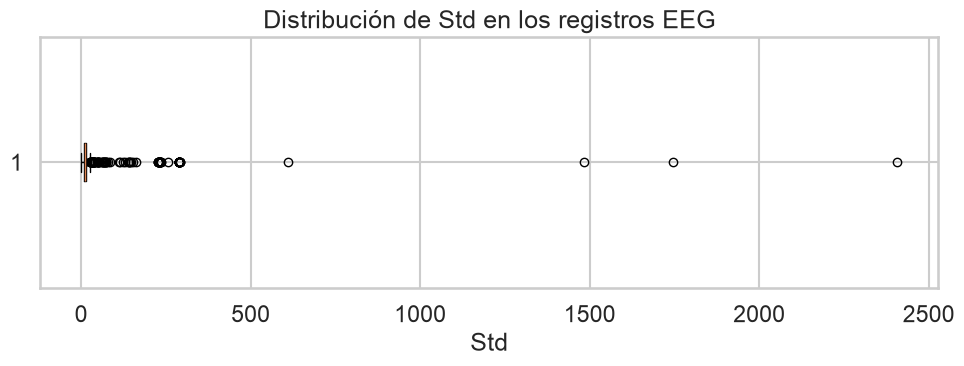

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_96299/1468141090.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


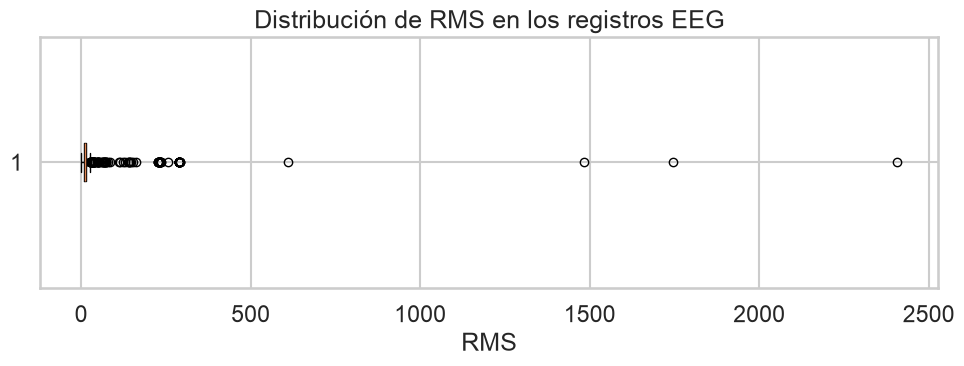

/var/folders/bv/hf85_zp55q1g6zv69_qdp7vm0000gn/T/ipykernel_96299/1468141090.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


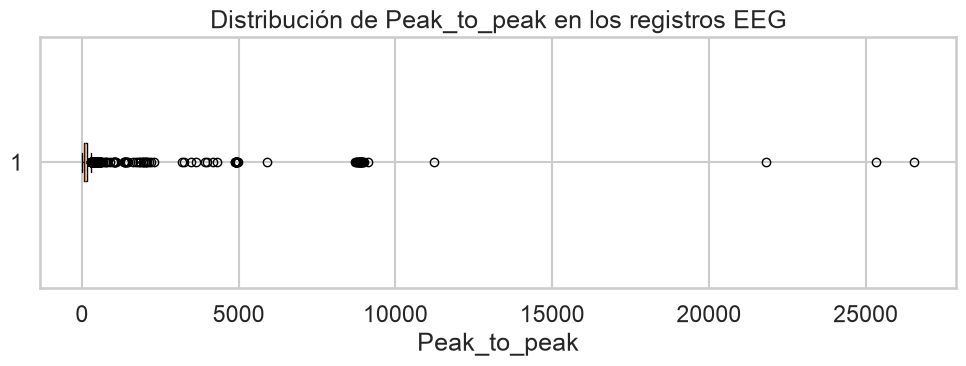

In [181]:
# ============================================================
# 45.1 BOXPLOTS DE LAS CARACTERÍSTICAS EEG
# ============================================================

import matplotlib.pyplot as plt


for feature in feature_columns:

    plt.figure(figsize=(10, 4))

    plt.boxplot(
        eeg_features_df[feature].dropna(),
        vert=False
    )

    plt.xlabel(feature)

    plt.title(
        f"Distribución de {feature} "
        "en los registros EEG"
    )

    plt.tight_layout()
    plt.show()

In [182]:
# ============================================================
# 45.2 IDENTIFICACIÓN EXPLORATORIA DE VALORES EXTREMOS
# ============================================================

outlier_summary = []

for feature in feature_columns:

    q1 = eeg_features_df[feature].quantile(0.25)
    q3 = eeg_features_df[feature].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (eeg_features_df[feature] < lower_bound)
        |
        (eeg_features_df[feature] > upper_bound)
    )

    n_outliers = outlier_mask.sum()

    outlier_summary.append({
        "Feature": feature,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_bound": lower_bound,
        "Upper_bound": upper_bound,
        "Outliers": n_outliers,
        "Outlier_percentage": (
            100 * n_outliers
            / len(eeg_features_df)
        )
    })


outlier_summary_df = pd.DataFrame(
    outlier_summary
)

display(outlier_summary_df)

,Feature,Q1,Q3,IQR,Lower_bound,Upper_bound,Outliers,Outlier_percentage
0,Std,7.285762,15.001084,7.715322,-4.287222,26.574068,102,7.561156
1,RMS,7.285859,15.001231,7.715372,-4.287198,26.574288,102,7.561156
2,Peak_to_peak,64.983063,152.398941,87.415878,-66.140755,283.522758,158,11.712380


In [183]:
# ============================================================
# 45.3 REGISTROS CON AMPLITUD PICO A PICO EXTREMA
# ============================================================

q1 = eeg_features_df["Peak_to_peak"].quantile(0.25)
q3 = eeg_features_df["Peak_to_peak"].quantile(0.75)

iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr


extreme_peak_to_peak = (
    eeg_features_df.loc[
        eeg_features_df["Peak_to_peak"]
        > upper_bound,
        [
            "Patient",
            "Record",
            "Hour",
            "Hospital",
            "Outcome",
            "Channel",
            "Peak_to_peak",
            "Std",
            "RMS"
        ]
    ]
    .sort_values(
        "Peak_to_peak",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Observaciones con Peak-to-peak extremo:",
    len(extreme_peak_to_peak)
)

display(
    extreme_peak_to_peak.head(20)
)

Observaciones con Peak-to-peak extremo: 158


,Patient,Record,Hour,Hospital,Outcome,Channel,Peak_to_peak,Std,RMS
0,0303,0303_004_024_EEG,24,D,Good,Pz,26554.550781,1746.540527,1746.651782
1,0303,0303_012_032_EEG,32,D,Good,Pz,25344.519531,2407.276123,2407.276131
2,0303,0303_010_030_EEG,30,D,Good,Pz,21820.984375,1483.083130,1483.083272
3,0365,0365_011_024_EEG,24,A,Good,P3,11227.148438,611.299744,611.299725
4,0362,0362_031_032_EEG,32,A,Good,C4,9121.593750,236.524719,236.524910
5,0362,0362_031_032_EEG,32,A,Good,Fp2,8999.343750,235.253250,235.253275
6,0362,0362_031_032_EEG,32,A,Good,Fz,8970.778320,232.205444,232.205497
7,0362,0362_031_032_EEG,32,A,Good,Cz,8947.708984,231.665771,231.665772
8,0362,0362_031_032_EEG,32,A,Good,F3,8925.592773,231.342026,231.342037
9,0362,0362_031_032_EEG,32,A,Good,F4,8911.819336,231.292740,231.292769


#### Interpretación de los valores extremos

Las características de amplitud presentaron distribuciones marcadamente asimétricas. Mediante el criterio del rango intercuartílico se identificaron 60 observaciones registro-canal (6.32 %) como extremas para la desviación estándar y el RMS, y 86 (9.05 %) para la amplitud pico a pico.

La inspección de las observaciones con mayor amplitud mostró que los valores extremos no se distribuyen uniformemente entre los registros. En particular, algunos corresponden repetidamente a un mismo canal en diferentes ventanas temporales de un paciente, mientras que otros aparecen simultáneamente en múltiples canales de un mismo registro.

Este comportamiento sugiere la existencia de diferentes fuentes de heterogeneidad en las señales. Sin embargo, las medidas descriptivas por sí solas no permiten determinar si estas observaciones corresponden a actividad fisiológica, artefactos o características particulares del proceso de adquisición. Por esta razón, los valores extremos no fueron eliminados automáticamente y se complementó su análisis mediante inspección visual de las señales.

### Visualización de señales EEG procesadas

Como complemento de las medidas descriptivas, se realizó una inspección visual de registros EEG procesados. Debido a la alta densidad temporal de las señales, se utilizaron segmentos de 10 segundos para facilitar la visualización de la morfología y variabilidad de los diferentes canales.

Los 19 canales se representan con un desplazamiento vertical relativo para evitar la superposición de las señales. Esta visualización tiene un propósito exploratorio y permite verificar cualitativamente la estructura de los registros después del remuestreo y filtrado, así como identificar posibles patrones atípicos que requieran inspección adicional.

Las amplitudes se presentan en las unidades resultantes de la calibración proporcionada por los archivos originales. Dado que los encabezados inspeccionados no permiten asumir directamente que estas unidades correspondan a microvoltios, no se realiza dicha conversión en esta etapa.

In [184]:
# ============================================================
# 46. VISUALIZACIÓN DE EEG MULTICANAL
# ============================================================

TARGET_FS = 200

def plot_eeg_segment(
    eeg_row,
    start_second=0,
    duration_seconds=10
):

    signal = np.load(
        eeg_row["EEG_path"],
        mmap_mode="r"
    )

    start_sample = int(
        start_second * TARGET_FS
    )

    end_sample = int(
        (start_second + duration_seconds)
        * TARGET_FS
    )

    segment = np.asarray(
        signal[:, start_sample:end_sample]
    )

    time_axis = (
        np.arange(segment.shape[1])
        / TARGET_FS
        + start_second
    )

    # --------------------------------------------------------
    # Separación vertical robusta entre canales
    # --------------------------------------------------------

    channel_scale = np.median(
        np.std(segment, axis=1)
    )

    if (
        not np.isfinite(channel_scale)
        or channel_scale == 0
    ):
        channel_scale = 1.0

    offset = 6 * channel_scale

    plt.figure(
        figsize=(14, 10)
    )

    for channel_idx, channel_name in enumerate(
        COMMON_CHANNELS
    ):

        vertical_position = (
            (len(COMMON_CHANNELS) - 1 - channel_idx)
            * offset
        )

        plt.plot(
            time_axis,
            segment[channel_idx]
            + vertical_position,
            linewidth=0.7
        )

    tick_positions = [
        (len(COMMON_CHANNELS) - 1 - i)
        * offset
        for i in range(len(COMMON_CHANNELS))
    ]

    plt.yticks(
        tick_positions,
        COMMON_CHANNELS
    )

    plt.xlabel("Tiempo (s)")
    plt.ylabel("Canal")

    plt.title(
        f"EEG procesado — Paciente {eeg_row['Patient']} "
        f"— {int(eeg_row['Hour'])} h "
        f"— Outcome: {eeg_row['Outcome']}"
    )

    plt.xlim(
        start_second,
        start_second + duration_seconds
    )

    plt.tight_layout()
    plt.show()

In [185]:
# ============================================================
# 46.1 SELECCIÓN REPRODUCIBLE DE EJEMPLOS
# ============================================================

example_records = (
    eeg_master_df.loc[
        eeg_master_df["Hour"] == 28
    ]
    .sort_values(
        ["Outcome", "Patient"]
    )
    .groupby(
        "Outcome",
        as_index=False
    )
    .first()
)

display(
    example_records[
        [
            "Patient",
            "Record",
            "Hour",
            "Hospital",
            "Outcome",
            "CPC"
        ]
    ]
)

,Patient,Record,Hour,Hospital,Outcome,CPC
0,0286,0286_010_028_EEG,28,F,Good,1
1,0364,0364_025_028_EEG,28,B,Poor,5


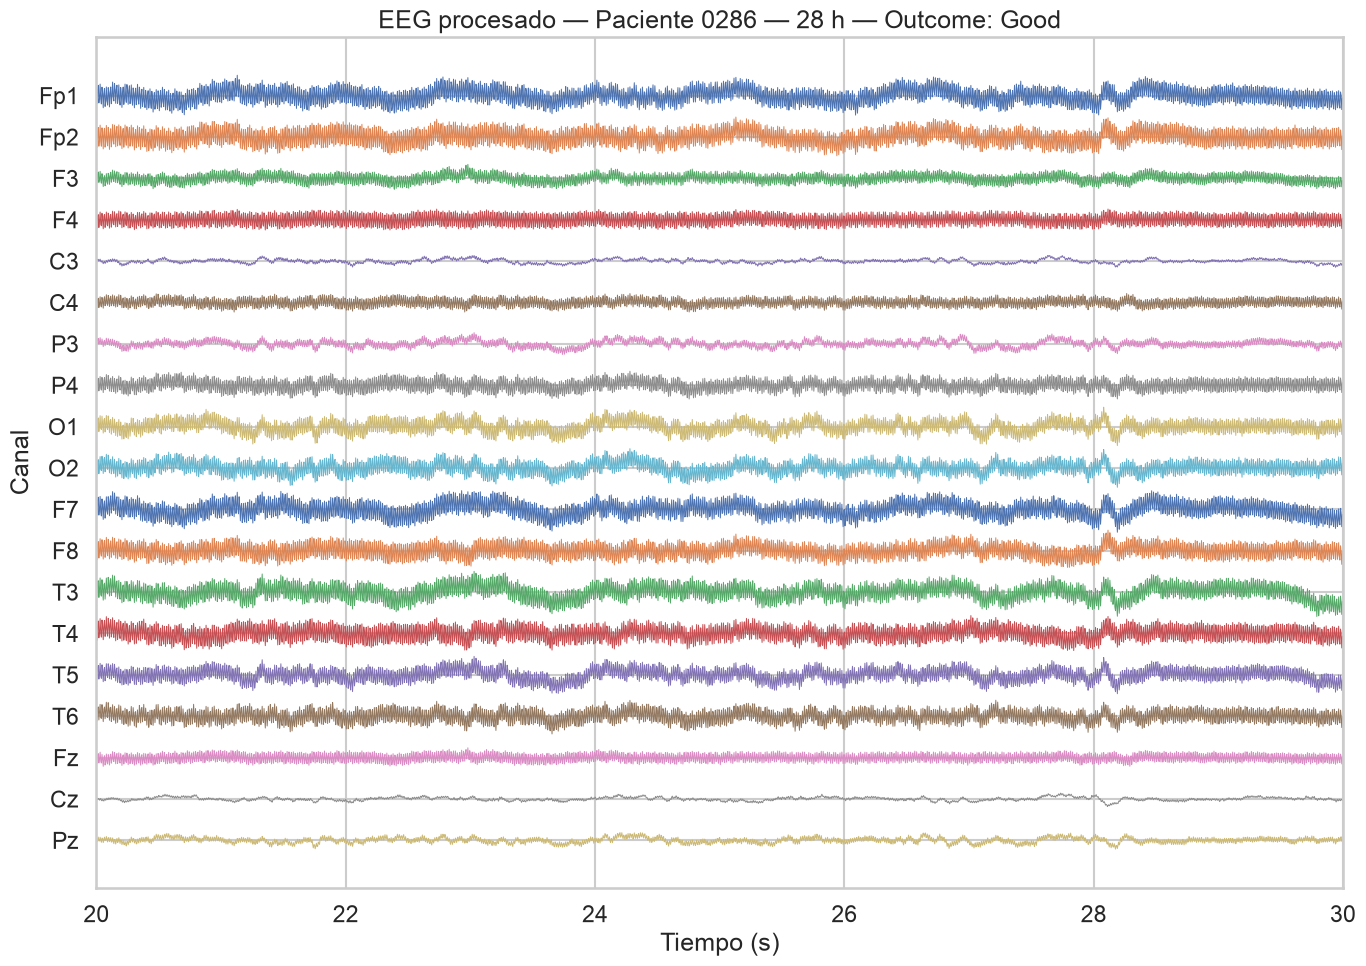

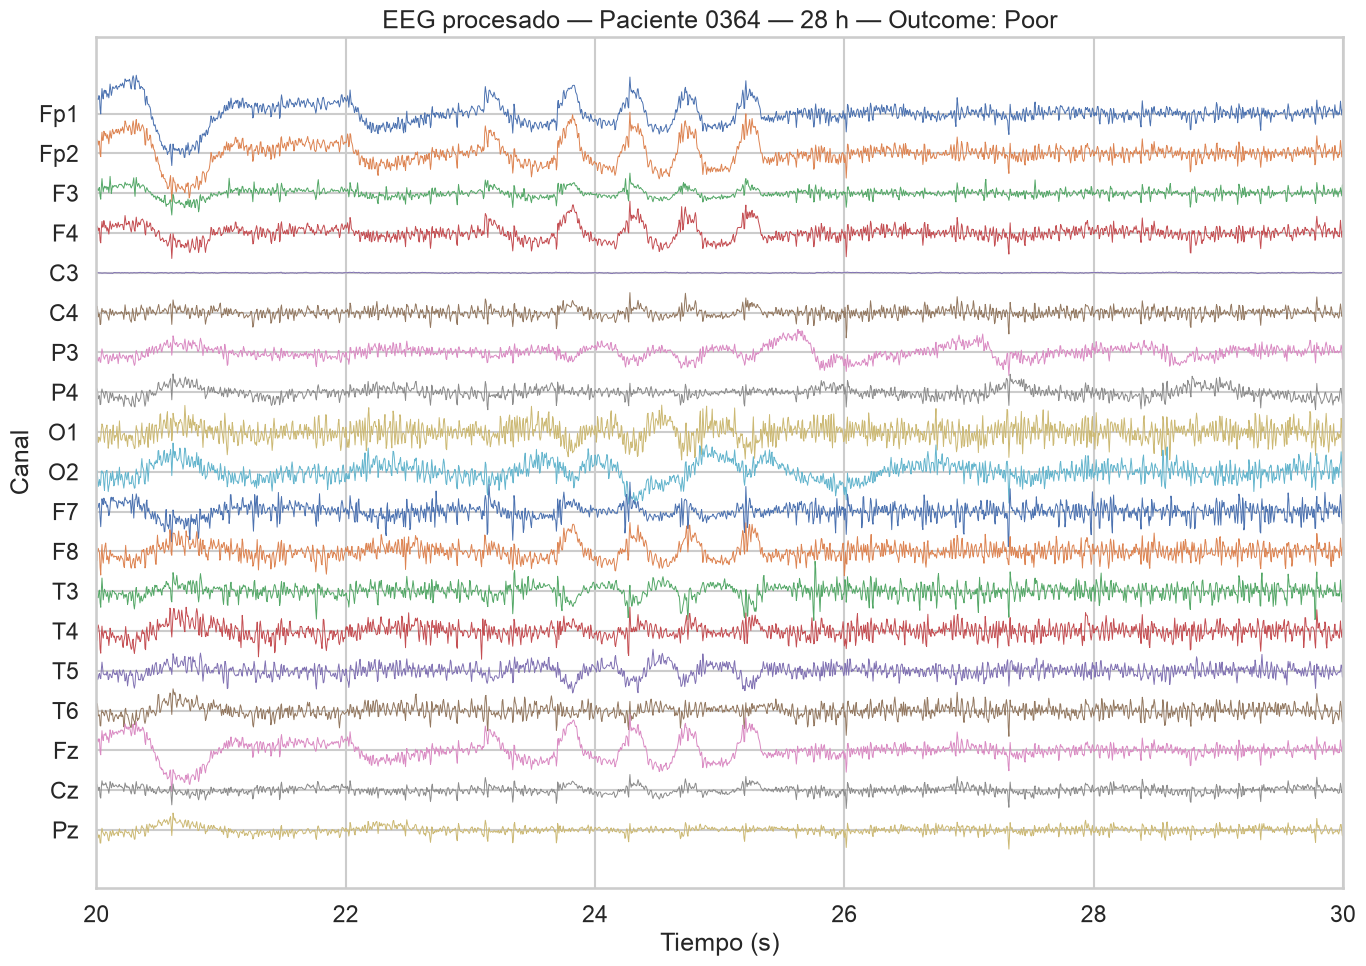

In [186]:
# ============================================================
# 46.2 VISUALIZACIÓN DE LOS EJEMPLOS
# ============================================================

for _, example_row in example_records.iterrows():

    plot_eeg_segment(
        example_row,
        start_second=20,
        duration_seconds=10
    )

Registro con mayor Peak-to-peak: 0303_004_024_EEG


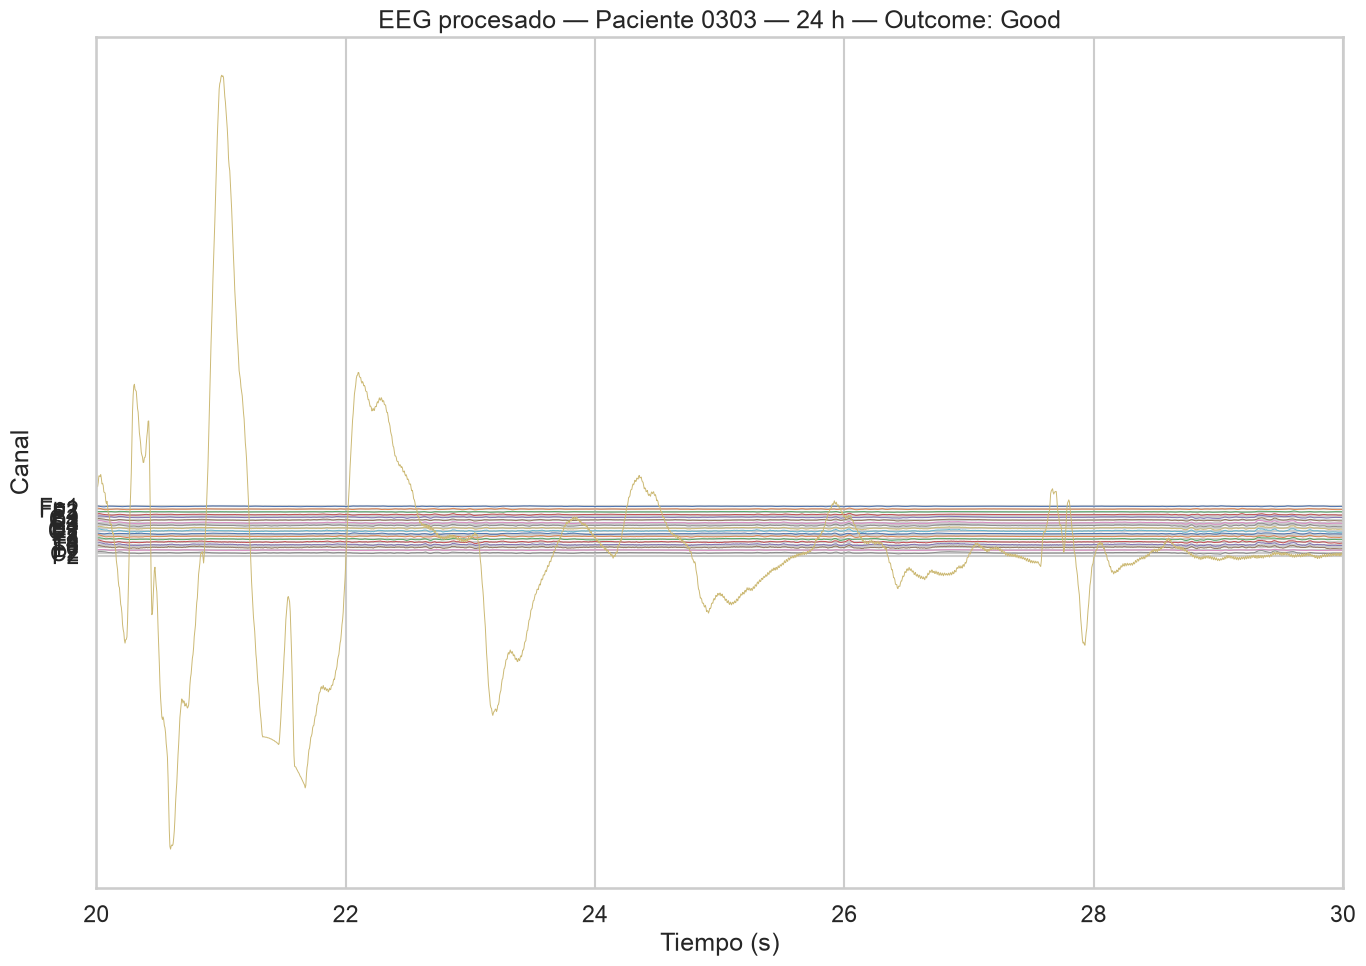

In [187]:
# ============================================================
# 46.3 INSPECCIÓN DEL REGISTRO MÁS EXTREMO
# ============================================================

if len(extreme_peak_to_peak) > 0:

    extreme_record_name = (
        extreme_peak_to_peak.iloc[0]["Record"]
    )

    extreme_row = (
        eeg_master_df.loc[
            eeg_master_df["Record"]
            == extreme_record_name
        ]
        .iloc[0]
    )

    print(
        "Registro con mayor Peak-to-peak:",
        extreme_record_name
    )

    plot_eeg_segment(
        extreme_row,
        start_second=20,
        duration_seconds=10
    )

#### Interpretación de la inspección visual

La inspección visual permitió complementar los resultados obtenidos mediante las características descriptivas. En registros sin valores extremos dominantes, los 19 canales pueden distinguirse claramente y presentan variaciones temporales de diferente magnitud.

Los ejemplos correspondientes a los desenlaces Good y Poor se incluyen únicamente para ilustrar la estructura de las señales procesadas. Debido al reducido número de pacientes de la submuestra piloto y a la existencia de múltiples registros por paciente, las diferencias visuales entre estos ejemplos no deben interpretarse como patrones característicos de los grupos de desenlace.

La inspección del registro con mayor amplitud pico a pico confirmó la presencia de un comportamiento extremo localizado principalmente en el canal Pz del paciente 0303. La magnitud de este canal es considerablemente superior a la de los demás canales y domina la escala de visualización. Este resultado es consistente con la detección cuantitativa previa, que identificó valores extremos del mismo canal en diferentes ventanas temporales del paciente.

Estos resultados muestran la importancia de combinar medidas estadísticas de calidad con inspección visual antes de realizar análisis posteriores. Los valores extremos no fueron eliminados automáticamente, dado que con la información disponible no es posible determinar si corresponden a actividad fisiológica, artefactos o características particulares de adquisición.

## 6. Conclusiones de la exploración EEG

La exploración de los registros EEG permitió caracterizar tanto su disponibilidad temporal como su estructura básica dentro de I-CARE v2.1. A partir de la selección realizada durante la preparación de los datos se identificaron 2,421 observaciones paciente-hora correspondientes a 530 pacientes con registros elegibles entre las 24 y 32 horas. La disponibilidad fue elevada y relativamente estable entre las cinco ventanas temporales analizadas.

Para la exploración directa de las señales se utilizó una submuestra piloto de 50 registros correspondientes a 11 pacientes. Los archivos fueron validados antes del procesamiento y los 50 registros disponibles fueron transformados satisfactoriamente a una representación homogénea de 19 canales, 90 segundos y 200 Hz, equivalente a matrices de \(19 \times 18\,000\) muestras.

La caracterización de 950 combinaciones registro-canal mostró una distribución marcadamente asimétrica de las medidas de variabilidad y amplitud. La amplitud pico a pico presentó una mediana de 62.28, un percentil 95 de 695.10 y un máximo de 26,554.55. Mediante el criterio IQR se identificaron 86 observaciones registro-canal (9.05 %) con valores extremos de amplitud pico a pico y 60 (6.32 %) para la desviación estándar y el RMS.

La inspección de los casos extremos mostró que algunos valores elevados se concentran en canales particulares de un paciente a través de diferentes ventanas temporales, mientras que otros afectan simultáneamente múltiples canales de un registro. La inspección visual confirmó que estas observaciones pueden alterar considerablemente la escala de las señales, por lo que requieren procedimientos específicos de control de calidad antes de análisis posteriores.

En conjunto, los resultados muestran que el conjunto I-CARE proporciona una cobertura EEG longitudinal amplia para la cohorte estudiada, pero también presenta una heterogeneidad importante en las características de las señales. Debido al carácter piloto de la exploración directa y al reducido número de pacientes analizados, estos resultados se consideran descriptivos y no se utilizan para realizar inferencia poblacional ni para establecer diferencias entre los grupos de desenlace neurológico.

## 6. Visualizaciones complementarias

Finalmente, se construyeron visualizaciones adicionales para resumir la composición de la cohorte, la disponibilidad temporal de los registros EEG y la heterogeneidad observada entre hospitales y desenlaces.

Debido a que los centros hospitalarios se encuentran anonimizados mediante identificadores categóricos (A, B, D, E y F), no es posible construir una representación geográfica de su ubicación sin incorporar información externa no disponible en el conjunto de datos. Por esta razón, la comparación entre centros se realiza mediante visualizaciones categóricas.

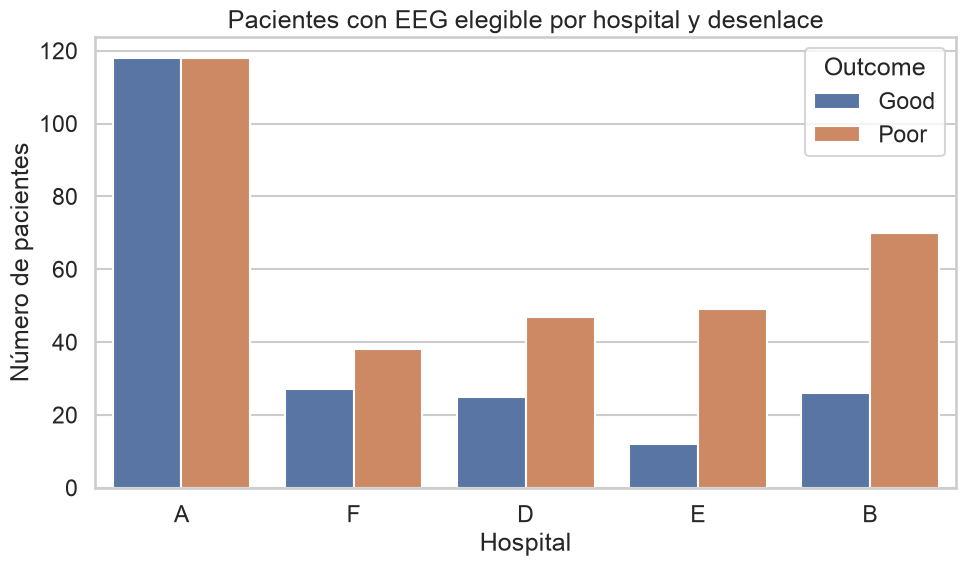

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=sampling_frame_df.loc[
        sampling_frame_df["EEG_eligible"]
    ],
    x="Hospital",
    hue="Outcome"
)

plt.title(
    "Pacientes con EEG elegible por hospital y desenlace"
)

plt.xlabel("Hospital")
plt.ylabel("Número de pacientes")

plt.legend(
    title="Outcome"
)

plt.tight_layout()
plt.show()

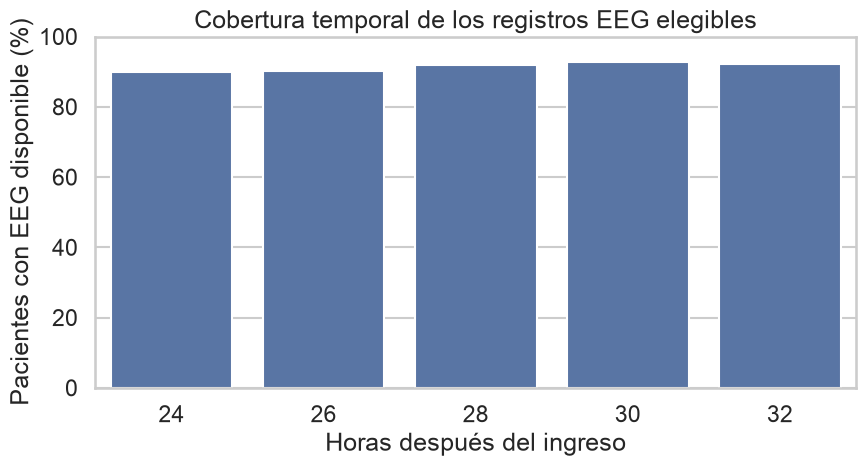

In [189]:
hour_coverage = (
    selected_eeg_records
    .groupby("Hour")["Patient"]
    .nunique()
    .reset_index(name="Patients")
)

hour_coverage["Coverage_percentage"] = (
    100
    * hour_coverage["Patients"]
    / selected_eeg_records["Patient"].nunique()
)


plt.figure(figsize=(9, 5))

sns.barplot(
    data=hour_coverage,
    x="Hour",
    y="Coverage_percentage"
)

plt.ylim(0, 100)

plt.xlabel(
    "Horas después del ingreso"
)

plt.ylabel(
    "Pacientes con EEG disponible (%)"
)

plt.title(
    "Cobertura temporal de los registros EEG elegibles"
)

plt.tight_layout()
plt.show()

In [190]:
eeg_record_summary = (
    eeg_features_df
    .groupby(
        [
            "Patient",
            "Record",
            "Hour",
            "Hospital",
            "Outcome",
            "CPC"
        ],
        as_index=False
    )
    .agg(
        Median_Std=("Std", "median"),
        Median_RMS=("RMS", "median"),
        Median_Peak_to_peak=(
            "Peak_to_peak",
            "median"
        ),
        Max_Peak_to_peak=(
            "Peak_to_peak",
            "max"
        )
    )
)

display(
    eeg_record_summary.head()
)

,Patient,Record,Hour,Hospital,Outcome,CPC,Median_Std,Median_RMS,Median_Peak_to_peak,Max_Peak_to_peak
0,0286,0286_005_024_EEG,24,F,Good,1,12.578894,12.579050,92.775108,135.740906
1,0286,0286_008_026_EEG,26,F,Good,1,12.528358,12.528425,76.063629,107.601913
2,0286,0286_010_028_EEG,28,F,Good,1,12.816525,12.816543,73.322601,97.249199
3,0286,0286_012_030_EEG,30,F,Good,1,12.478812,12.478924,74.172943,103.020096
4,0286,0286_015_032_EEG,32,F,Good,1,11.727572,11.727596,68.828522,97.067917


In [192]:
import plotly.express as px

fig = px.scatter(
    eeg_record_summary,
    x="Hour",
    y="Median_Peak_to_peak",
    color="Outcome",
    symbol="Hospital",
    hover_data=[
        "Patient",
        "Record",
        "Hospital",
        "CPC"
    ],
    title=(
        "Variabilidad de la amplitud EEG por ventana temporal "
        "(submuestra piloto)"
    ),
    labels={
        "Hour": "Hora",
        "Median_Peak_to_peak":
            "Mediana Peak-to-peak del registro"
    }
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

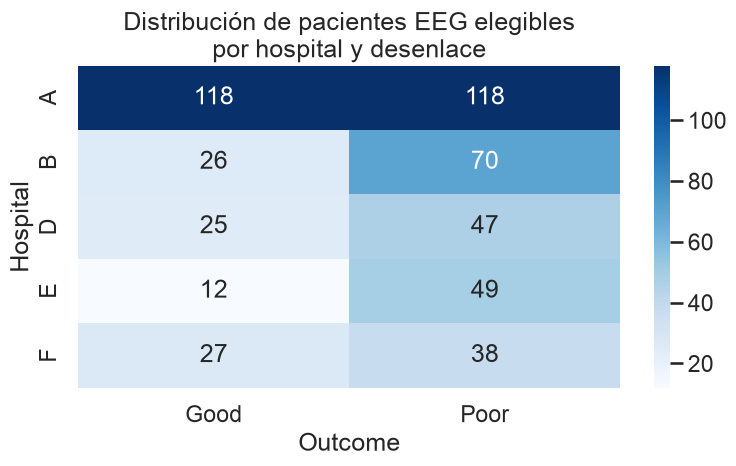

In [193]:
hospital_outcome = pd.crosstab(
    sampling_frame_df.loc[
        sampling_frame_df["EEG_eligible"],
        "Hospital"
    ],
    sampling_frame_df.loc[
        sampling_frame_df["EEG_eligible"],
        "Outcome"
    ]
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    hospital_outcome,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Distribución de pacientes EEG elegibles\n"
    "por hospital y desenlace"
)

plt.xlabel("Outcome")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

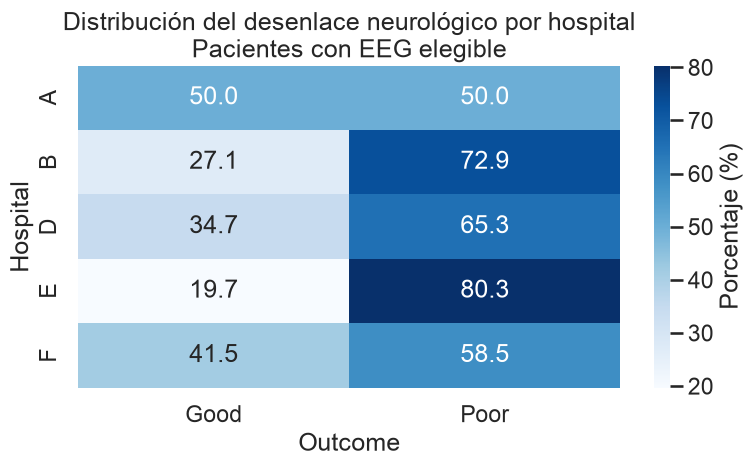

In [194]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

eligible_df = sampling_frame_df.loc[
    sampling_frame_df["EEG_eligible"]
].copy()

hospital_outcome_pct = pd.crosstab(
    eligible_df["Hospital"],
    eligible_df["Outcome"],
    normalize="index"
) * 100

plt.figure(figsize=(8, 5))

sns.heatmap(
    hospital_outcome_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Porcentaje (%)"}
)

plt.title(
    "Distribución del desenlace neurológico por hospital\n"
    "Pacientes con EEG elegible"
)

plt.xlabel("Outcome")
plt.ylabel("Hospital")

plt.tight_layout()
plt.show()

## **Créditos**
* **Profesor:** [Felipe Restrepo Calle](https://dis.unal.edu.co/~ferestrepoca/)
* **Asistentes docentes:**
    - [Juan Sebastián Lara Ramírez](https://www.linkedin.com/in/juan-sebastian-lara-ramirez-43570a214/).
* **Diseño de imágenes:**
    - [Rosa Alejandra Superlano Esquibel](mailto:rsuperlano@unal.edu.co).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).
    
**Universidad Nacional de Colombia** - *Facultad de Ingeniería*